# Lending Club 데이터 EDA — 전체 변수 설명 및 시각화

샤프 비율(Sharpe ratio) 기반 신용평가 모델링을 위한 사전 탐색 단계입니다.
이 노트북은 위에서부터 아래로 순서대로 실행하면 그대로 돌아갑니다.

**구성**

1. 라이브러리 및 데이터 불러오기
2. 데이터 기본 정보 확인
3. 결측치 현황 한눈에 보기
4. 141개 변수 개별 설명 및 시각화
5. 변수 분류 요약 (모델 투입 가능 / 제외 대상)

**각 변수마다 표기한 내용**

- 원문 정의 (Lending Club 데이터 사전)
- 한국어 해설
- 결측률 및 시각화 시 절단 구간
- 모델 투입 가능 여부 (✅ 사용 가능 / 🚫 사후정보·식별자·상수 / ⚠️ 내생변수)

## 1. 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 모든 컬럼이 잘리지 않고 출력되도록 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# 그래프 기본 스타일
sns.set_theme(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False

print('pandas :', pd.__version__)

pandas : 2.3.3


In [2]:
# 데이터 경로 (본인 환경에 맞게 수정)
DATA_PATH = "~/Documents/statistic_science/stat_Assignment/lending_club_2020_train.csv"

lending_club = pd.read_csv(DATA_PATH, low_memory=False)

print('행 개수   :', f'{len(lending_club):,}')
print('변수 개수 :', lending_club.shape[1])

행 개수   : 1,755,295
변수 개수 : 141


## 2. 데이터 기본 정보 확인

In [3]:
lending_club.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,124989905,6000.0,6000.0,6000.0,36 months,7.97%,187.94,A,A5,Teacher,2 years,MORTGAGE,45000.0,Verified,Dec-2017,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,554xx,MN,8.67,1.0,Sep-2005,755.0,759.0,0.0,22.0,NaN,14.0,0.0,3090.0,14%,36.0,w,0.00,0.00,6718.84,6718.84,6000.00,718.84,0.0,0.0,0.0,Apr-2020,1835.06,NaN,Apr-2020,764.0,760.0,0.0,NaN,1.0,Joint App,100500.0,10.20,Verified,0.0,0.0,50054.0,1.0,10.0,3.0,3.0,3.0,46964.0,83.0,1.0,1.0,3090.0,64.0,22100.0,1.0,0.0,2.0,4.0,3850.0,11910.0,20.6,0.0,0.0,147.0,135.0,12.0,3.0,1.0,56.0,NaN,3.0,NaN,0.0,1.0,1.0,1.0,4.0,28.0,4.0,7.0,1.0,14.0,0.0,0.0,0.0,4.0,97.1,0.0,0.0,0.0,78611.0,50054.0,15000.0,56511.0,3926.0,555.0,559.0,Sep-2005,0.0,0.0,10.0,NaN,10.0,4.0,1.0,0.0,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,139665484,35000.0,35000.0,35000.0,60 months,14.47%,822.95,C,C2,Product Specialist,2 years,RENT,94000.0,Source Verified,Sep-2018,Current,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Credit card refinancing,085xx,NJ,17.41,0.0,Dec-2002,715.0,719.0,2.0,NaN,NaN,6.0,0.0,24640.0,35.4%,8.0,w,25993.32,25993.32,16430.86,16430.86,9006.68,7424.18,0.0,0.0,0.0,May-2020,822.95,Jun-2020,May-2020,754.0,750.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,58284.0,1.0,1.0,1.0,1.0,5.0,33644.0,96.0,0.0,0.0,8542.0,56.0,69600.0,1.0,0.0,2.0,1.0,9714.0,44960.0,35.4,0.0,0.0,30.0,154.0,46.0,5.0,0.0,46.0,NaN,5.0,NaN,0.0,4.0,4.0,4.0,5.0,2.0,4.0,5.0,4.0,6.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,104863.0,58284.0,69600.0,35000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,84253847,23200.0,23200.0,23200.0,60 months,24.99%,680.82,E,E4,Production Foreman,10+ years,MORTGAGE,110000.0

In [4]:
lending_club.shape

(1755295, 141)

In [5]:
lending_club.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755295 entries, 0 to 1755294
Data columns (total 141 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          1755295 non-null  object 
 1    loan_amnt                                   1755294 non-null  float64
 2    funded_amnt                                 1755294 non-null  float64
 3    funded_amnt_inv                             1755294 non-null  float64
 4    term                                        1755294 non-null  object 
 5    int_rate                                    1755294 non-null  object 
 6    installment                                 1755294 non-null  float64
 7    grade                                       1755294 non-null  object 
 8    sub_grade                                   1755294 non-null  object 
 9    emp_title                                   

In [6]:
lending_club.dtypes.value_counts()

float64    106
object      35
Name: count, dtype: int64

In [7]:
lending_club.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755292e+06,1.753433e+06,1.755278e+06,1.755294e+06,1.755294e+06,1.755278e+06,833096.000000,256588.000000,1.755278e+06,1.755278e+06,1.755294e+06,1.755278e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755294e+06,1.755200e+06,433417.000000,1755294.0,1.263570e+05,126355.000000,1.755278e+06,1.713207e+06,1.713207e+06,1.235574e+06,1.235574e+06,1.235574e+06,1.235574e+06,1.199294e+06,1.235574e+06,1.060815e+06,1.235574e+06,1.235574e+06,1.235574e+06,1.235349e+06,1.713207e+06,1.235574e+06,1.235574e+06,1.235574e+06,1.725310e+06,1.713132e+06,1.705758e+06,1.704905e+06,1.755200e+06,1.755278e+06,1.662049e+06,1.713206e+06,1.713206e+06,1.713207e+06,1.725310e+06,1.706924e+06,389706.000000,1.532528e+06,558054.000000,1.713207e+06,1.713207e+06,1.713207e+06,1.720182e+06,1.713207e+06,1.713207e+06,1.713207e+06,1.713206e+06,1.713207e+06,1.720182e+06,1.658544e+06,1.713207e+06,1.713207e+06,1.713207e+06,1.713106e+06,1.705464e+06,1.754443e+06,1.755222e+06,1.713207e+06,1.725310e+06,1.725310e+06,1.713207e+06,1.187050e+05,118705.000000,118705.000000,118705.000000,118705.000000,118705.000000,116742.000000,118705.000000,118705.000000,118705.000000,118705.000000,86036.000000,109131.000000,86036.000000,86035.000000,107480.000000,109131.00000,109131.000000
mean,1.535079e+04,1.534665e+04,1.533186e+04,4.521032e+02,7.994798e+04,1.930943e+01,2.893348e-01,7.005373e+02,7.045375e+02,5.543441e-01,34.947058,74.744719,1.167687e+01,1.762621e-01,1.694752e+04,2.401834e+01,4.039477e+03,4.038897e+03,1.256577e+04,1.255091e+04,9.911000e+03,2.483314e+03,1.763165e+00,1.696917e+02,2.898170e+01,3.474230e+03,6.903992e+02,6.778836e+02,1.758774e-02,44.600078,1.0,1.304439e+05,19.472252,3.291217e-03,2.109149e+02,1.453748e+05,9.310798e-01,2.825212e+00,6.989626e-01,1.604160e+00,2.040323e+01,3.680167e+04,6.895923e+01,1.252402e+00,2.645366e+00,6.010031e+03,5.625519e+01,3.631731e+04,1.073259e+00,1.518555e+00,2.002423e+00,4.491672e+00,1.371489e+04,1.267926e+04,5.590895e+01,8.004786e-03,9.581794e+00,1.258632e+02,1.796254e+02,1.446222e+01,8.346129e+00,1.511964e+00,2.505855e+01,39.306836,7.107732e+00,36.064404,4.874583e-0

## 3. 결측치 현황 한눈에 보기

교수님 힌트에서 강조된 부분입니다. 결측치가 많다고 무작정 버리면 안 되고,
**결측 자체가 정보를 담고 있는지**를 먼저 판단해야 합니다.

- `mths_since_last_delinq` 계열: 결측 = 연체 이력 없음 → 오히려 우량 신호
- `sec_app_*`, `*_joint` 계열: 개인 대출이라 애초에 존재하지 않는 **구조적 결측**
- `hardship_*` 계열: 하드십 플랜 대상이 아니라서 발생한 결측

따라서 평균·최빈값 대치보다 `결측 여부 더미(d_j)`와 `x_j * d_j` 조합이 적절합니다.

In [8]:
miss = (lending_club.isna().mean() * 100).sort_values(ascending=False)
miss_df = miss.to_frame('missing_pct').round(2)
miss_df['dtype'] = lending_club.dtypes.astype(str)
miss_df['n_unique'] = lending_club.nunique()
miss_df.head(40)

,missing_pct,dtype,n_unique
hardship_loan_status,95.11,object,13
hardship_reason,95.10,object,17
hardship_status,95.10,object,4
hardship_dpd,95.10,float64,44
payment_plan_start_date,95.10,object,46
hardship_type,95.10,object,9
deferral_term,95.10,float64,4
hardship_start_date,95.10,object,46
hardship_end_date,95.10,object,47
hardship_length,95.10,float64,4


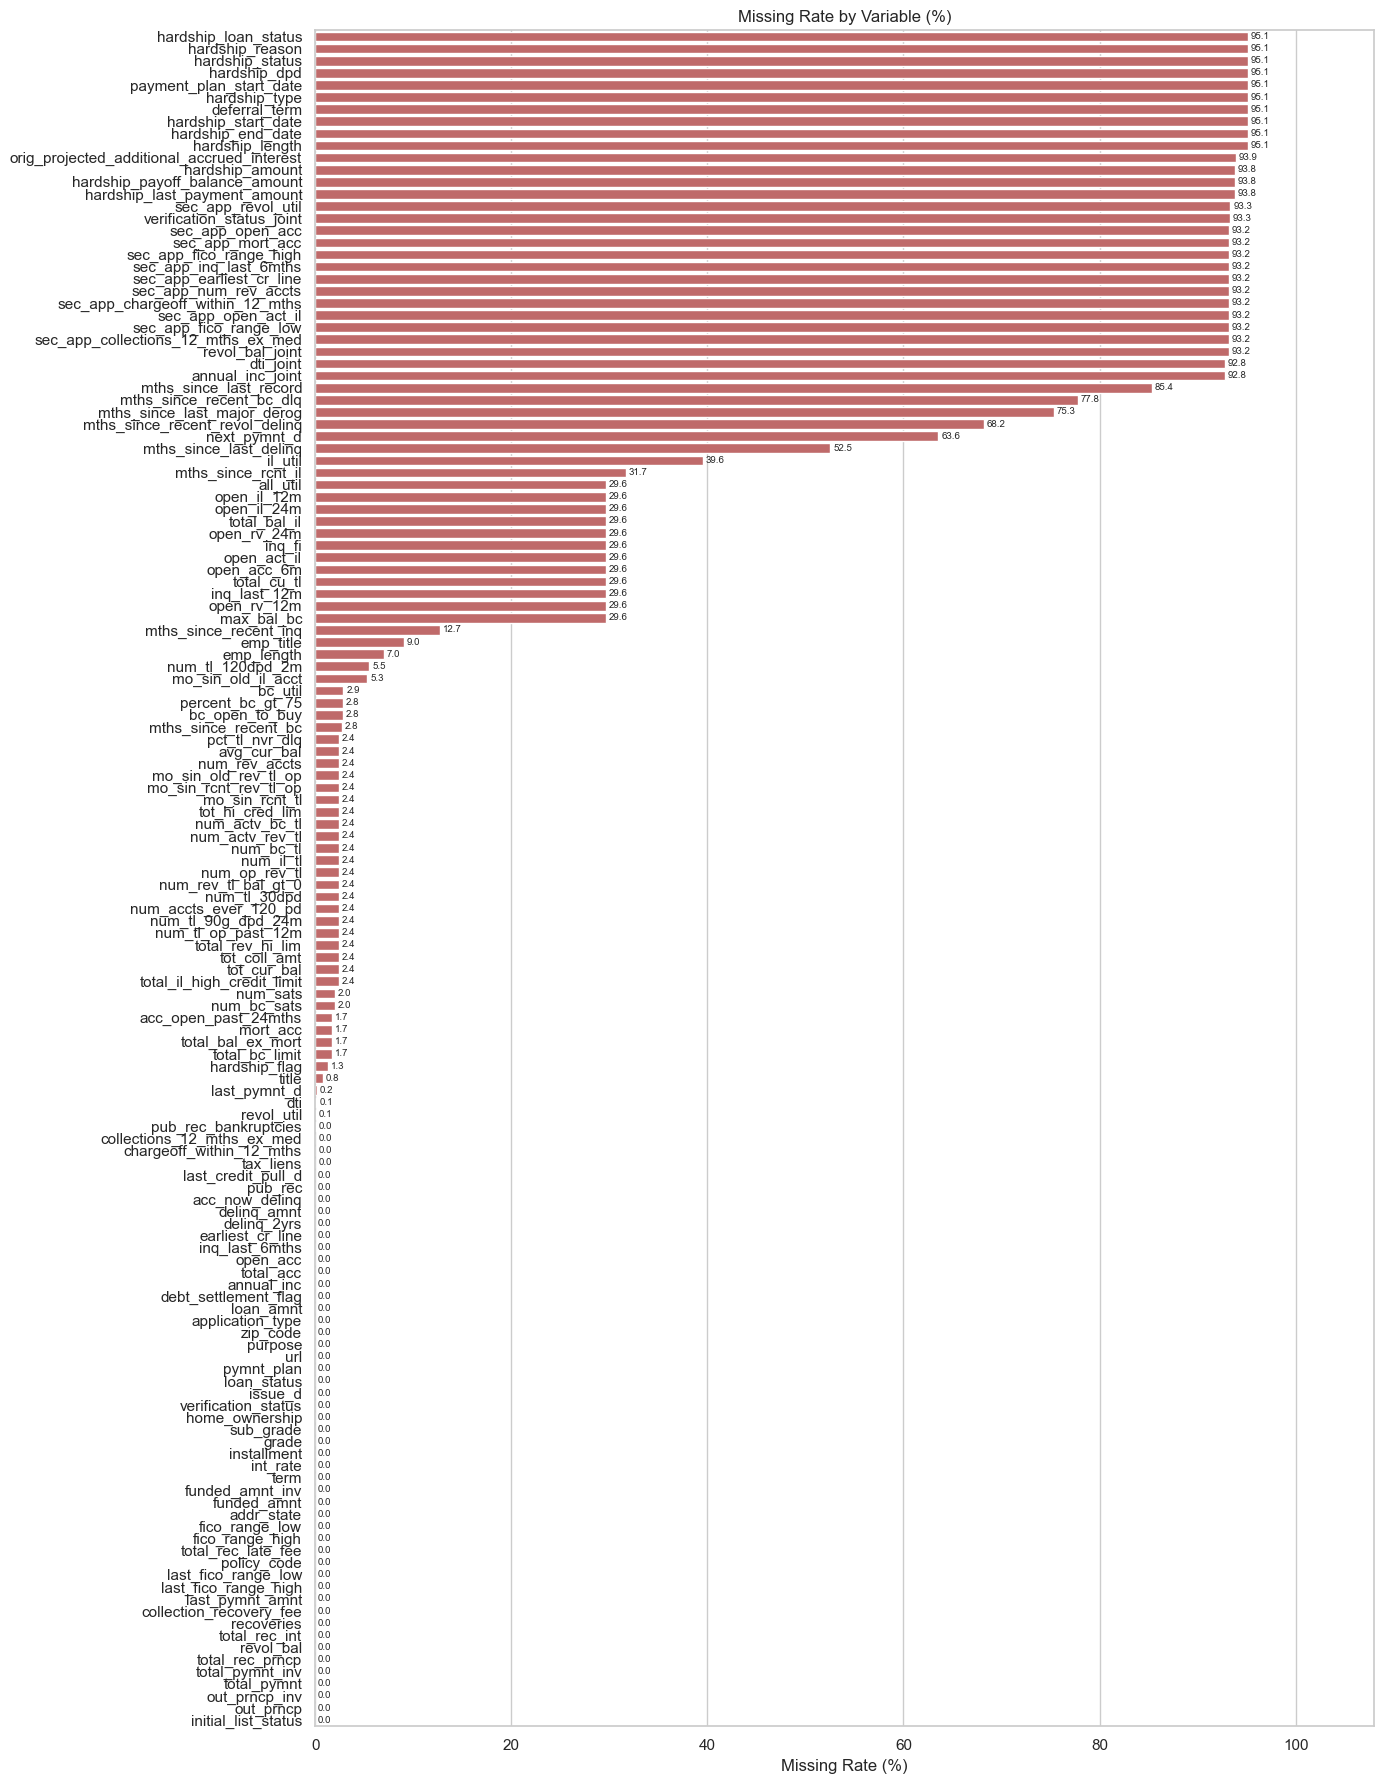

In [9]:
plt.figure(figsize=(14, 18))

target = miss[miss > 0]
ax = sns.barplot(x=target.values, y=target.index, color='indianred')
ax.bar_label(ax.containers[0], fmt='%.1f', fontsize=7, padding=2)

plt.title('Missing Rate by Variable (%)')
plt.xlabel('Missing Rate (%)')
plt.ylabel('')
plt.xlim(0, 108)
plt.tight_layout()
plt.show()

## 4. 각 변수에 대한 설명과 그래프

변수는 대출 신청 → 심사 → 실행 → 사후 관리의 흐름을 따라 배치했습니다.
각 셀은 해당 컬럼이 데이터에 없으면 자동으로 건너뜁니다.

### id

A unique LC assigned ID for the loan listing.
<br>
LC가 부여한 대출 건 고유 식별자. 예측력이 없으므로 제거 대상.

<br>

🚫 **사용 금지 (식별자)** — 고유 값이라 예측력 없음. 제거.

In [10]:
if 'id' in lending_club.columns:
    print('n unique :', lending_club['id'].nunique())
    print('결측 비율 :', round(lending_club['id'].isna().mean() * 100, 2), '%')
    display(lending_club['id'].head(3))
else:
    print("'id' 컬럼이 데이터에 없습니다. 건너뜁니다.")

n unique : 1755295
결측 비율 : 0.0 %


0    124989905
1    139665484
2     84253847
Name: id, dtype: object

### url

URL for the LC page with listing data.
<br>
해당 대출 상세 페이지 URL. 100% 고유 값인 식별자이므로 제거.

<br>

🚫 **사용 금지 (식별자)** — 고유 값이라 예측력 없음. 제거.

In [11]:
if 'url' in lending_club.columns:
    print('n unique :', lending_club['url'].nunique())
    print('결측 비율 :', round(lending_club['url'].isna().mean() * 100, 2), '%')
    display(lending_club['url'].head(3))
else:
    print("'url' 컬럼이 데이터에 없습니다. 건너뜁니다.")

n unique : 1755294
결측 비율 : 0.0 %


0    https://lendingclub.com/browse/loanDetail.acti...
1    https://lendingclub.com/browse/loanDetail.acti...
2    https://lendingclub.com/browse/loanDetail.acti...
Name: url, dtype: object

### loan_amnt

The listed amount of the loan applied for by the borrower.
<br>
차입자가 신청한 대출 원금. IRR 계산의 초기 현금 유출(-CF0)에 해당.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

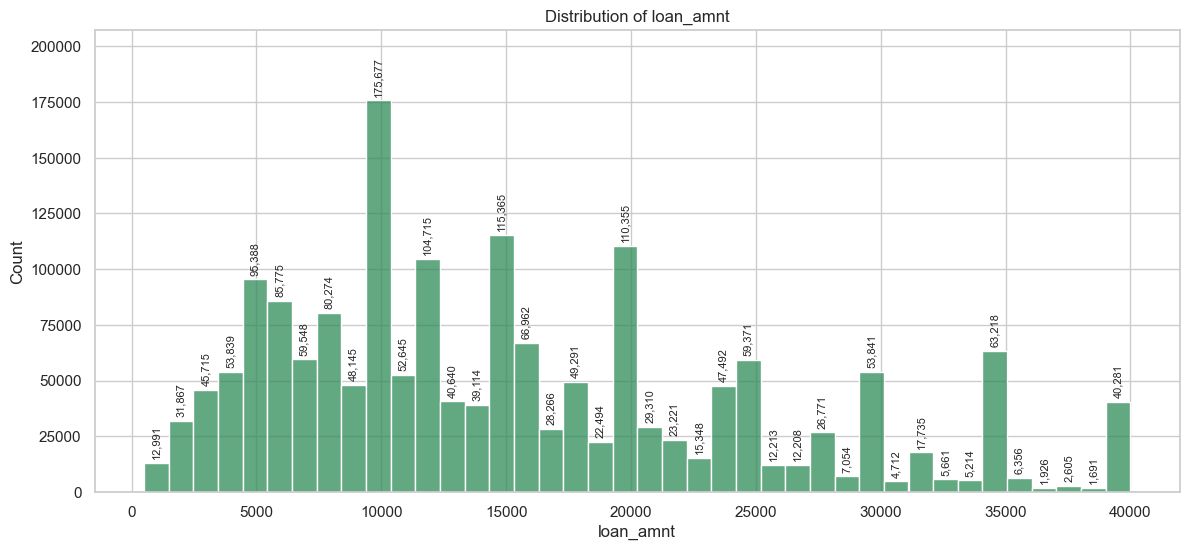

In [12]:
if 'loan_amnt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['loan_amnt'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of loan_amnt')
    plt.xlabel('loan_amnt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'loan_amnt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### funded_amnt

The total amount committed to that loan at that point in time.
<br>
실제로 승인·집행된 금액. LC의 심사 결과이므로 내생변수.

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

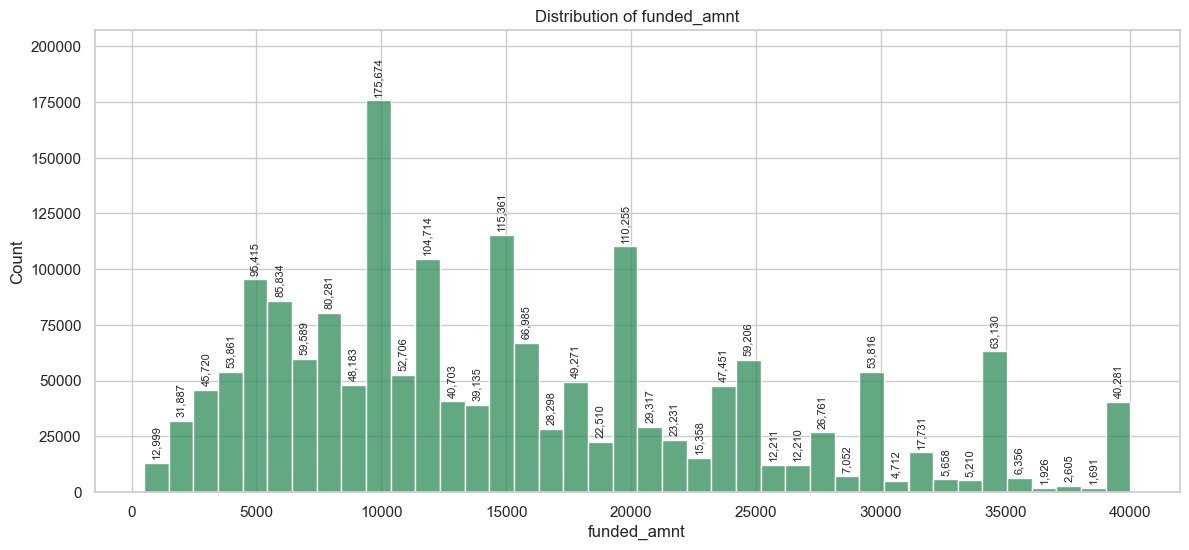

In [13]:
if 'funded_amnt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['funded_amnt'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of funded_amnt')
    plt.xlabel('funded_amnt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'funded_amnt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### funded_amnt_inv

The total amount committed by investors for that loan at that point in time.
<br>
투자자들이 실제로 출자한 금액. funded_amnt와 거의 동일(다중공선성).

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

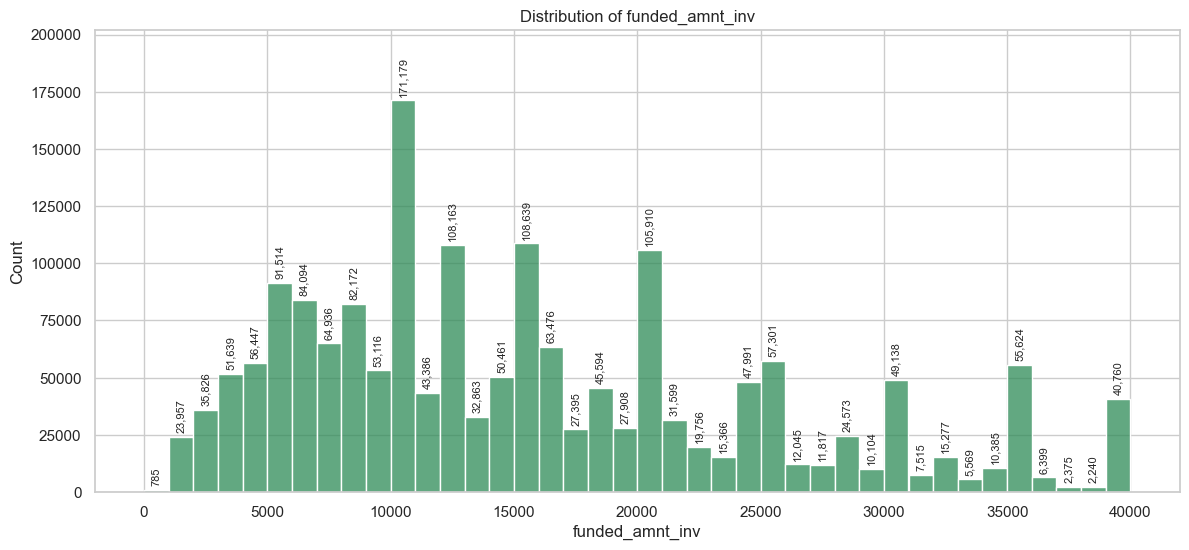

In [14]:
if 'funded_amnt_inv' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['funded_amnt_inv'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of funded_amnt_inv')
    plt.xlabel('funded_amnt_inv')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'funded_amnt_inv' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### term

The number of payments on the loan. Values are in months and can be either 36 or 60.
<br>
대출 만기(36개월 또는 60개월). IRR의 현금흐름 기간을 결정하므로 반드시 필요.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

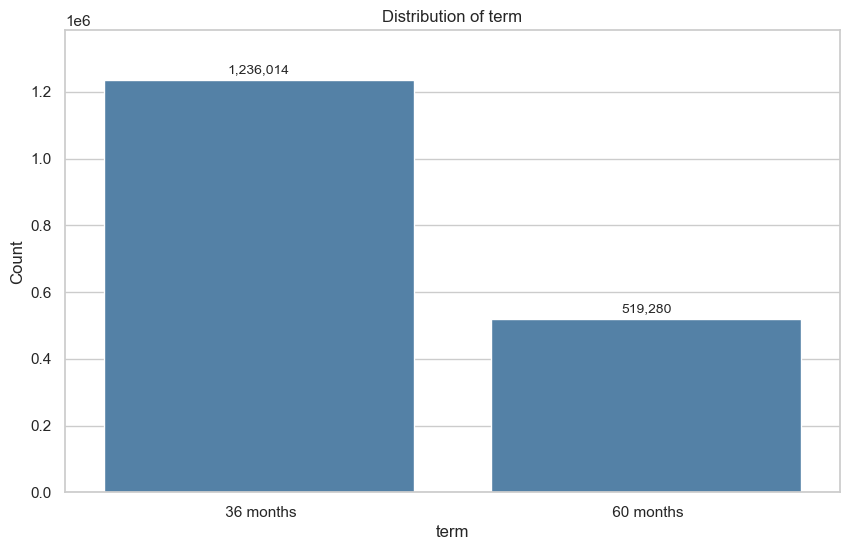

In [15]:
if 'term' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['term']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of term')
    plt.xlabel('term')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'term' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### int_rate

Interest Rate on the loan.
<br>
대출에 적용된 연 이자율(%). 문자열('  8.19%')로 저장되어 있어 숫자 변환이 필요.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 35 이하 구간만 시각화
<br>
⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

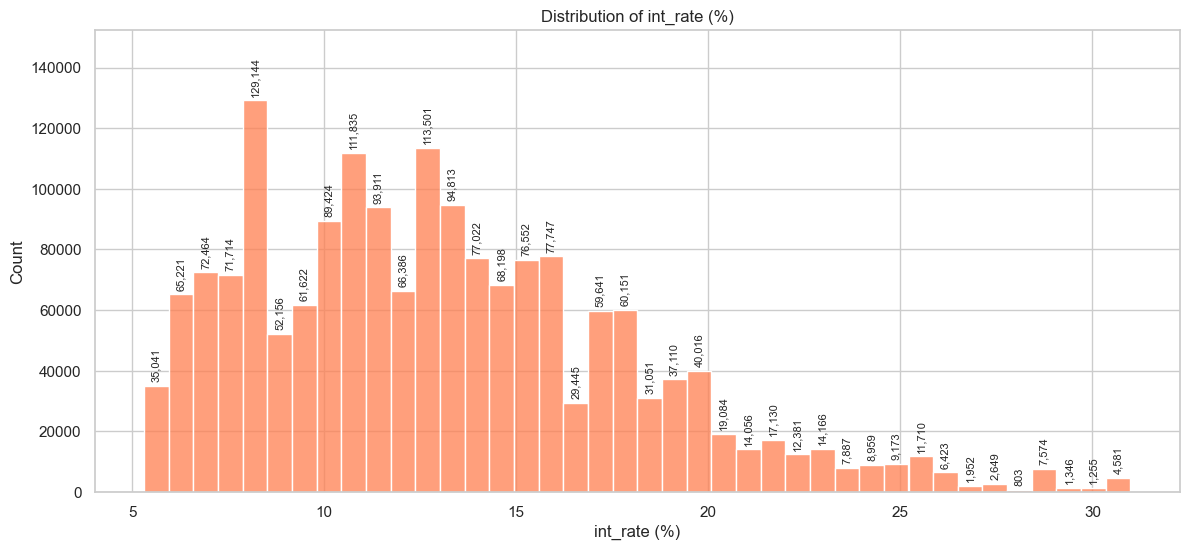

In [16]:
if 'int_rate' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    # '  8.19%' 같은 문자열이므로 % 기호와 공백을 제거하고 숫자로 변환
    s = lending_club['int_rate'].astype(str).str.replace('%', '', regex=False).str.strip()
    data_to_plot = pd.to_numeric(s, errors='coerce').dropna()
    data_to_plot = data_to_plot[data_to_plot <= 35]
    ax = sns.histplot(x=data_to_plot, bins=40, color='coral')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of int_rate (%)')
    plt.xlabel('int_rate (%)')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'int_rate' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### installment

The monthly payment owed by the borrower if the loan originates.
<br>
대출 실행 시 매월 납부해야 하는 원리금(월 상환액).

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

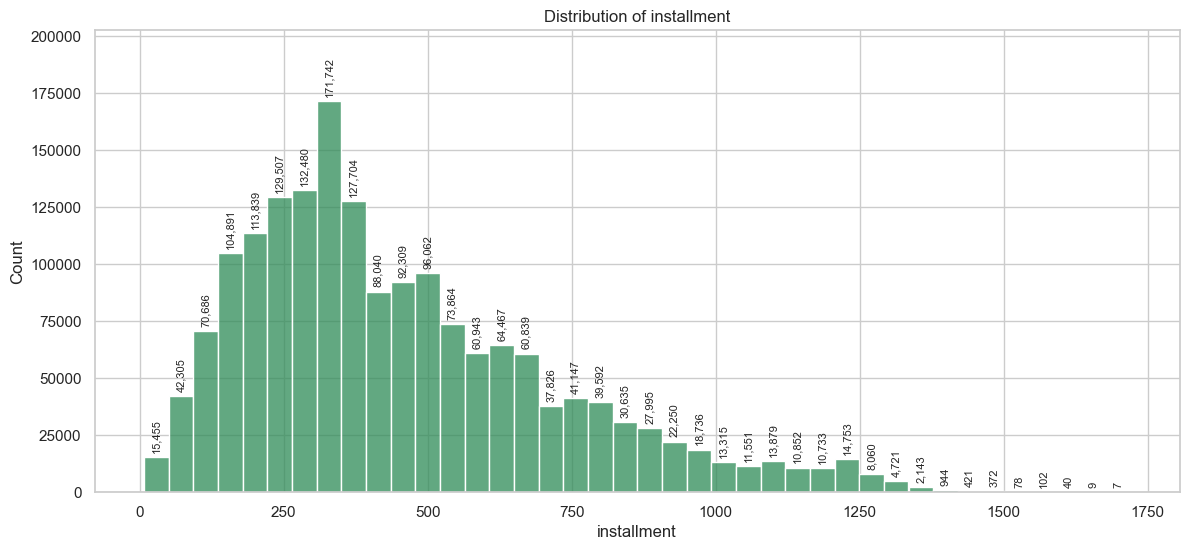

In [17]:
if 'installment' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['installment'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of installment')
    plt.xlabel('installment')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'installment' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### grade

LC assigned loan grade.
<br>
LC가 부여한 신용등급(A~G). 금리 산정의 결과물이므로 내생변수.

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

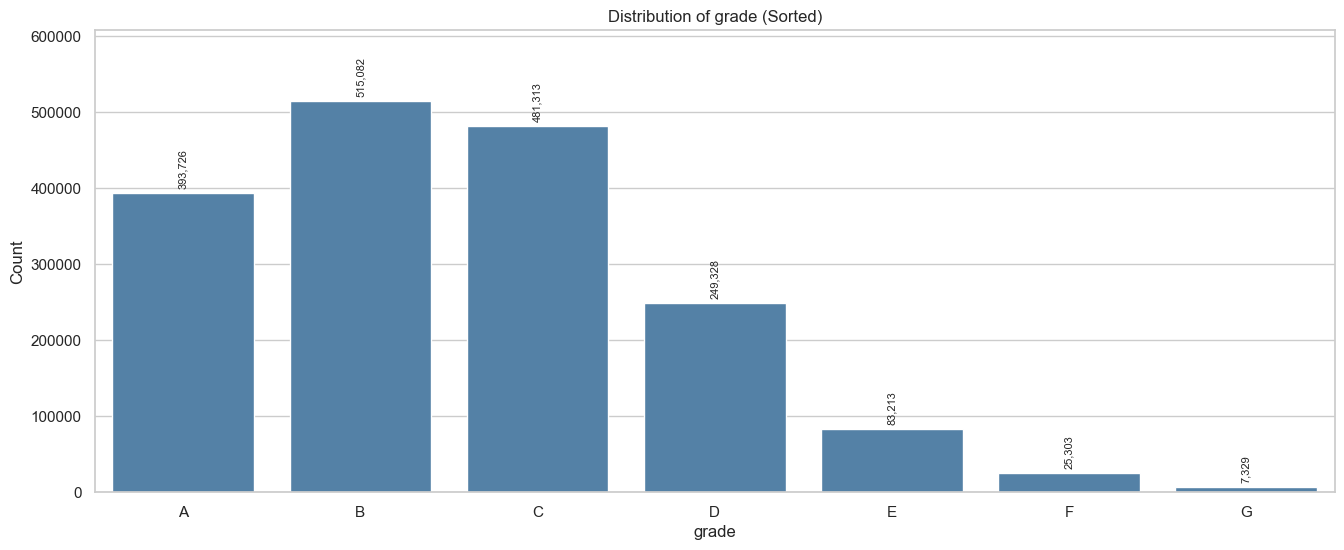

In [18]:
if 'grade' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    order = sorted(lending_club['grade'].dropna().unique())
    ax = sns.countplot(data=lending_club, x='grade', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of grade (Sorted)')
    plt.xlabel('grade')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'grade' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sub_grade

LC assigned loan subgrade.
<br>
LC가 부여한 세부 신용등급(A1~G5). grade와 함께 금리 산정의 결과물.

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

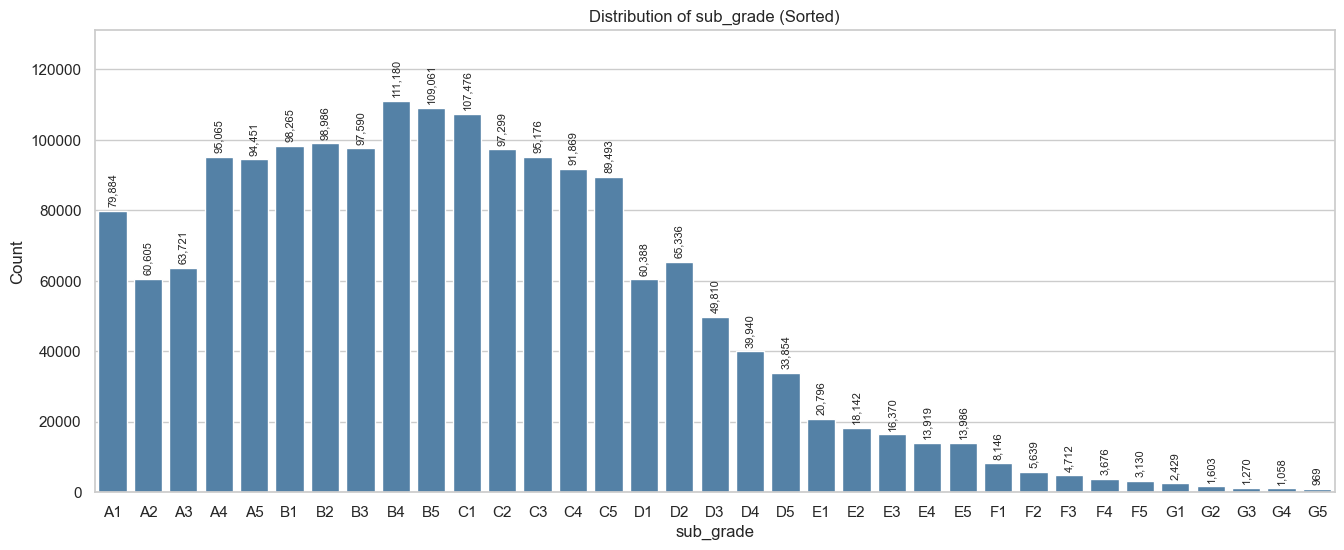

In [19]:
if 'sub_grade' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    order = sorted(lending_club['sub_grade'].dropna().unique())
    ax = sns.countplot(data=lending_club, x='sub_grade', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sub_grade (Sorted)')
    plt.xlabel('sub_grade')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sub_grade' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### emp_title

The job title supplied by the Borrower when applying for the loan.
<br>
차입자가 직접 입력한 직업명. 4만 개가 넘는 자유 텍스트라 정제·그룹화가 필요.

<br>

% 결측치 **8.95%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

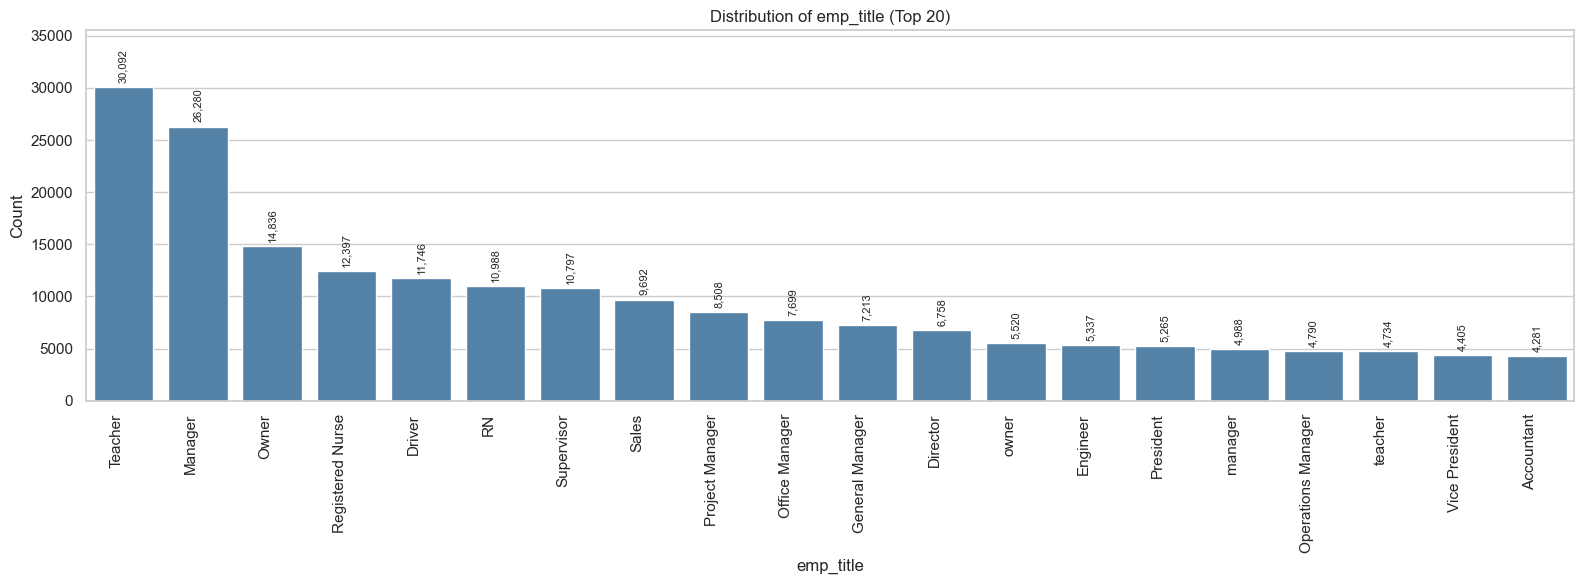

In [20]:
if 'emp_title' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 20개만 표시)
    order = lending_club['emp_title'].value_counts().index[:20]
    ax = sns.countplot(data=lending_club, x='emp_title', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of emp_title (Top 20)')
    plt.xlabel('emp_title')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'emp_title' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### emp_length

Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
<br>
근속 연수(0~10년, 10은 10년 이상). 문자열 범주이므로 숫자로 변환해 쓰는 것이 일반적.

<br>

% 결측치 **6.96%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

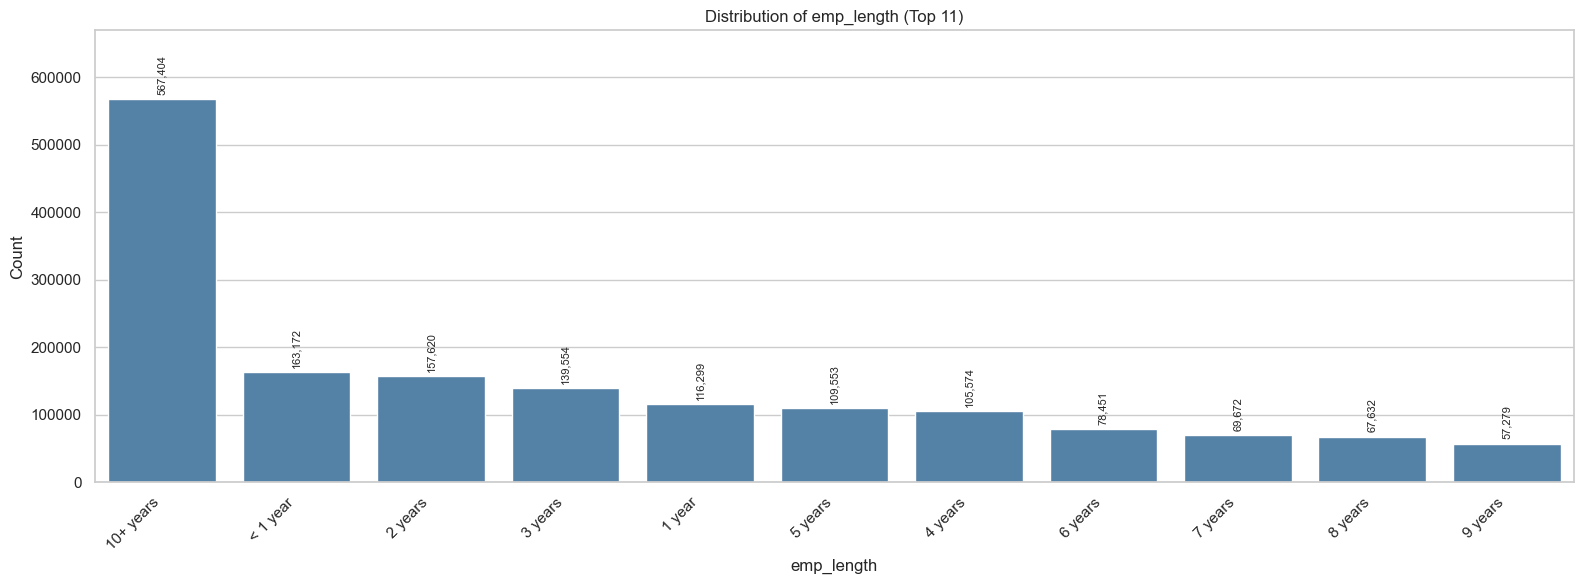

In [21]:
if 'emp_length' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 11개만 표시)
    order = lending_club['emp_length'].value_counts().index[:11]
    ax = sns.countplot(data=lending_club, x='emp_length', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of emp_length (Top 11)')
    plt.xlabel('emp_length')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'emp_length' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### home_ownership

The home ownership status provided by the borrower during registration or obtained from the credit report.
<br>
주거 형태(자가/모기지/임차 등). ANY, NONE 등 소수 범주는 병합 검토.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

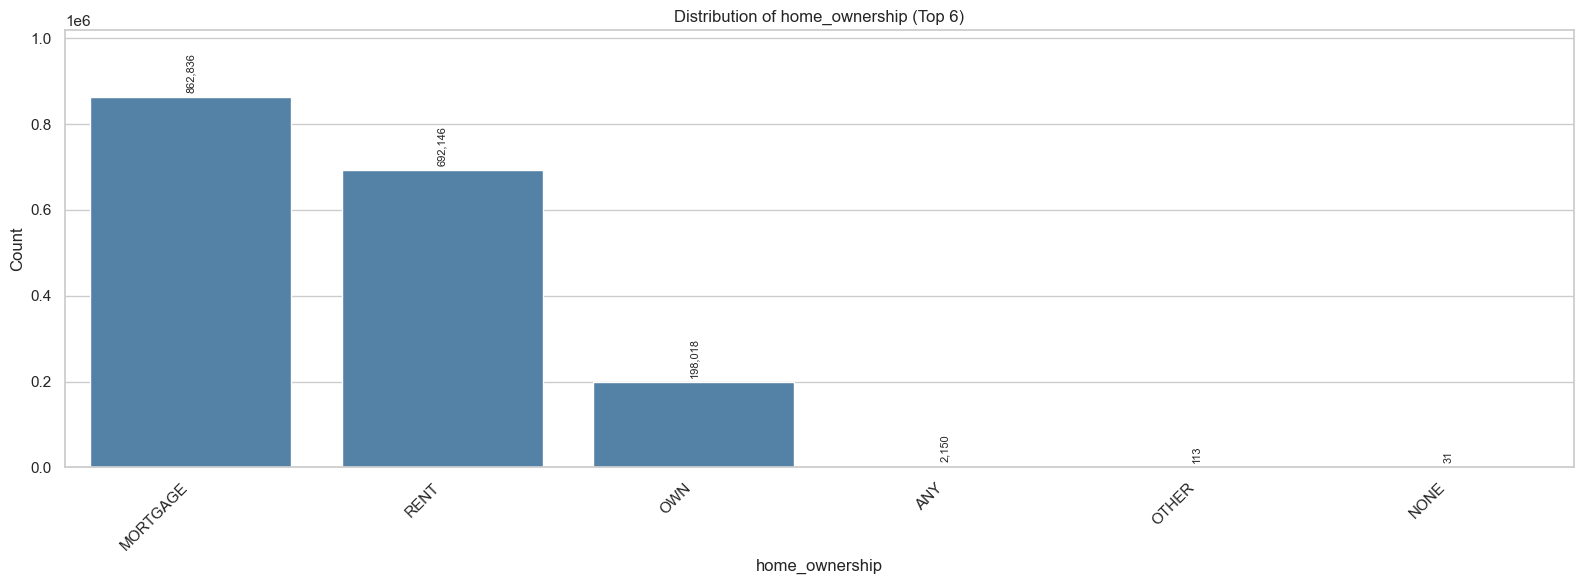

In [22]:
if 'home_ownership' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 6개만 표시)
    order = lending_club['home_ownership'].value_counts().index[:6]
    ax = sns.countplot(data=lending_club, x='home_ownership', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of home_ownership (Top 6)')
    plt.xlabel('home_ownership')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'home_ownership' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### annual_inc

The self-reported annual income provided by the borrower during registration.
<br>
차입자가 신고한 연 소득. 우측 꼬리가 매우 길어 로그 변환 검토 대상.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 300,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

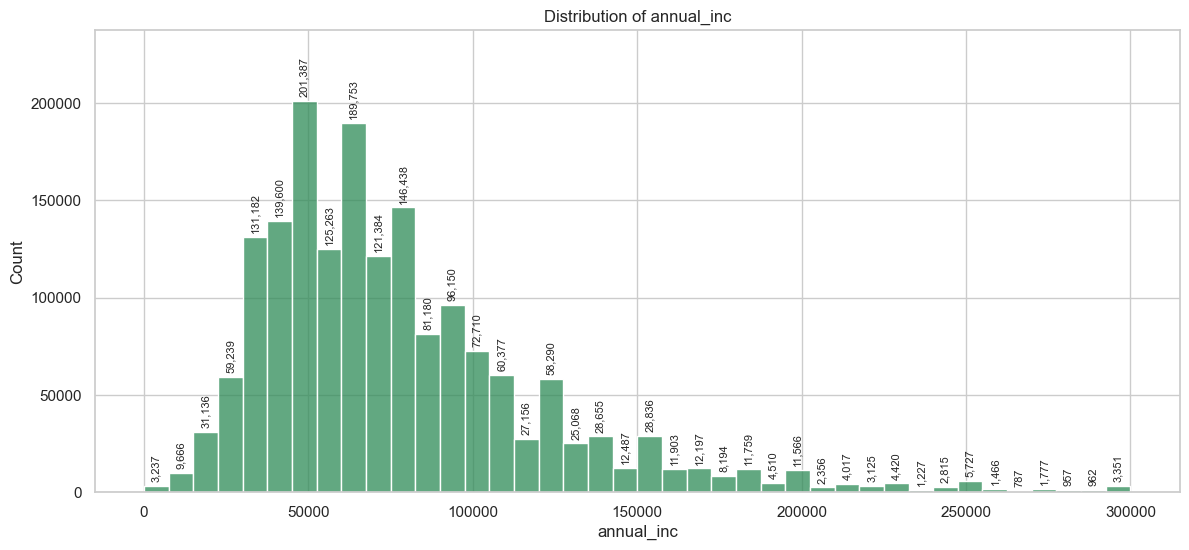

In [23]:
if 'annual_inc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['annual_inc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 300000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of annual_inc')
    plt.xlabel('annual_inc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'annual_inc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### annual_inc_joint

The combined self-reported annual income provided by the co-borrowers during registration.
<br>
공동 신청자의 합산 연 소득. 개인 대출 건은 구조적 결측.

<br>

% 결측치 **92.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 400,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

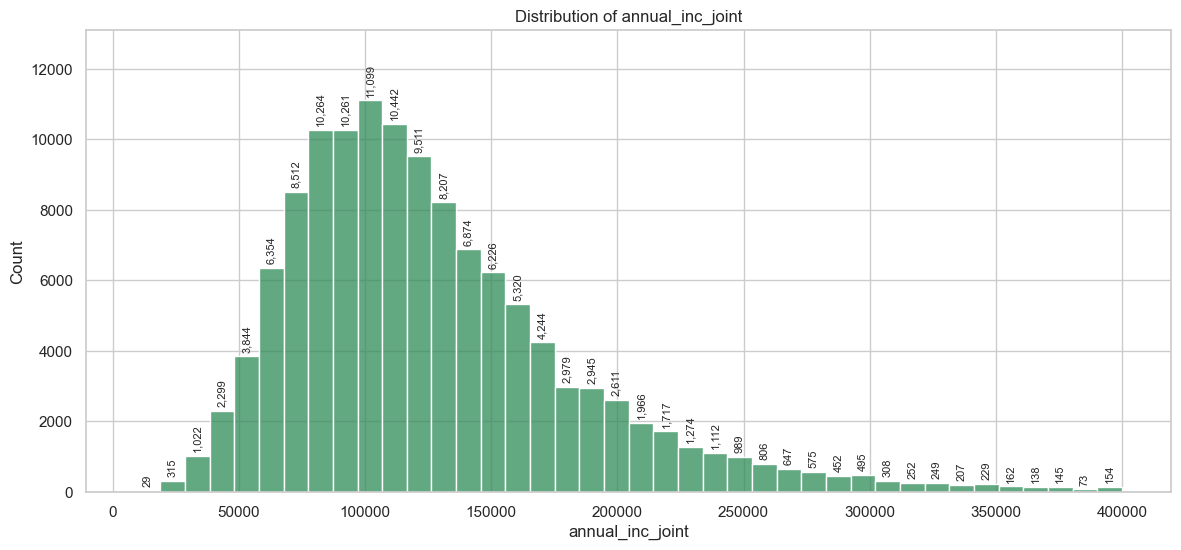

In [24]:
if 'annual_inc_joint' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['annual_inc_joint'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 400000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of annual_inc_joint')
    plt.xlabel('annual_inc_joint')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'annual_inc_joint' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### verification_status

Indicates if income was verified by LC, not verified, or if the income source was verified.
<br>
신고 소득의 검증 여부(미검증/출처검증/검증).

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

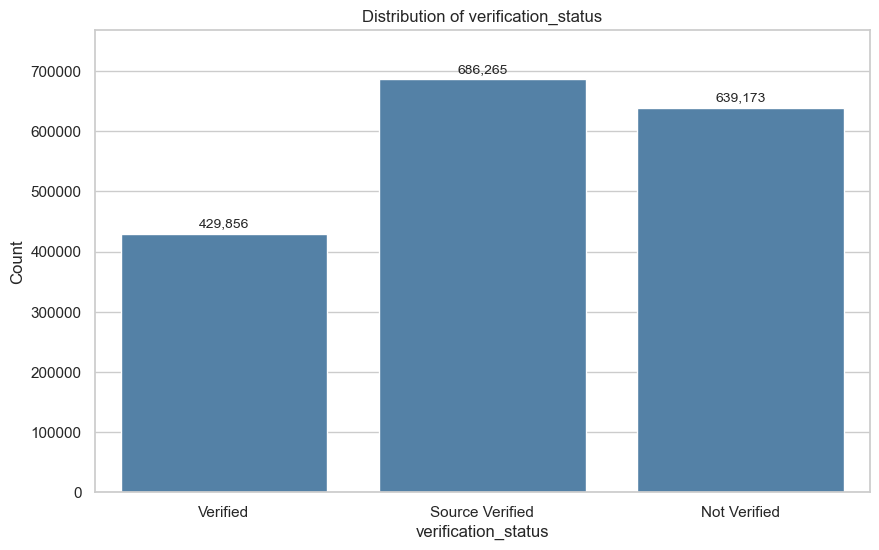

In [25]:
if 'verification_status' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['verification_status']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of verification_status')
    plt.xlabel('verification_status')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'verification_status' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### verification_status_joint

Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified.
<br>
공동 신청자 합산 소득의 검증 여부. 개인 대출 건은 구조적 결측.

<br>

% 결측치 **93.2%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

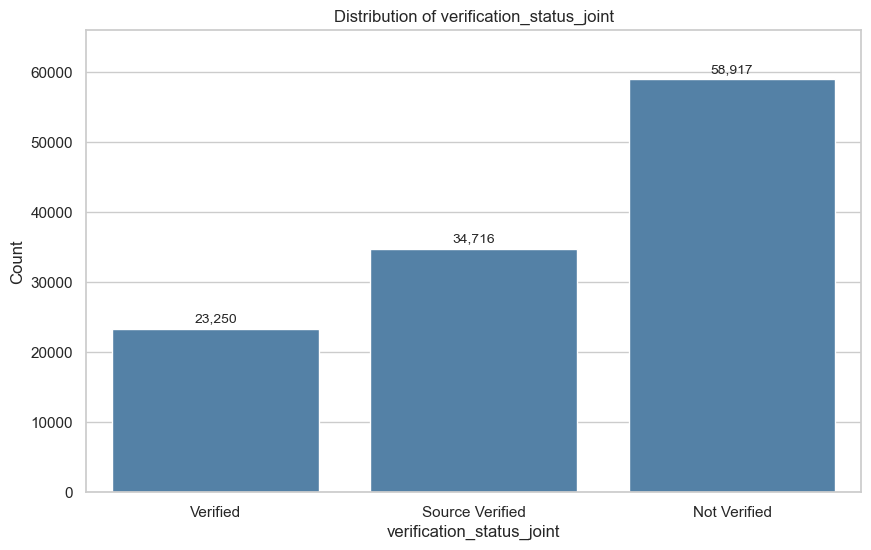

In [26]:
if 'verification_status_joint' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['verification_status_joint'].dropna()
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of verification_status_joint')
    plt.xlabel('verification_status_joint')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'verification_status_joint' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### issue_d

The month which the loan was funded.
<br>
대출이 실행된 연월. 시계열 분할 및 거시 충격 통제에 활용.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

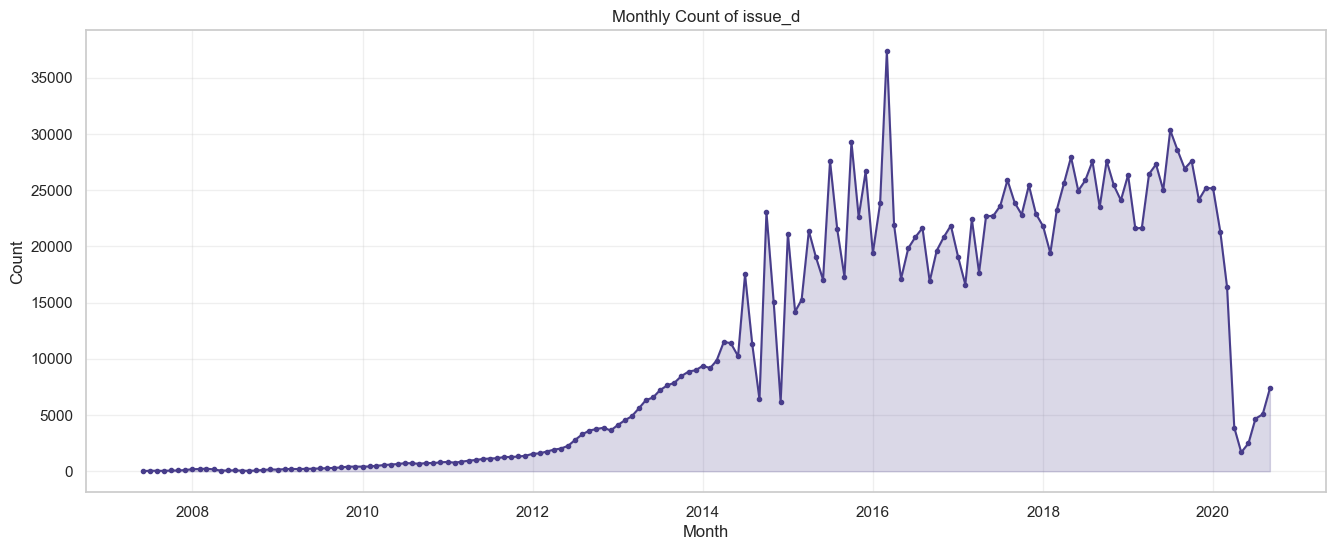

In [27]:
if 'issue_d' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['issue_d'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of issue_d')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'issue_d' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### loan_status

Current status of the loan.
<br>
대출의 현재 상태. 종속변수의 원천이며, Fully Paid / Charged Off 등 종결된 건만 라벨로 사용.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

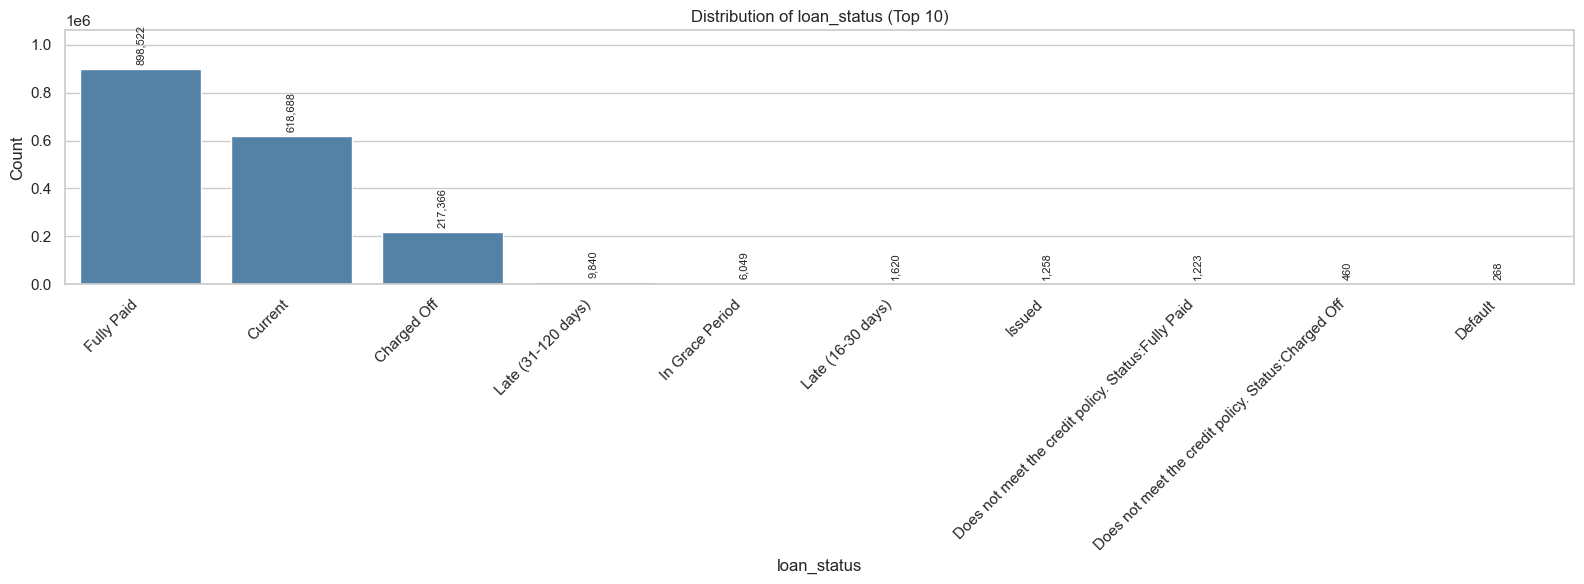

In [28]:
if 'loan_status' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 10개만 표시)
    order = lending_club['loan_status'].value_counts().index[:10]
    ax = sns.countplot(data=lending_club, x='loan_status', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of loan_status (Top 10)')
    plt.xlabel('loan_status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'loan_status' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### pymnt_plan

Indicates if a payment plan has been put in place for the loan.
<br>
분할상환 계획 적용 여부. 본 데이터에서는 전부 'n'인 상수 변수.

<br>

🚫 **사용 금지 (상수)** — 분산이 0이므로 정보량 없음. 제거.

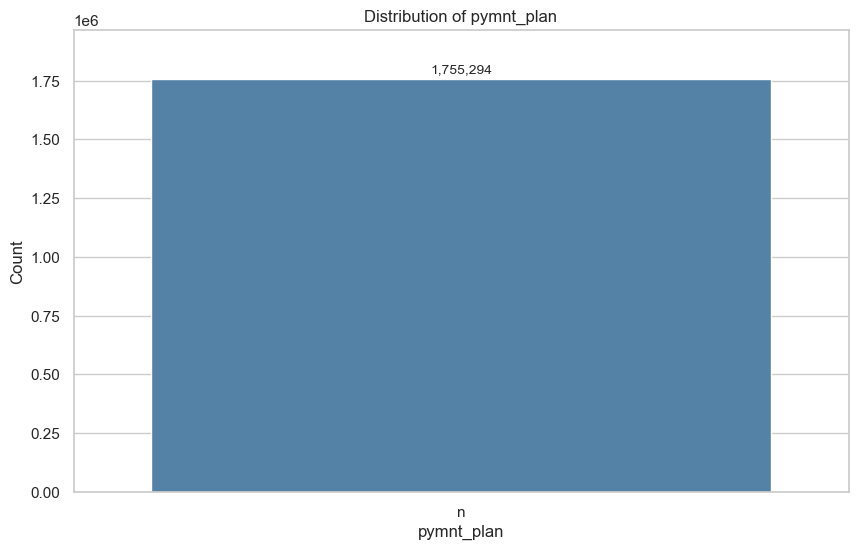

In [18]:
if 'pymnt_plan' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['pymnt_plan']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of pymnt_plan')
    plt.xlabel('pymnt_plan')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'pymnt_plan' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### desc

Loan description provided by the borrower.
<br>
차입자가 작성한 대출 설명 자유 텍스트. 최근 연도에는 수집이 중단되어 결측이 대부분.

<br>

% 이 변수는 샘플 파일에는 없으나 원본 파일에 존재할 수 있어 안전 장치를 두었습니다
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

In [30]:
if 'desc' in lending_club.columns:
    print('n unique :', lending_club['desc'].nunique())
    print('결측 비율 :', round(lending_club['desc'].isna().mean() * 100, 2), '%')
    display(lending_club['desc'].head(3))
else:
    print("'desc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

'desc' 컬럼이 데이터에 없습니다. 건너뜁니다.


In [10]:
lending_cluhb["desc"]

NameError: name 'lending_cluhb' is not defined

### purpose

A category provided by the borrower for the loan request.
<br>
차입자가 신고한 대출 목적(부채통합, 카드대환, 주택개선 등).

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

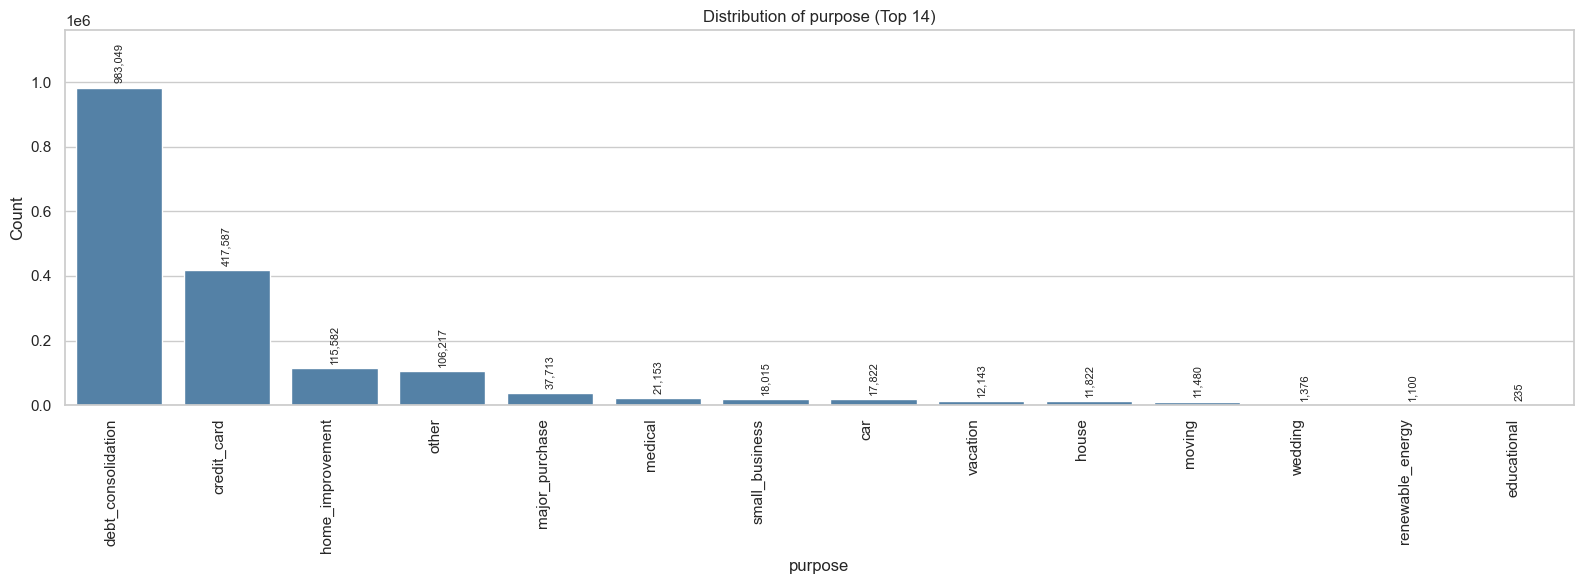

In [31]:
if 'purpose' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 14개만 표시)
    order = lending_club['purpose'].value_counts().index[:14]
    ax = sns.countplot(data=lending_club, x='purpose', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of purpose (Top 14)')
    plt.xlabel('purpose')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'purpose' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### title

The loan title provided by the borrower.
<br>
차입자가 직접 입력한 대출 제목. purpose와 중복성이 높고 자유 텍스트라 정제 필요.

<br>

% 결측치 **0.79%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

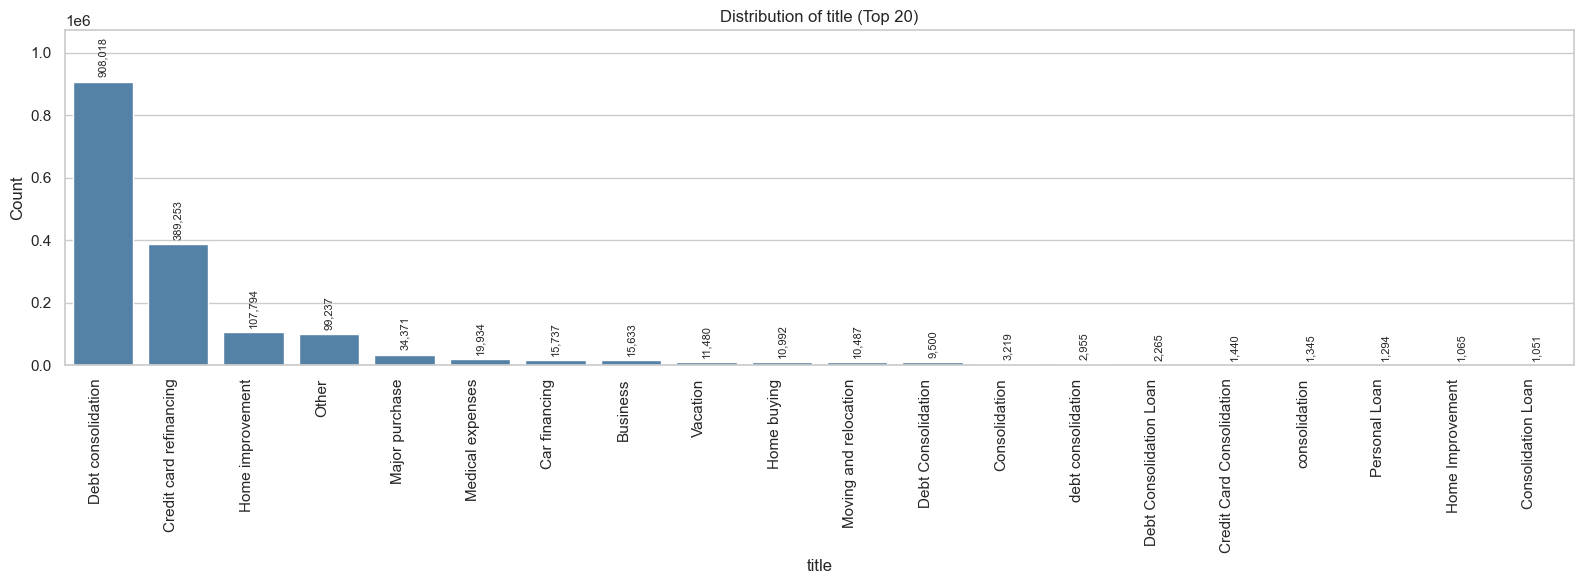

In [32]:
if 'title' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 20개만 표시)
    order = lending_club['title'].value_counts().index[:20]
    ax = sns.countplot(data=lending_club, x='title', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of title (Top 20)')
    plt.xlabel('title')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'title' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### zip_code

The first 3 numbers of the zip code provided by the borrower in the loan application.
<br>
차입자 우편번호 앞 3자리. 지역 효과를 담지만 고차원 범주형이라 타깃 인코딩 등의 처리 필요.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

In [13]:
lending_club["zip_code"].value_counts()

zip_code
750xx    18262
112xx    18172
945xx    18131
606xx    16090
300xx    15766
         ...  
867xx        1
889xx        1
504xx        1
509xx        1
938xx        1
Name: count, Length: 946, dtype: int64

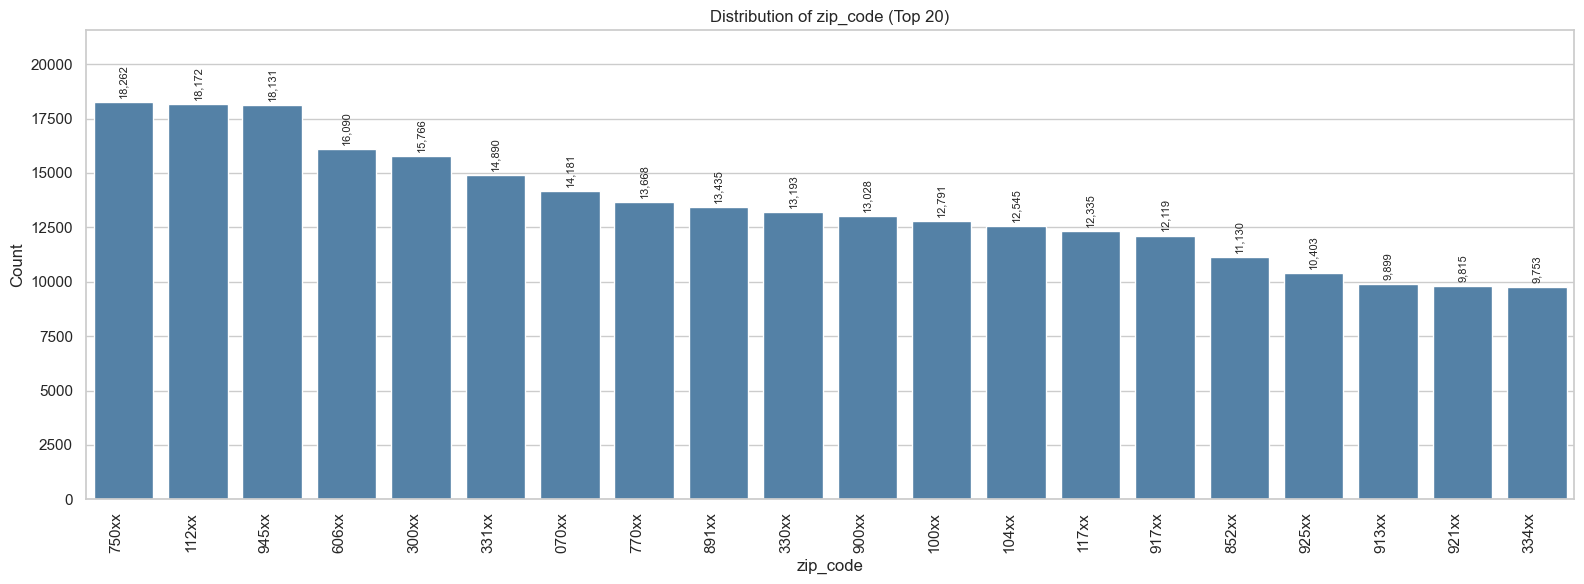

In [33]:
if 'zip_code' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 20개만 표시)
    order = lending_club['zip_code'].value_counts().index[:20]
    ax = sns.countplot(data=lending_club, x='zip_code', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of zip_code (Top 20)')
    plt.xlabel('zip_code')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'zip_code' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### addr_state

The state provided by the borrower in the loan application.
<br>
차입자가 거주하는 미국의 주(State). CA, TX, NY, FL에 집중.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

In [11]:
lending_club["addr_state"].value_counts()

addr_state
CA    243355
TX    145358
NY    141919
FL    127238
IL     70392
NJ     64068
PA     58869
OH     58068
GA     57700
VA     48735
NC     48701
MI     45192
AZ     42032
MD     41903
MA     40356
WA     36996
CO     36593
MN     30316
IN     29084
TN     28091
MO     28039
CT     27995
NV     25607
WI     23157
SC     22249
OR     21227
AL     20717
LA     19668
KY     17107
OK     15927
KS     14758
AR     13194
UT     11758
MS     10117
NM      9343
NH      8767
HI      8187
RI      7879
WV      7458
NE      6652
DE      4994
MT      4949
ME      4323
ID      4089
AK      4069
DC      4021
VT      3913
WY      3617
SD      3506
ND      3030
IA        11
Name: count, dtype: int64

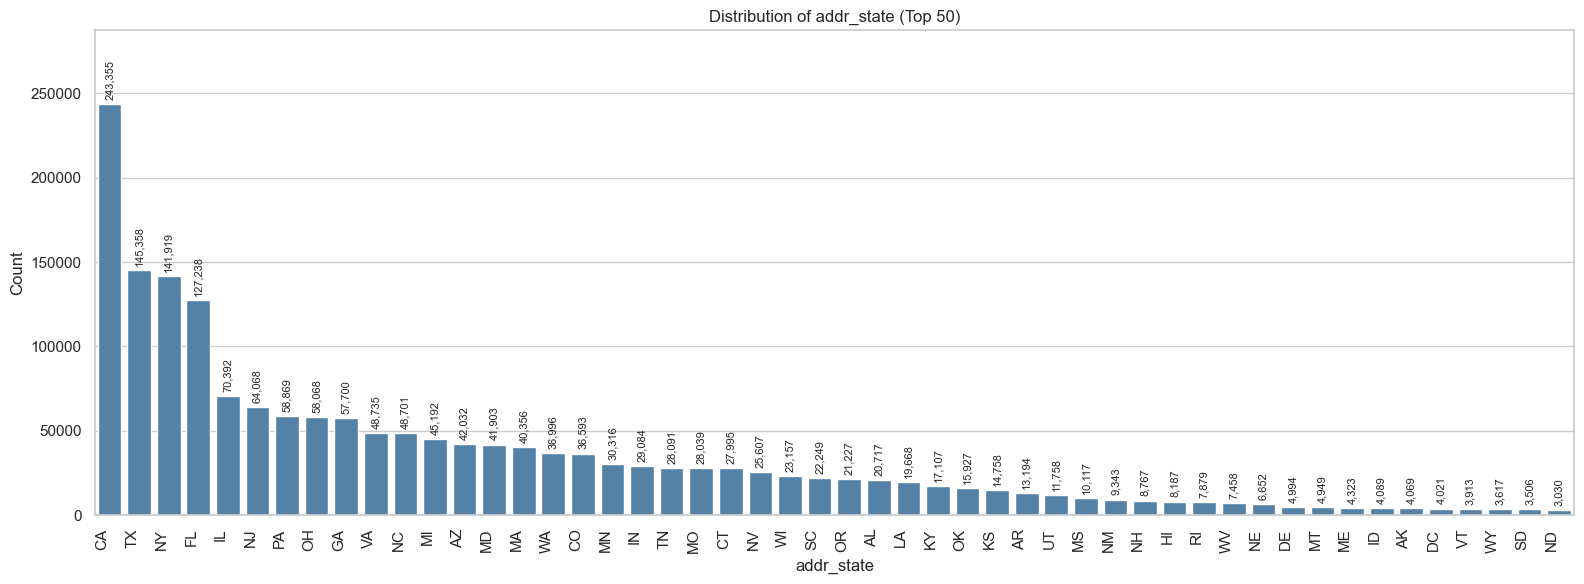

In [34]:
if 'addr_state' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 50개만 표시)
    order = lending_club['addr_state'].value_counts().index[:50]
    ax = sns.countplot(data=lending_club, x='addr_state', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of addr_state (Top 50)')
    plt.xlabel('addr_state')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'addr_state' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### dti

A ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower's self-reported monthly income.
<br>
월 소득 대비 월 부채상환액 비율(%). 999 같은 코드성 이상치가 섞여 있으므로 절단·정제가 필요.

<br>

% 결측치 **0.11%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 60 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

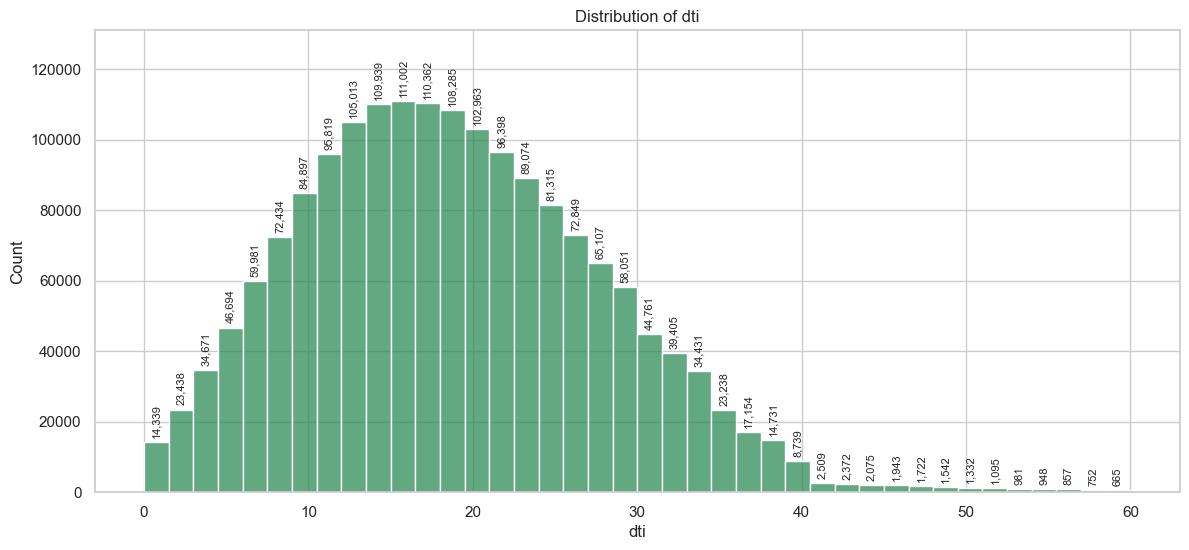

In [35]:
if 'dti' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['dti'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 60]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of dti')
    plt.xlabel('dti')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'dti' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### dti_joint

A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income.
<br>
공동 신청자 기준 부채상환비율(%). 개인 대출 건은 구조적 결측.

<br>

% 결측치 **92.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 60 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

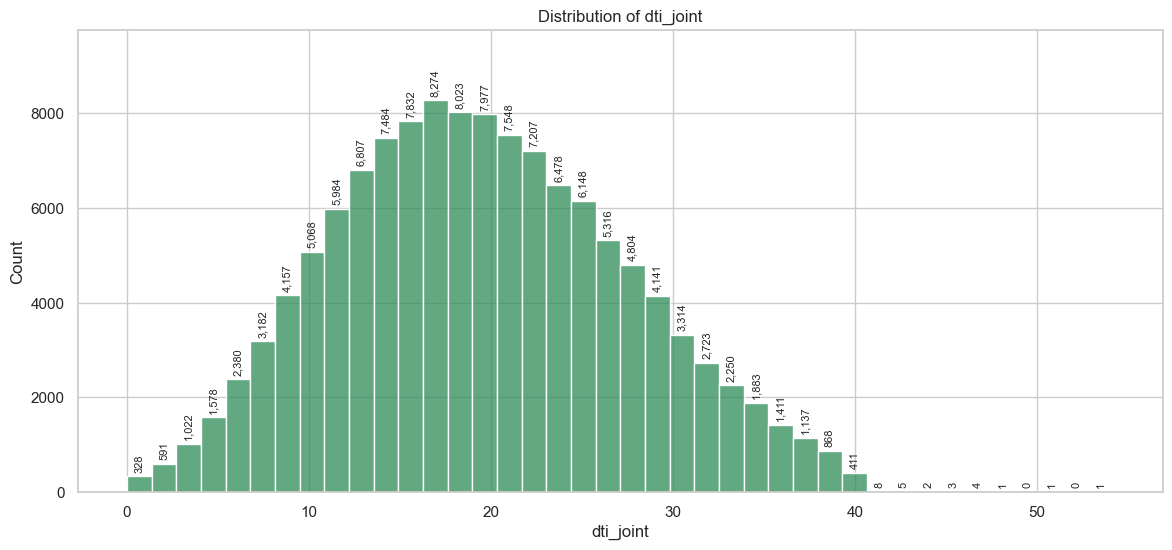

In [36]:
if 'dti_joint' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['dti_joint'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 60]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of dti_joint')
    plt.xlabel('dti_joint')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'dti_joint' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### delinq_2yrs

The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years.
<br>
최근 2년간 30일 이상 연체 발생 건수.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 8 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

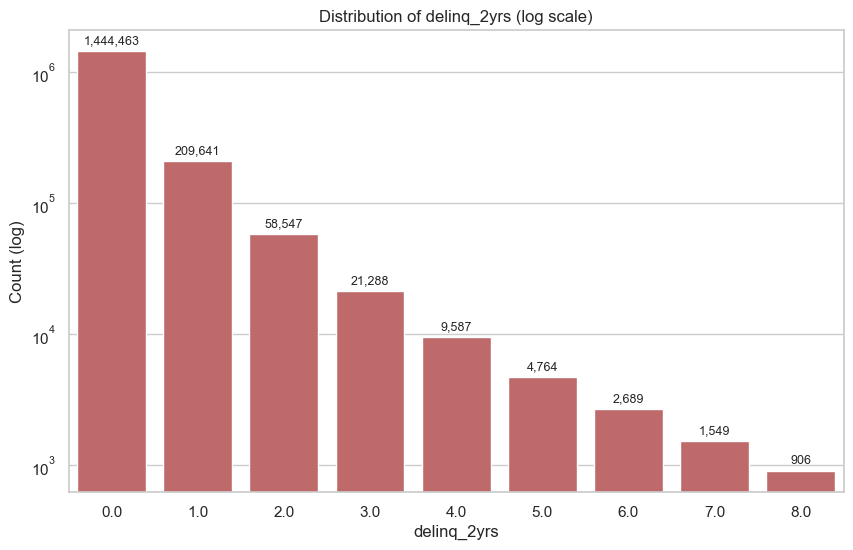

In [37]:
if 'delinq_2yrs' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['delinq_2yrs'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 8]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of delinq_2yrs (log scale)')
    plt.xlabel('delinq_2yrs')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'delinq_2yrs' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### delinq_amnt

The past-due amount owed for the accounts on which the borrower is now delinquent.
<br>
현재 연체 중인 계좌의 연체 금액. 대부분 0인 극단적 불균형 변수.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 5,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

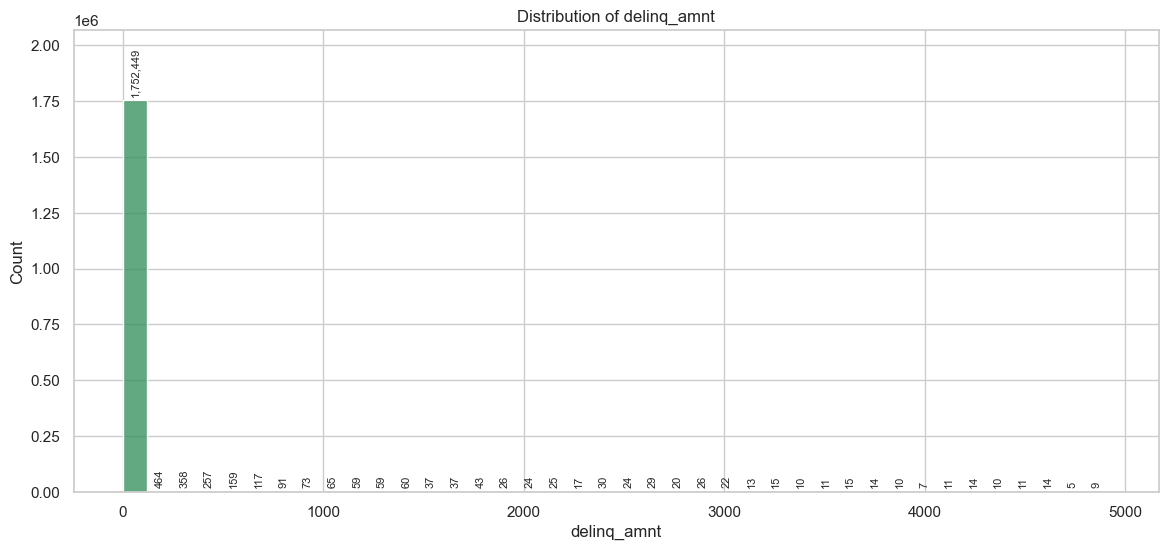

In [38]:
if 'delinq_amnt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['delinq_amnt'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of delinq_amnt')
    plt.xlabel('delinq_amnt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'delinq_amnt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### acc_now_delinq

The number of accounts on which the borrower is now delinquent.
<br>
차입자의 현재 연체 중인 계좌 수. 대부분 0.

<br>

% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

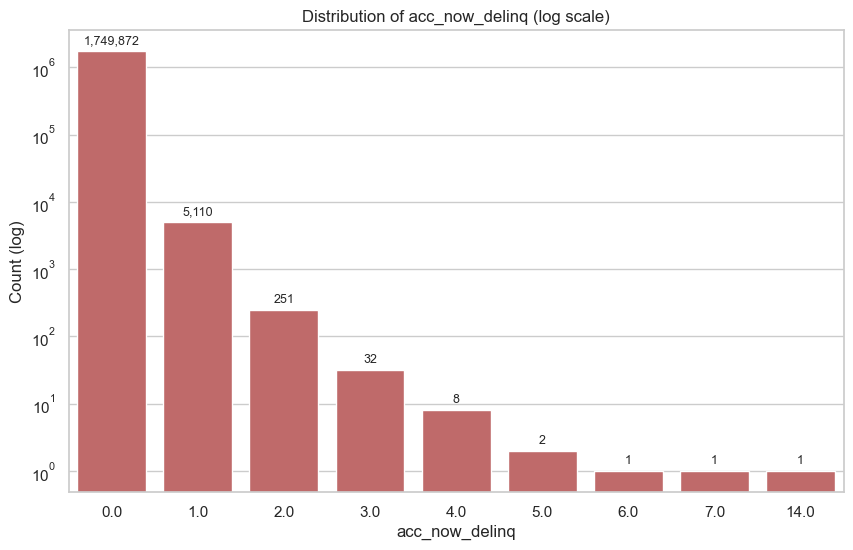

In [39]:
if 'acc_now_delinq' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['acc_now_delinq'].dropna()
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of acc_now_delinq (log scale)')
    plt.xlabel('acc_now_delinq')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'acc_now_delinq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### acc_open_past_24mths

Number of trades opened in past 24 months.
<br>
과거 24개월 동안 새로 개설한 계좌 수.

<br>

% 결측치 **1.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 25 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

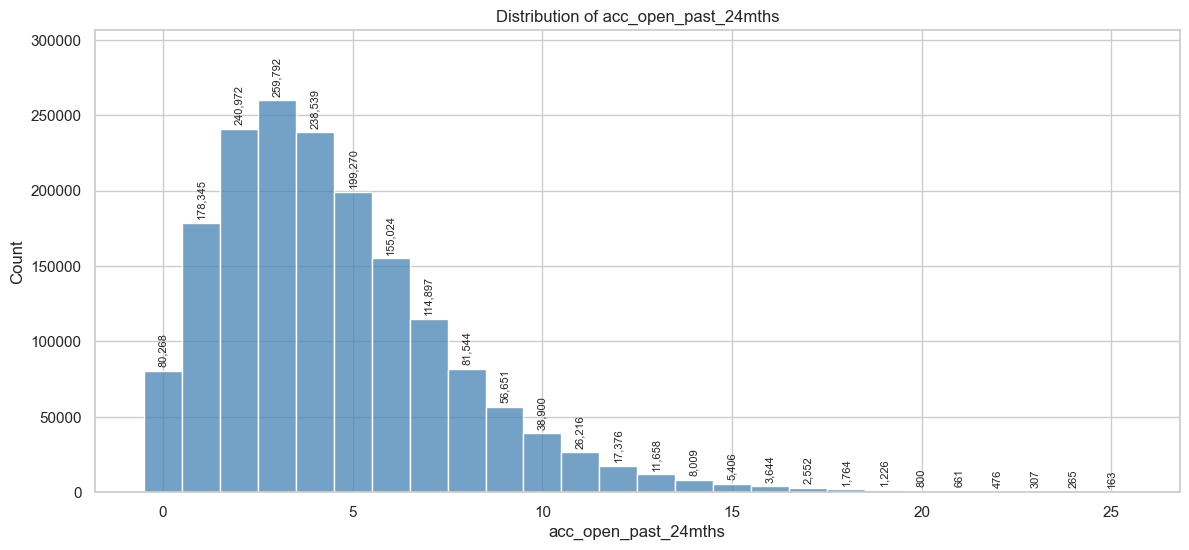

In [40]:
if 'acc_open_past_24mths' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['acc_open_past_24mths'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 25]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of acc_open_past_24mths')
    plt.xlabel('acc_open_past_24mths')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'acc_open_past_24mths' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### earliest_cr_line

The month the borrower's earliest reported credit line was opened.
<br>
최초 신용거래 개설 시점. 현재 시점과의 차이를 신용 이력 길이로 파생시키는 것이 핵심.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

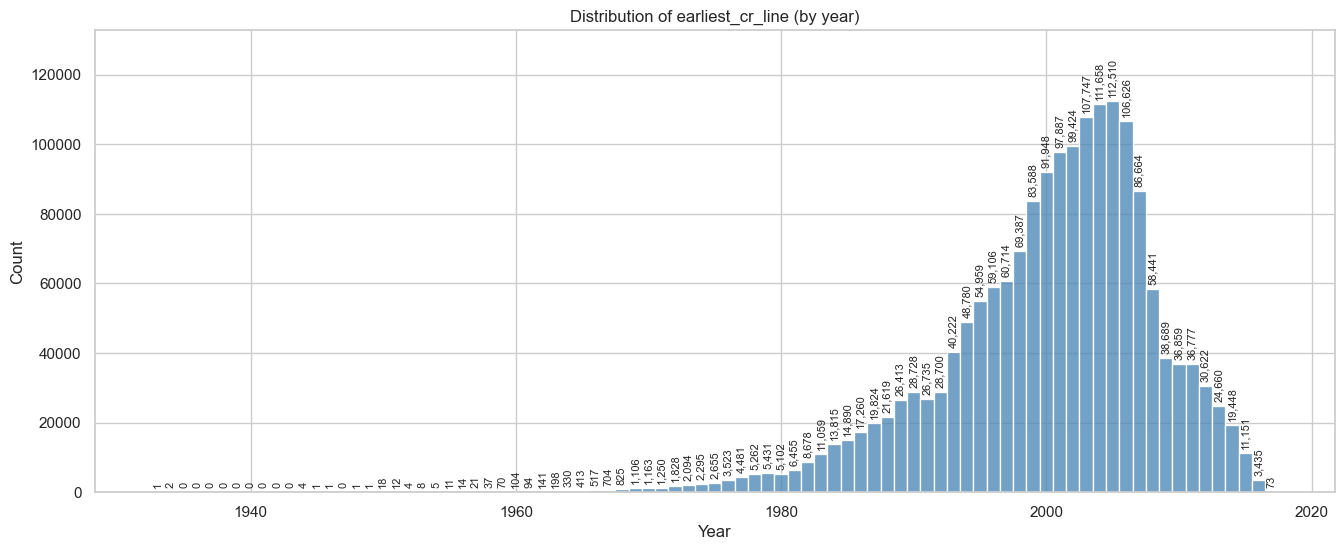

In [41]:
if 'earliest_cr_line' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 연도 단위로 변환하여 분포 확인
    s = pd.to_datetime(lending_club['earliest_cr_line'], format='%b-%Y', errors='coerce').dropna()
    ax = sns.histplot(x=s.dt.year, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of earliest_cr_line (by year)')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'earliest_cr_line' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### fico_range_low

The lower boundary range the borrower's FICO at loan origination belongs to.
<br>
대출 실행 시점 FICO 점수 구간의 하한. 승인 시점 정보이므로 사용 가능.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

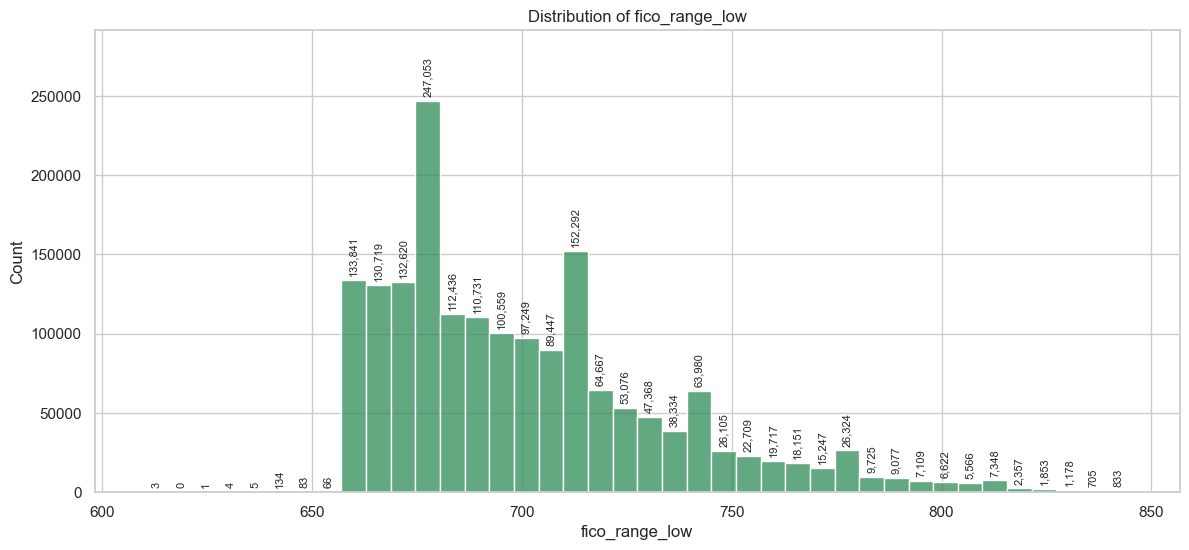

In [42]:
if 'fico_range_low' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['fico_range_low'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of fico_range_low')
    plt.xlabel('fico_range_low')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'fico_range_low' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### fico_range_high

The upper boundary range the borrower's FICO at loan origination belongs to.
<br>
대출 실행 시점 FICO 점수 구간의 상한. low와 항상 4점 차이(완전 상관).

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

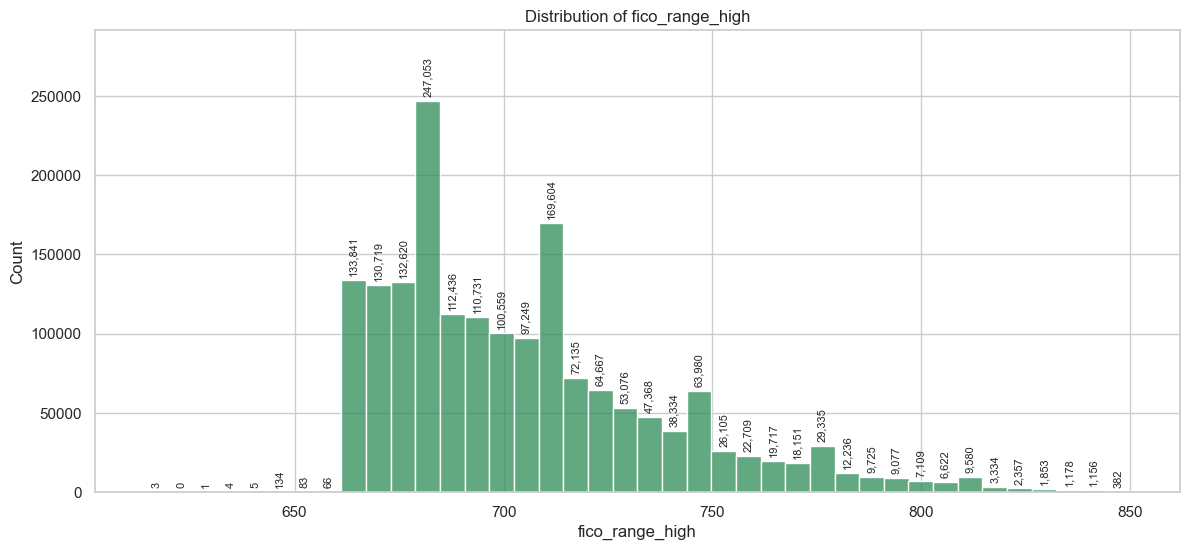

In [43]:
if 'fico_range_high' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['fico_range_high'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of fico_range_high')
    plt.xlabel('fico_range_high')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'fico_range_high' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### inq_last_6mths

The number of inquiries in past 6 months (excluding auto and mortgage inquiries).
<br>
최근 6개월간 신용 조회 건수. 신용 갈증(credit hunger)의 대표 지표.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

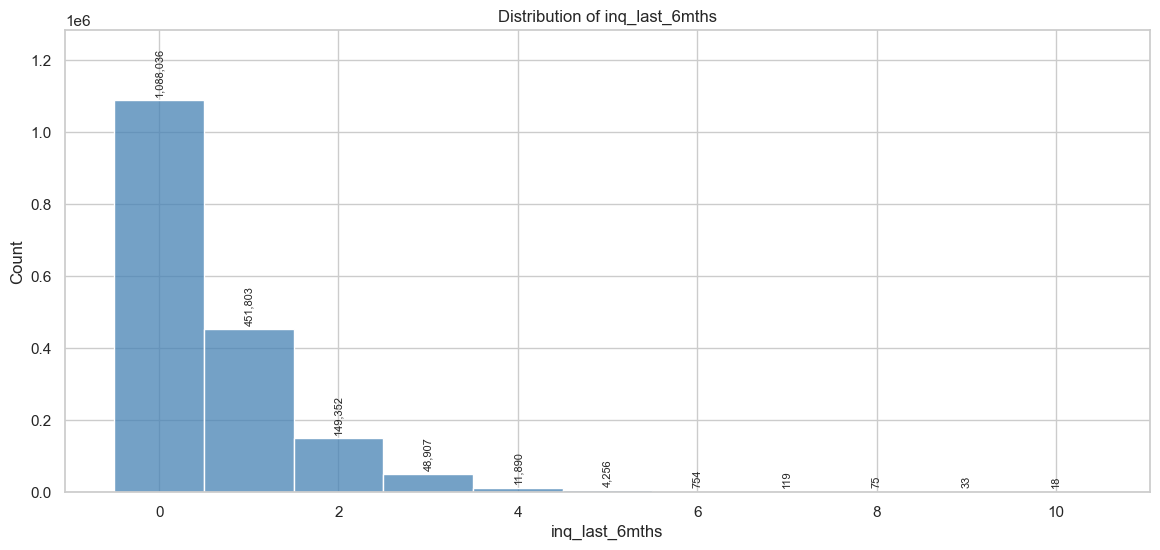

In [44]:
if 'inq_last_6mths' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['inq_last_6mths'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of inq_last_6mths')
    plt.xlabel('inq_last_6mths')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'inq_last_6mths' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### inq_fi

Number of personal finance inquiries.
<br>
개인금융 관련 신용 조회 건수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

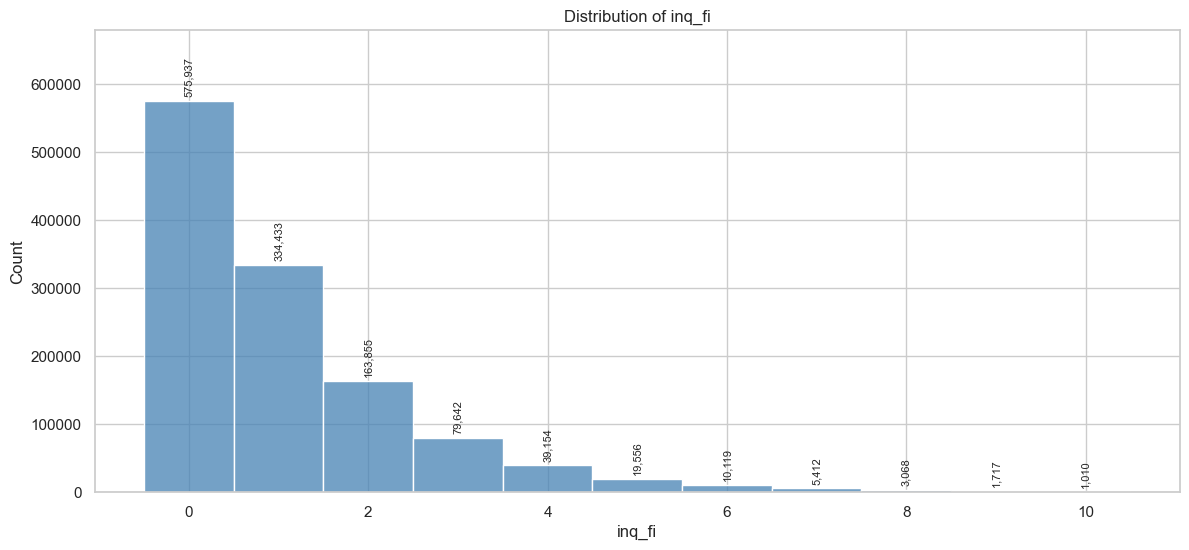

In [45]:
if 'inq_fi' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['inq_fi'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of inq_fi')
    plt.xlabel('inq_fi')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'inq_fi' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### inq_last_12m

Number of credit inquiries in past 12 months.
<br>
최근 12개월간 신용 조회 건수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 15 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

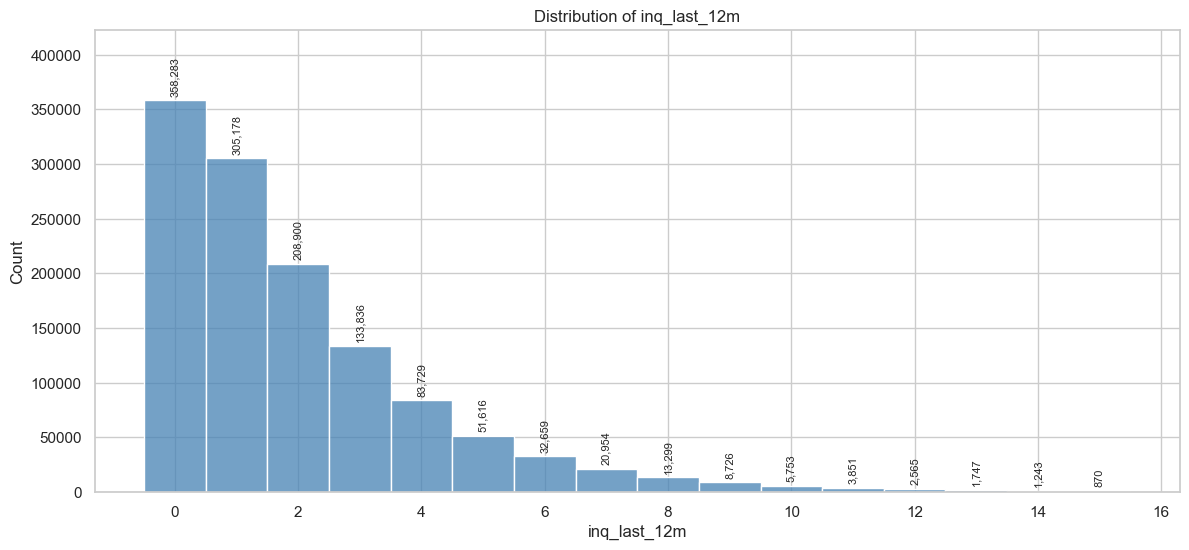

In [46]:
if 'inq_last_12m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['inq_last_12m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 15]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of inq_last_12m')
    plt.xlabel('inq_last_12m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'inq_last_12m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### all_util

Balance to credit limit on all trades.
<br>
전체 신용 한도 대비 사용 비율(%).

<br>

% 결측치 **29.62%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

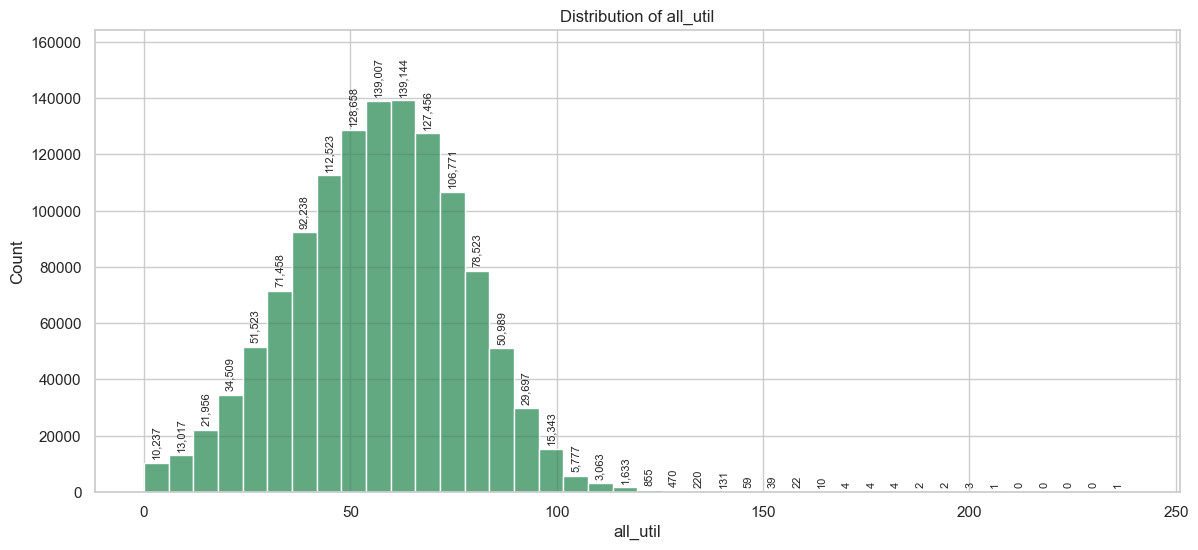

In [47]:
if 'all_util' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['all_util'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of all_util')
    plt.xlabel('all_util')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'all_util' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### il_util

Ratio of total current balance to high credit/credit limit on all install acct.
<br>
할부 계좌의 한도 대비 잔액 비율(%).

<br>

% 결측치 **39.56%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

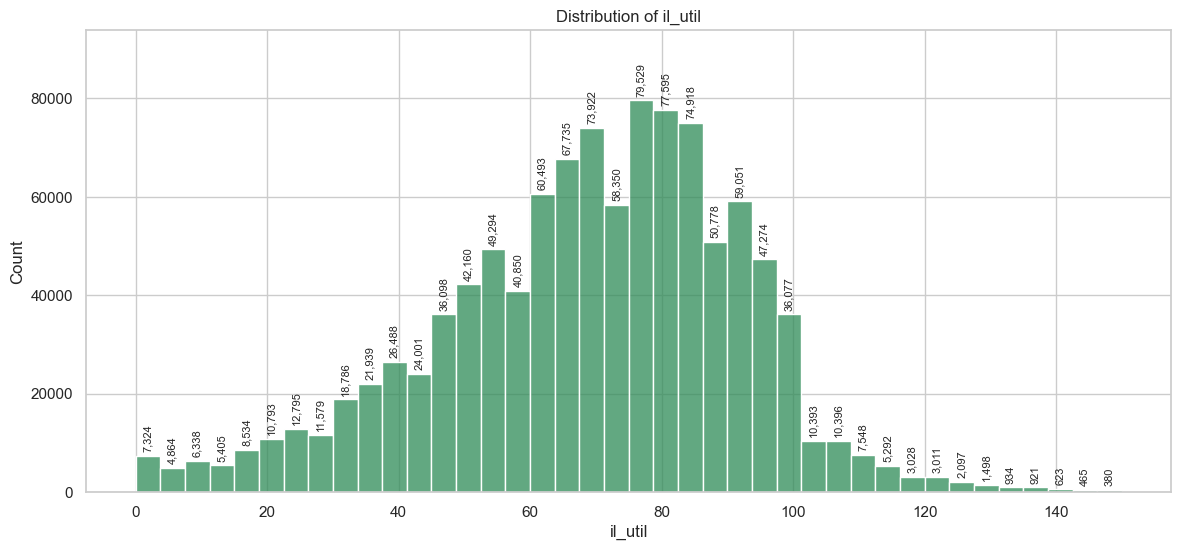

In [48]:
if 'il_util' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['il_util'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of il_util')
    plt.xlabel('il_util')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'il_util' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### bc_util

Ratio of total current balance to high credit/credit limit for all bankcard accounts.
<br>
은행 신용카드의 한도 대비 사용률(%).

<br>

% 결측치 **2.86%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

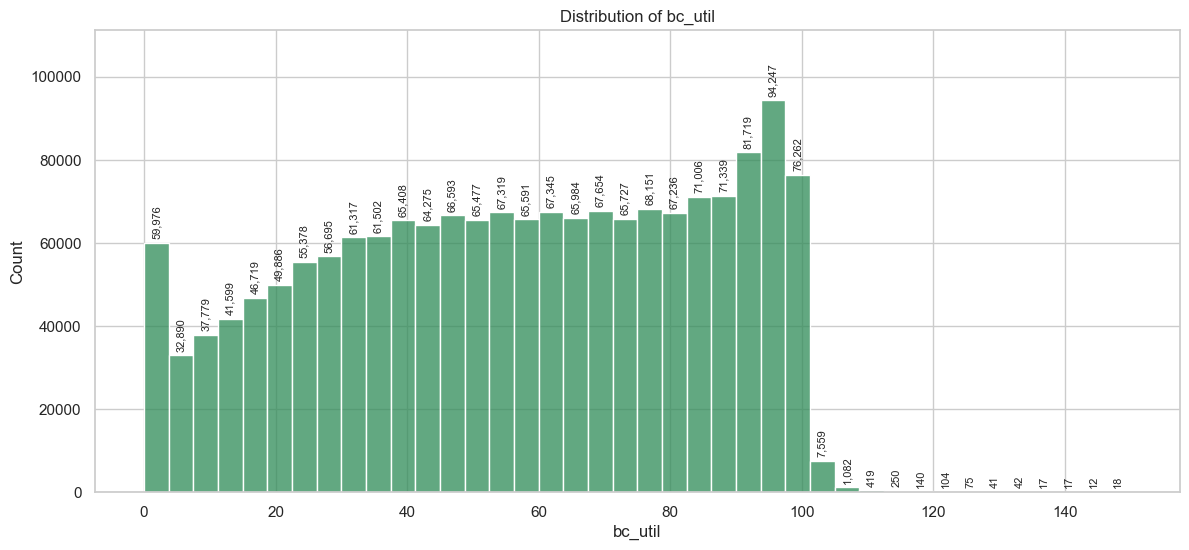

In [49]:
if 'bc_util' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['bc_util'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of bc_util')
    plt.xlabel('bc_util')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'bc_util' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### bc_open_to_buy

Total open to buy on revolving bankcards.
<br>
은행 발급 신용카드의 총 가용 한도(잔여 사용 가능액).

<br>

% 결측치 **2.8%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 50,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

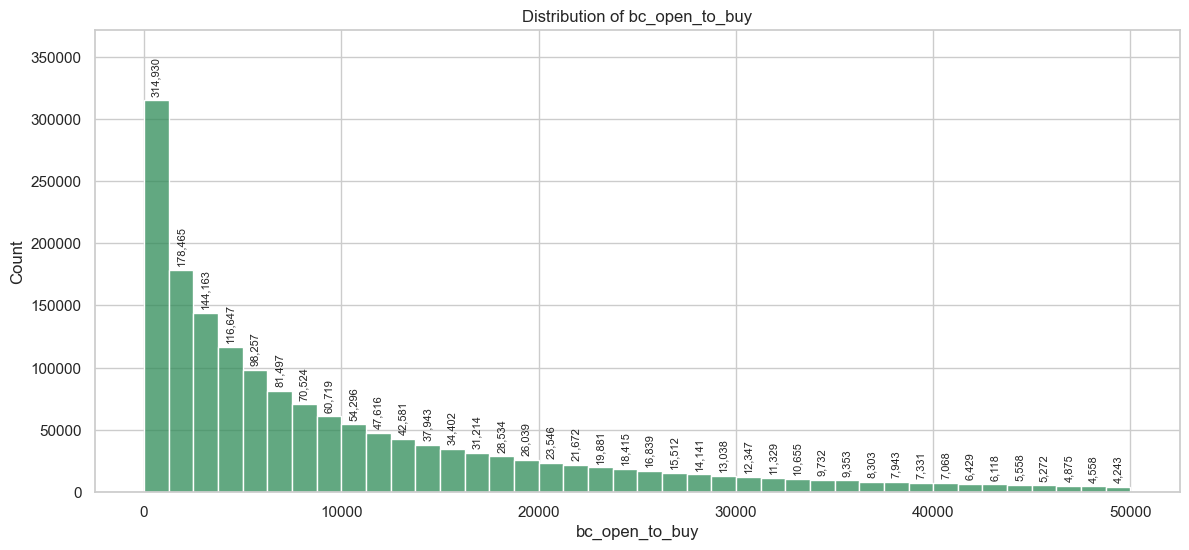

In [50]:
if 'bc_open_to_buy' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['bc_open_to_buy'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 50000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of bc_open_to_buy')
    plt.xlabel('bc_open_to_buy')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'bc_open_to_buy' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### avg_cur_bal

Average current balance of all accounts.
<br>
보유한 모든 계좌의 평균 현재 잔액.

<br>

% 결측치 **2.34%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 100,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

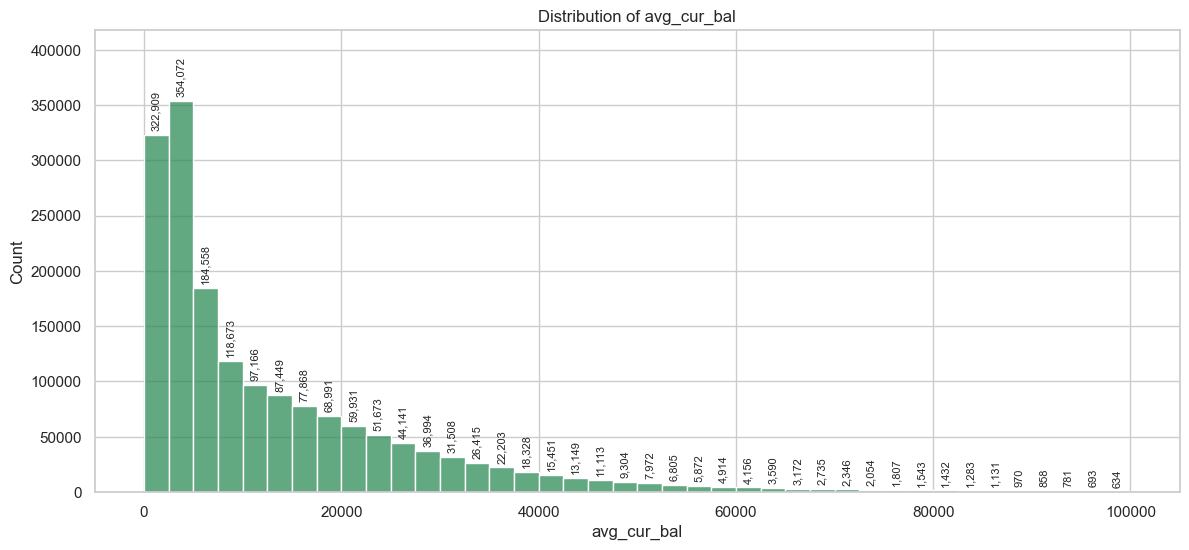

In [51]:
if 'avg_cur_bal' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['avg_cur_bal'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 100000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of avg_cur_bal')
    plt.xlabel('avg_cur_bal')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'avg_cur_bal' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### application_type

Indicates whether the loan is an individual application or a joint application with two co-borrowers.
<br>
개인 신청인지 공동 신청인지 여부. sec_app_* 계열 결측의 원인이 되는 핵심 분기 변수.

<br>

✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

ERROR! Session/line number was not unique in database. History logging moved to new session 5


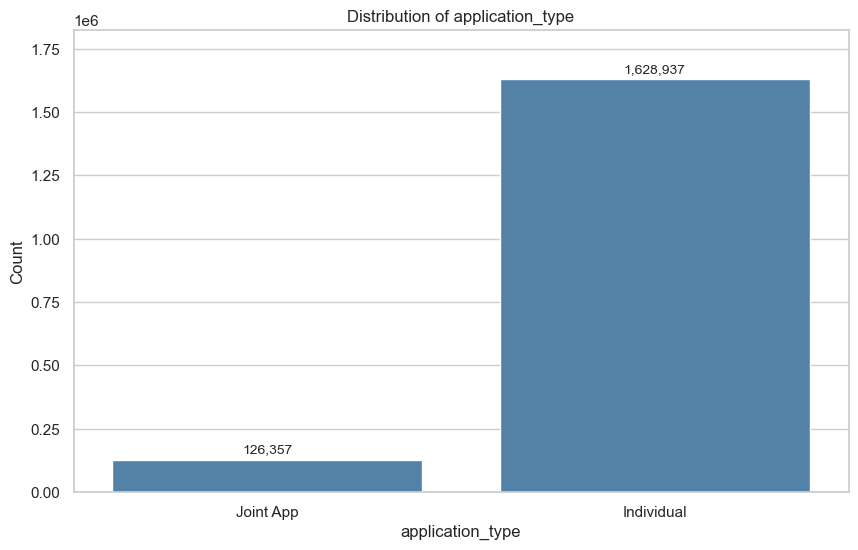

In [52]:
if 'application_type' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['application_type']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of application_type')
    plt.xlabel('application_type')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'application_type' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### initial_list_status

The initial listing status of the loan. Possible values are W, F.
<br>
최초 등록 방식(whole / fractional). LC 내부 운영 정책의 결과.

<br>

⚠️ **사용 금지 (내생변수)** — LC의 심사·가격 결정의 결과물. 종속변수와 동시 결정되므로 설명변수로 부적절.

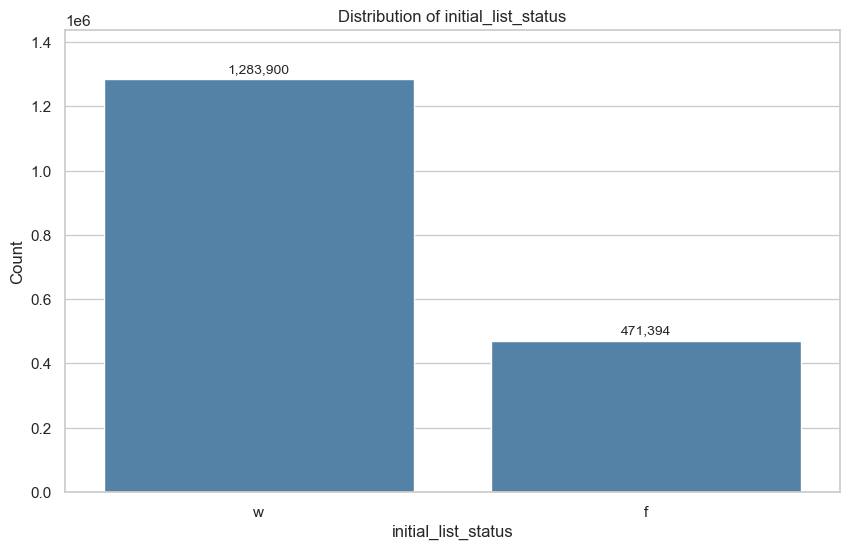

In [53]:
if 'initial_list_status' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['initial_list_status']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of initial_list_status')
    plt.xlabel('initial_list_status')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'initial_list_status' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### chargeoff_within_12_mths

Number of charge-offs within 12 months.
<br>
최근 12개월 이내 상각(charge-off) 처리된 부채 건수. 상각은 회수 불가로 판단해 손실 처리한 악성 부채.

<br>

% 결측치 **0.01%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 4 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

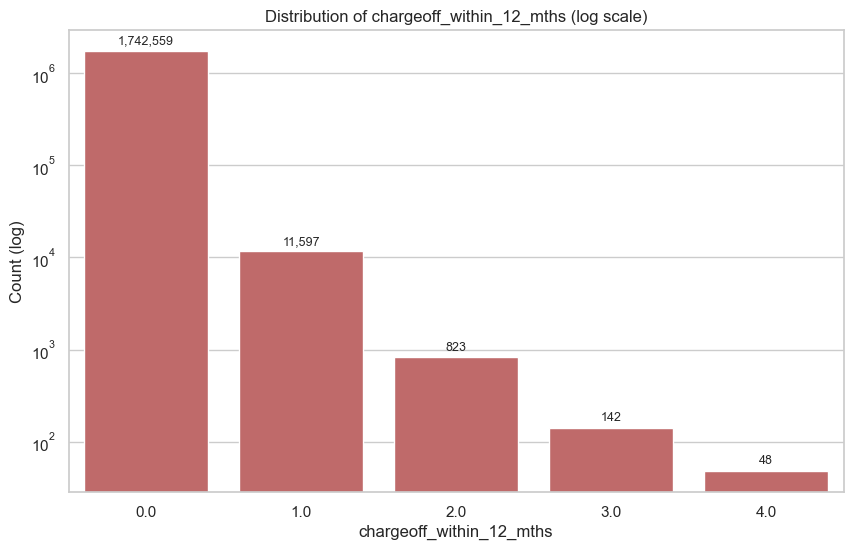

In [54]:
if 'chargeoff_within_12_mths' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['chargeoff_within_12_mths'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 4]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of chargeoff_within_12_mths (log scale)')
    plt.xlabel('chargeoff_within_12_mths')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'chargeoff_within_12_mths' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### collections_12_mths_ex_med

Number of collections in 12 months excluding medical collections.
<br>
최근 12개월간 추심 건수(의료비 제외).

<br>

% 결측치 **0.01%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 4 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

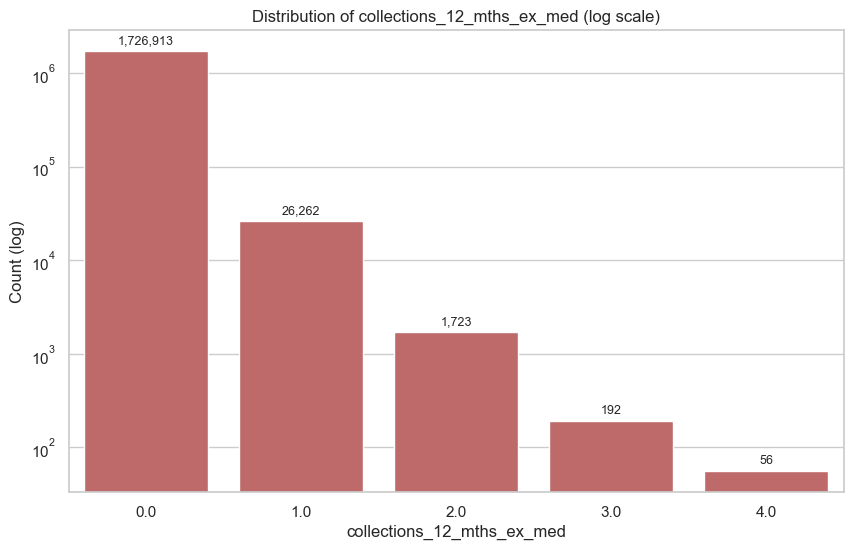

In [55]:
if 'collections_12_mths_ex_med' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['collections_12_mths_ex_med'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 4]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of collections_12_mths_ex_med (log scale)')
    plt.xlabel('collections_12_mths_ex_med')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'collections_12_mths_ex_med' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### collection_recovery_fee

Post charge off collection fee.
<br>
상각 이후 추심 과정에서 발생한 수수료. 대출 실행 후 결과이므로 예측 변수로는 사용 불가.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 2,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

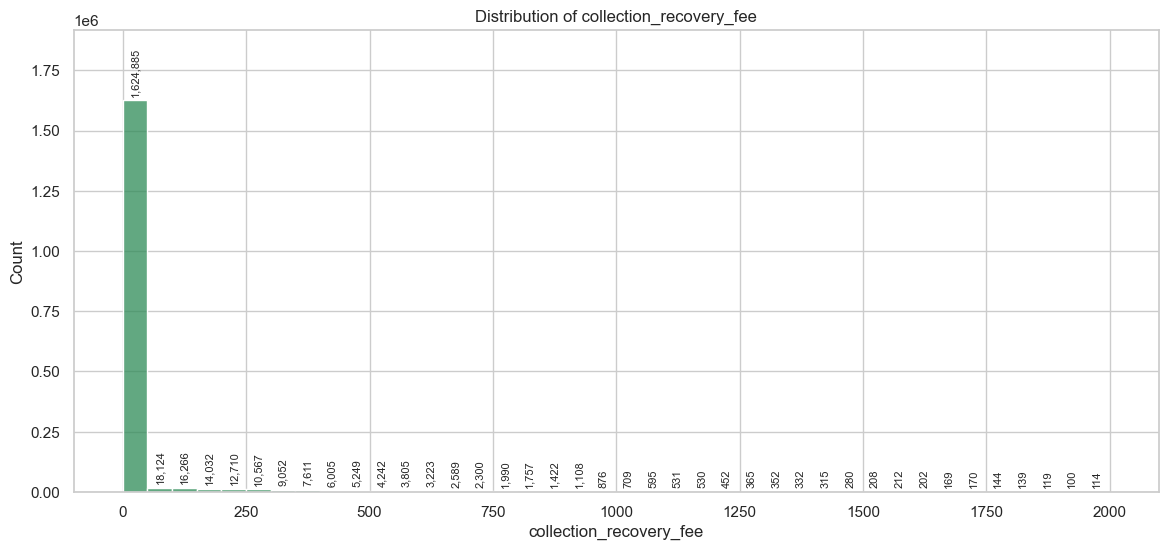

In [56]:
if 'collection_recovery_fee' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['collection_recovery_fee'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 2000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of collection_recovery_fee')
    plt.xlabel('collection_recovery_fee')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'collection_recovery_fee' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### debt_settlement_flag

Flag indicating whether the borrower, who has charged-off, is working with a debt-settlement company.
<br>
채무조정(추심 합의) 회사와 협상 중인지 여부. 상각된 차입자에게 붙는 플래그.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

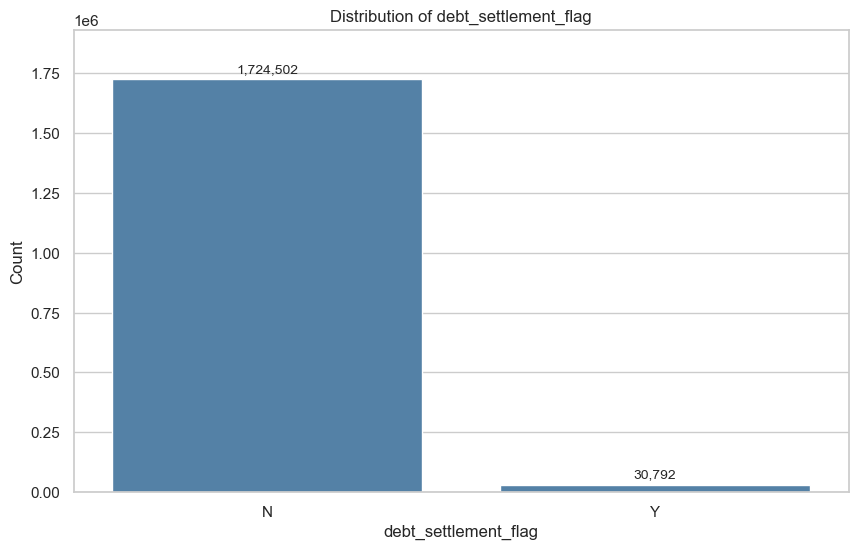

In [57]:
if 'debt_settlement_flag' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['debt_settlement_flag']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of debt_settlement_flag')
    plt.xlabel('debt_settlement_flag')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'debt_settlement_flag' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### deferral_term

Amount of months that the borrower is expected to pay less than the contractual monthly payment amount due to a hardship plan.
<br>
하드십(상환유예) 플랜으로 인해 정상 납입액보다 적게 내도 되는 개월 수.

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

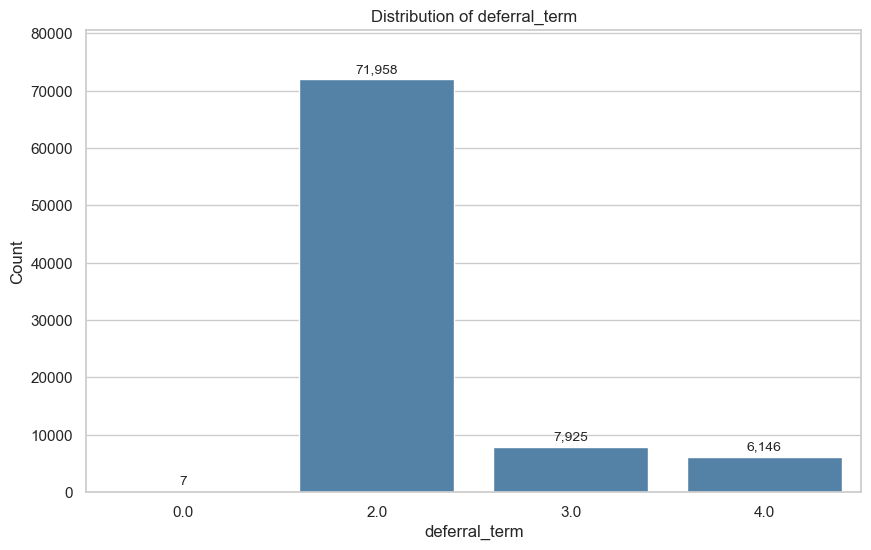

In [58]:
if 'deferral_term' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['deferral_term'].dropna()
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of deferral_term')
    plt.xlabel('deferral_term')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'deferral_term' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_amount

The interest payment that the borrower has committed to make each month while they are on a hardship plan.
<br>
하드십 플랜 기간 동안 차입자가 매월 납부하기로 약정한 이자 금액.

<br>

% 결측치 **93.75%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 1,500 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

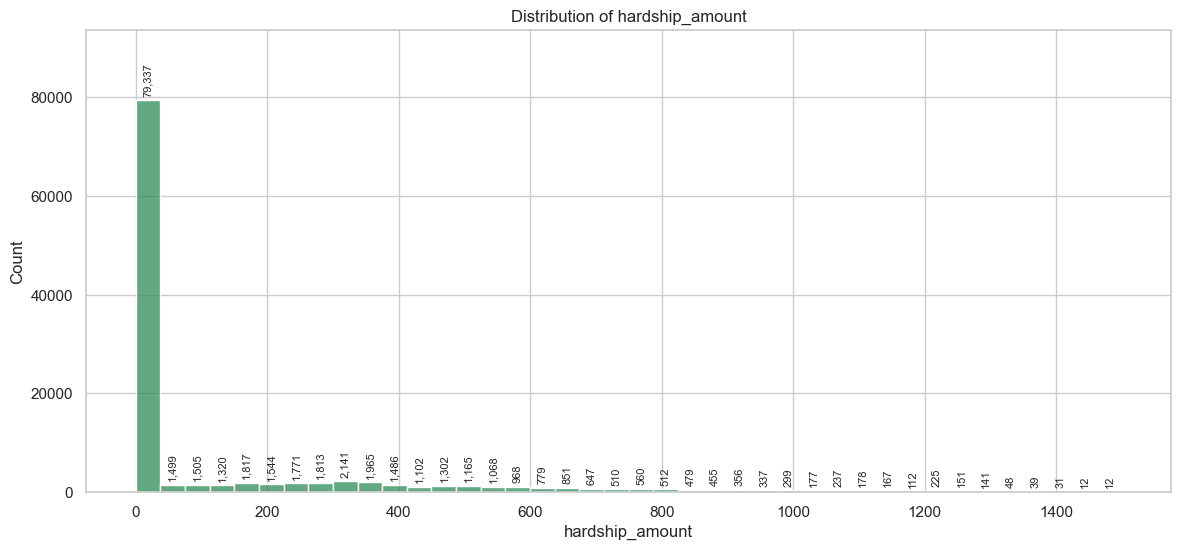

In [59]:
if 'hardship_amount' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['hardship_amount'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 1500]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_amount')
    plt.xlabel('hardship_amount')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'hardship_amount' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_dpd

Account days past due as of the hardship plan start date.
<br>
하드십 플랜 시작 시점의 연체 경과일수(DPD).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 60 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

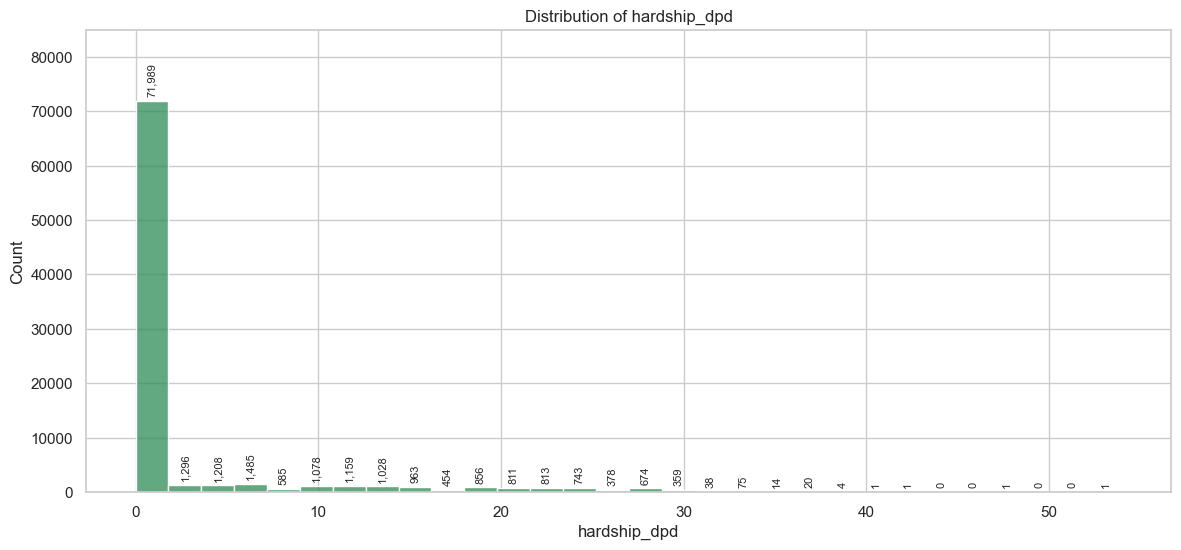

In [60]:
if 'hardship_dpd' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['hardship_dpd'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 60]
    ax = sns.histplot(x=data_to_plot, bins=30, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_dpd')
    plt.xlabel('hardship_dpd')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'hardship_dpd' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_end_date

The end date of the hardship plan period.
<br>
하드십 플랜 종료 시점(월 단위).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

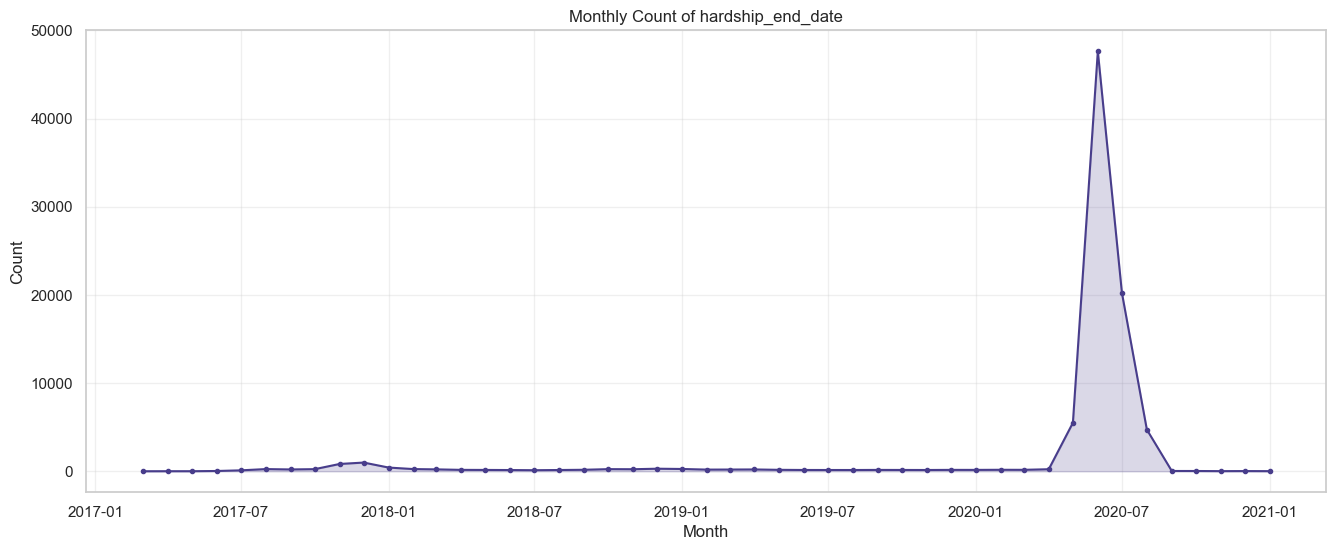

In [61]:
if 'hardship_end_date' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['hardship_end_date'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of hardship_end_date')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'hardship_end_date' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_flag

Flags whether or not the borrower is on a hardship plan.
<br>
차입자가 하드십(상환유예) 플랜 적용 중인지 여부.

<br>

% 결측치 **1.33%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

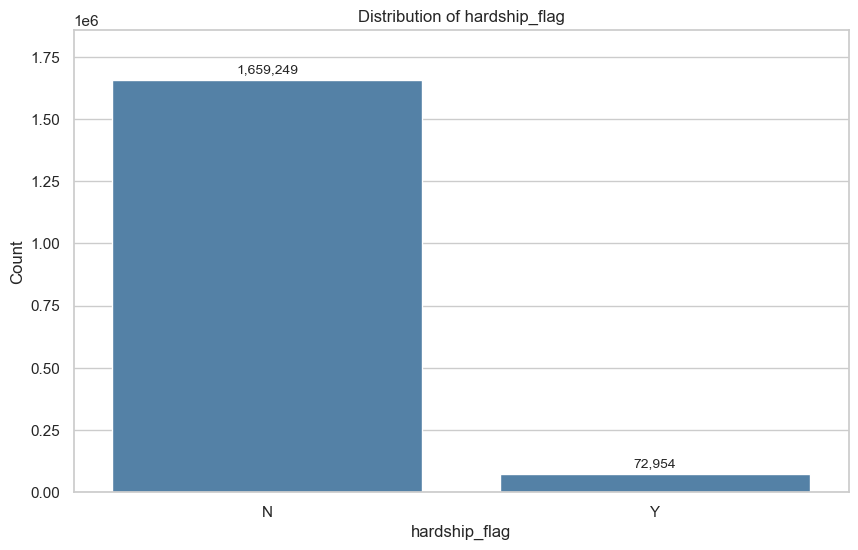

In [62]:
if 'hardship_flag' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['hardship_flag']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of hardship_flag')
    plt.xlabel('hardship_flag')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'hardship_flag' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_last_payment_amount

The last payment amount as of the hardship plan start date.
<br>
하드십 플랜 시작 시점 기준 마지막 납입 금액.

<br>

% 결측치 **93.75%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 3,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

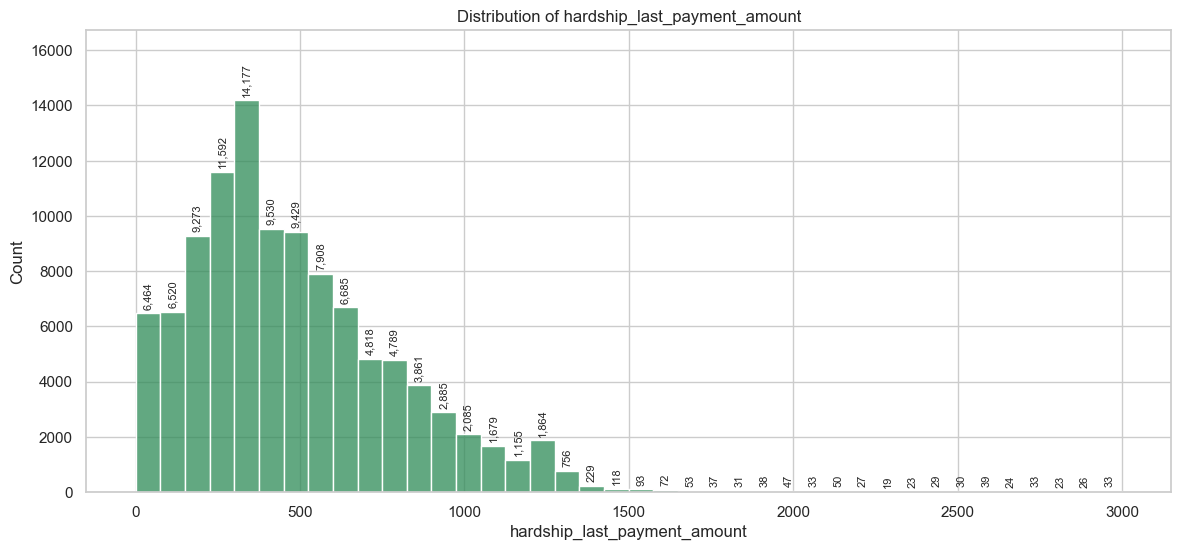

In [63]:
if 'hardship_last_payment_amount' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['hardship_last_payment_amount'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 3000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_last_payment_amount')
    plt.xlabel('hardship_last_payment_amount')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'hardship_last_payment_amount' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_length

The number of months the borrower will make smaller payments than normally obligated due to a hardship plan.
<br>
하드십 플랜으로 감액 납부하는 기간(개월).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

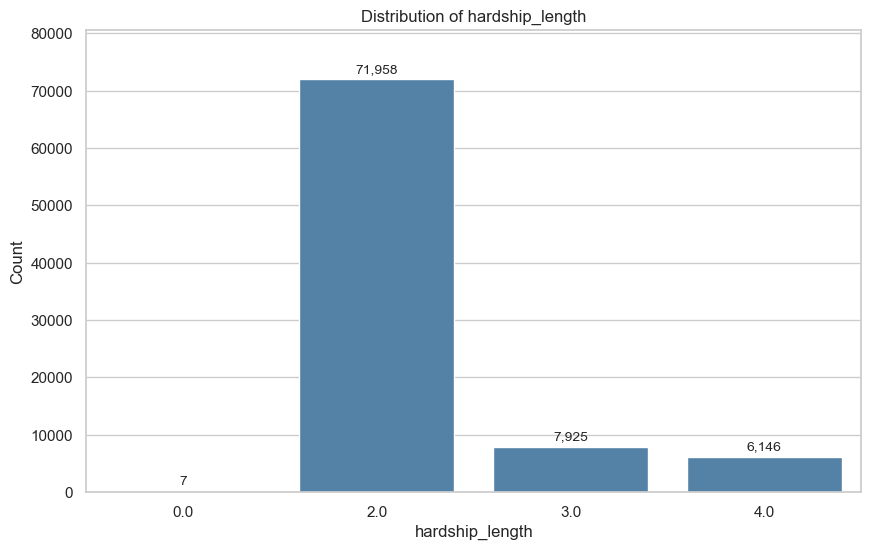

In [64]:
if 'hardship_length' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['hardship_length'].dropna()
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of hardship_length')
    plt.xlabel('hardship_length')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'hardship_length' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_loan_status

Loan Status as of the hardship plan start date.
<br>
하드십 플랜 시작 시점의 대출 상태.

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

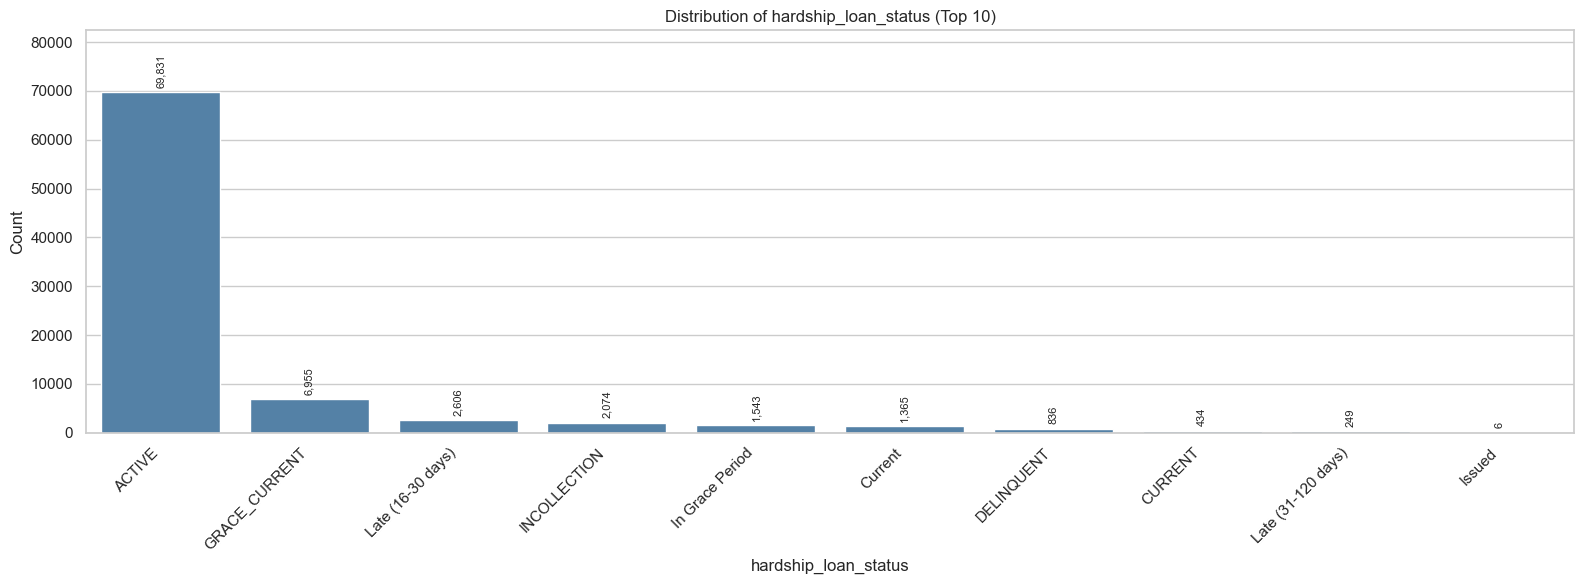

In [65]:
if 'hardship_loan_status' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 10개만 표시)
    order = lending_club['hardship_loan_status'].value_counts().index[:10]
    ax = sns.countplot(data=lending_club, x='hardship_loan_status', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_loan_status (Top 10)')
    plt.xlabel('hardship_loan_status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'hardship_loan_status' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_payoff_balance_amount

The payoff balance amount as of the hardship plan start date.
<br>
하드십 플랜 시작 시점의 잔여 상환 원리금(청산 잔액).

<br>

% 결측치 **93.75%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 40,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

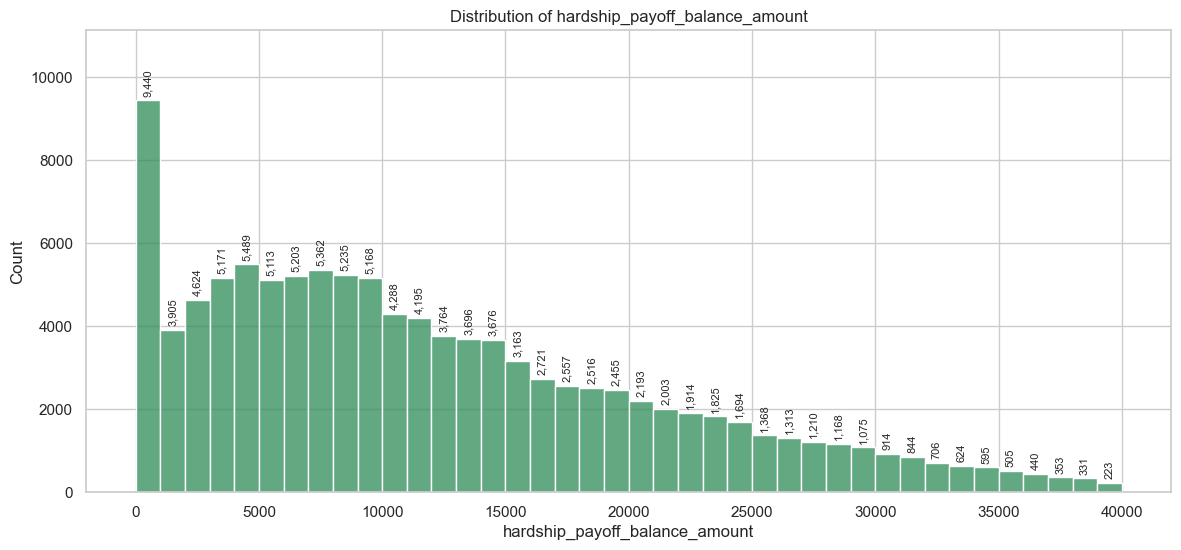

In [66]:
if 'hardship_payoff_balance_amount' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['hardship_payoff_balance_amount'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 40000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_payoff_balance_amount')
    plt.xlabel('hardship_payoff_balance_amount')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'hardship_payoff_balance_amount' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_reason

Describes the reason the hardship plan was offered.
<br>
하드십 플랜이 제공된 사유(소득 감소, 실직, 의료비, 자연재해 등).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

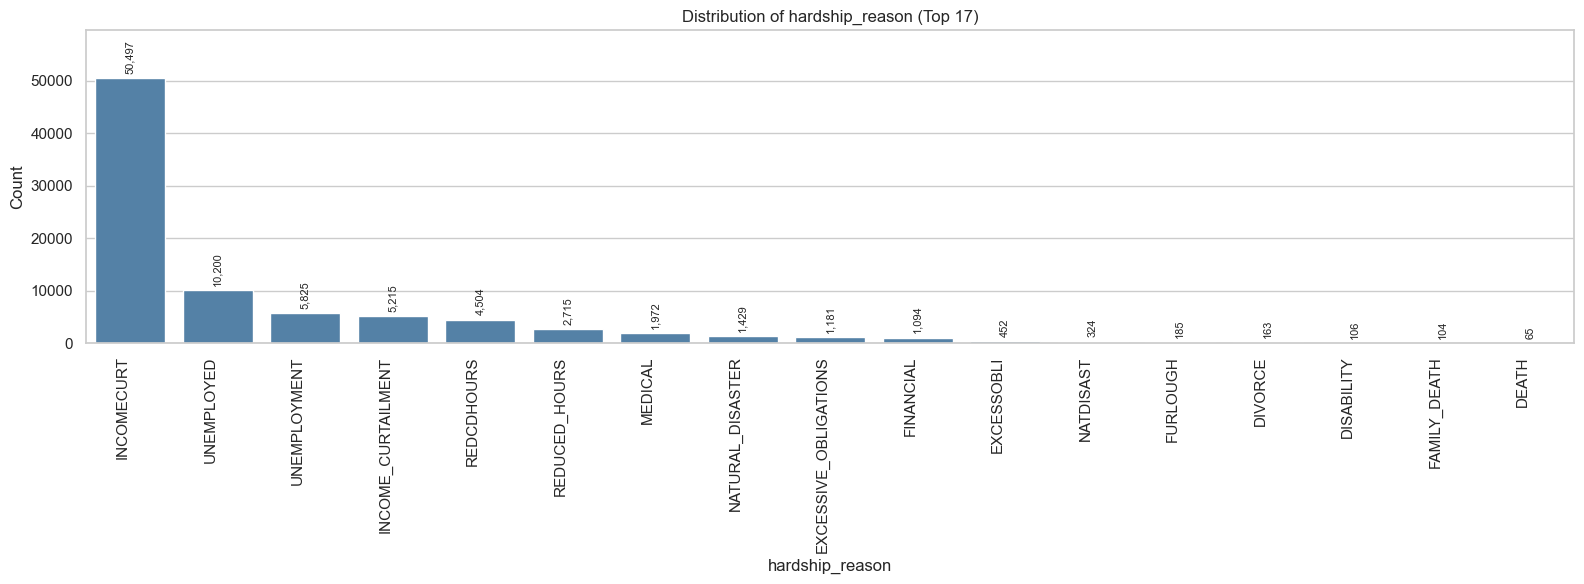

In [67]:
if 'hardship_reason' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 17개만 표시)
    order = lending_club['hardship_reason'].value_counts().index[:17]
    ax = sns.countplot(data=lending_club, x='hardship_reason', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_reason (Top 17)')
    plt.xlabel('hardship_reason')
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'hardship_reason' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_start_date

The start date of the hardship plan period.
<br>
하드십 플랜 시작 시점(월 단위). 2020년 4~5월에 집중 → COVID-19 영향.

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

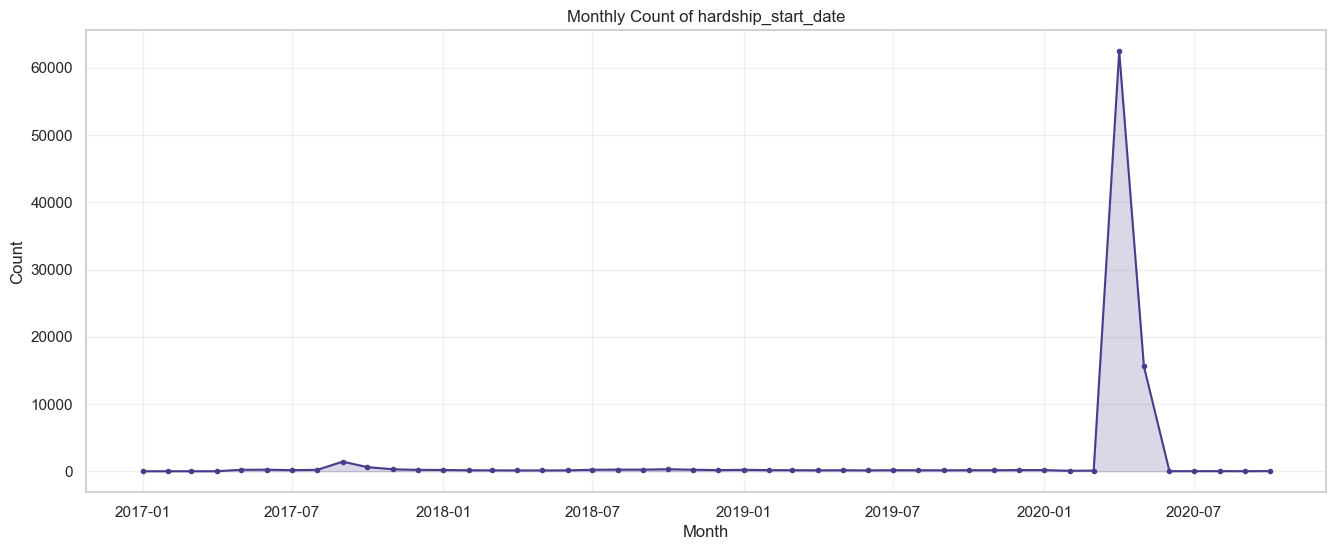

In [68]:
if 'hardship_start_date' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['hardship_start_date'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of hardship_start_date')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'hardship_start_date' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_status

Describes if the hardship plan is active, pending, canceled, completed, or broken.
<br>
하드십 플랜의 진행 상태(진행중/완료/파기 등).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

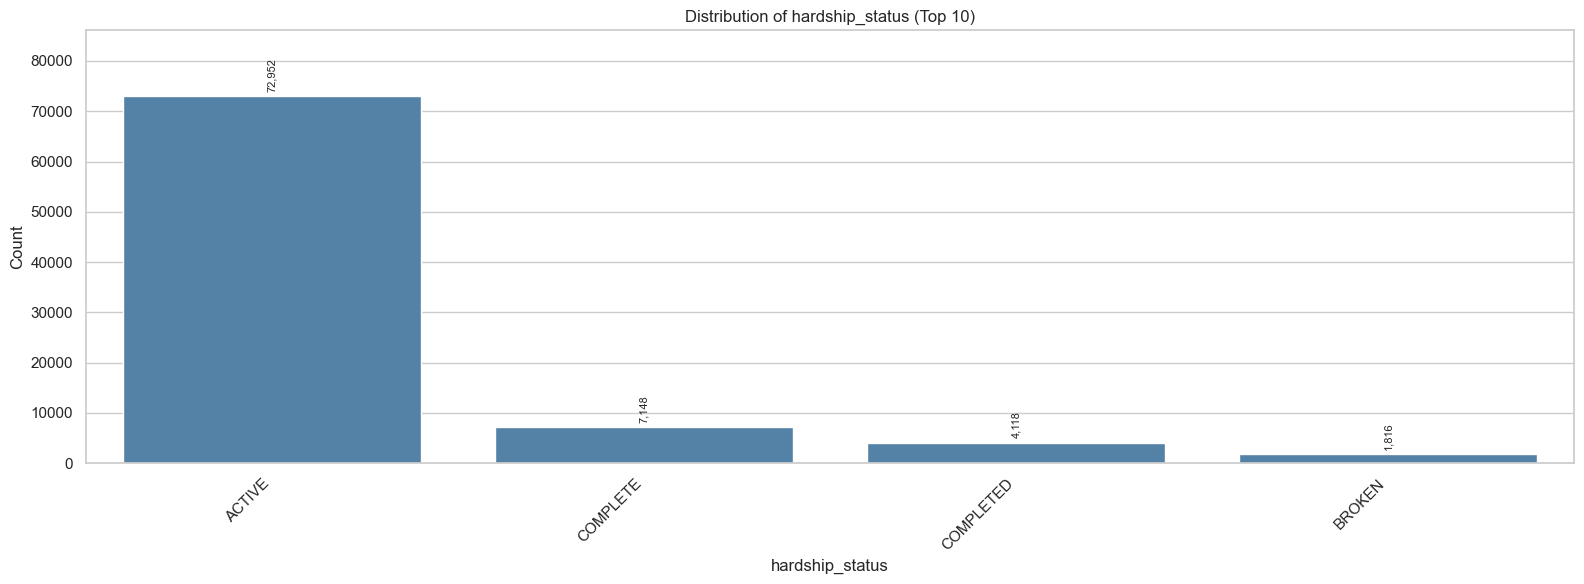

In [69]:
if 'hardship_status' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 10개만 표시)
    order = lending_club['hardship_status'].value_counts().index[:10]
    ax = sns.countplot(data=lending_club, x='hardship_status', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_status (Top 10)')
    plt.xlabel('hardship_status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'hardship_status' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### hardship_type

Describes the hardship plan offering.
<br>
제공된 하드십 플랜의 종류(예: COVID-19 스킵 결제, 3개월 이자만 납부 등).

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

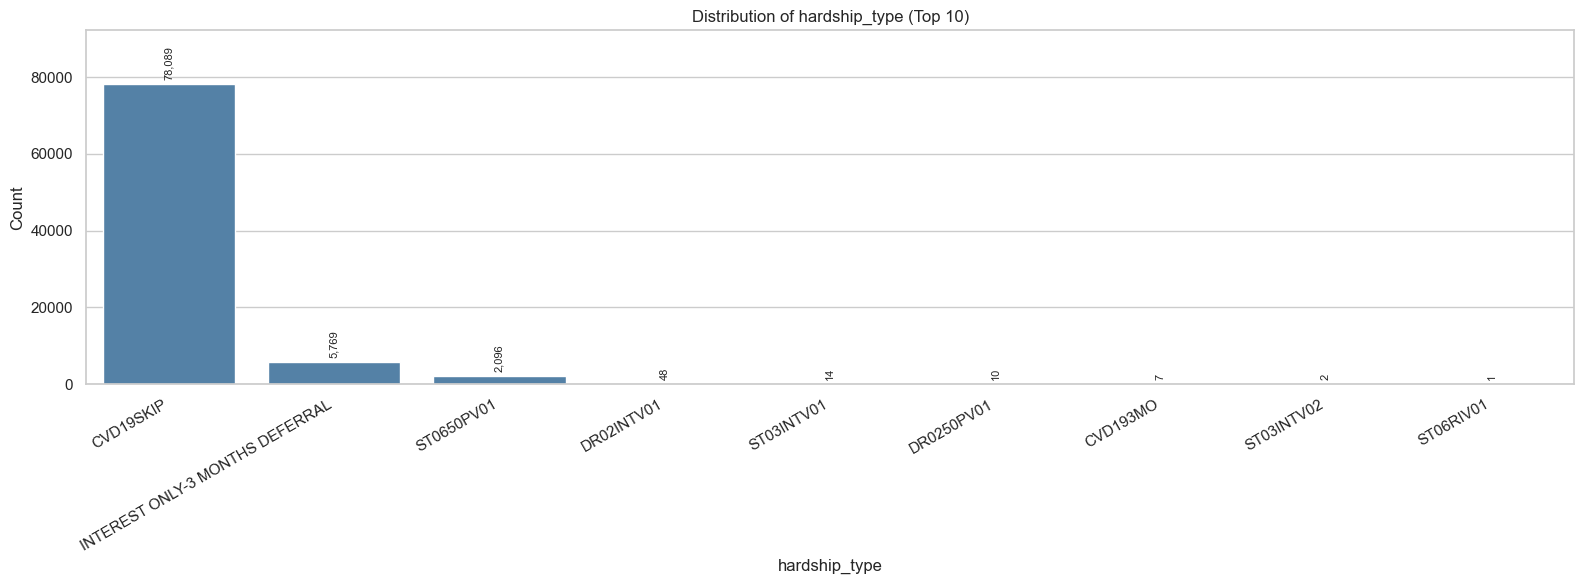

In [70]:
if 'hardship_type' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 빈도가 높은 순서로 정렬 (상위 10개만 표시)
    order = lending_club['hardship_type'].value_counts().index[:10]
    ax = sns.countplot(data=lending_club, x='hardship_type', order=order, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of hardship_type (Top 10)')
    plt.xlabel('hardship_type')
    plt.ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.margins(y=0.18)
    plt.tight_layout()
    plt.show()
else:
    print("'hardship_type' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### last_credit_pull_d

The most recent month LC pulled credit for this loan.
<br>
LC가 해당 대출에 대해 마지막으로 신용 조회를 실시한 연월.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

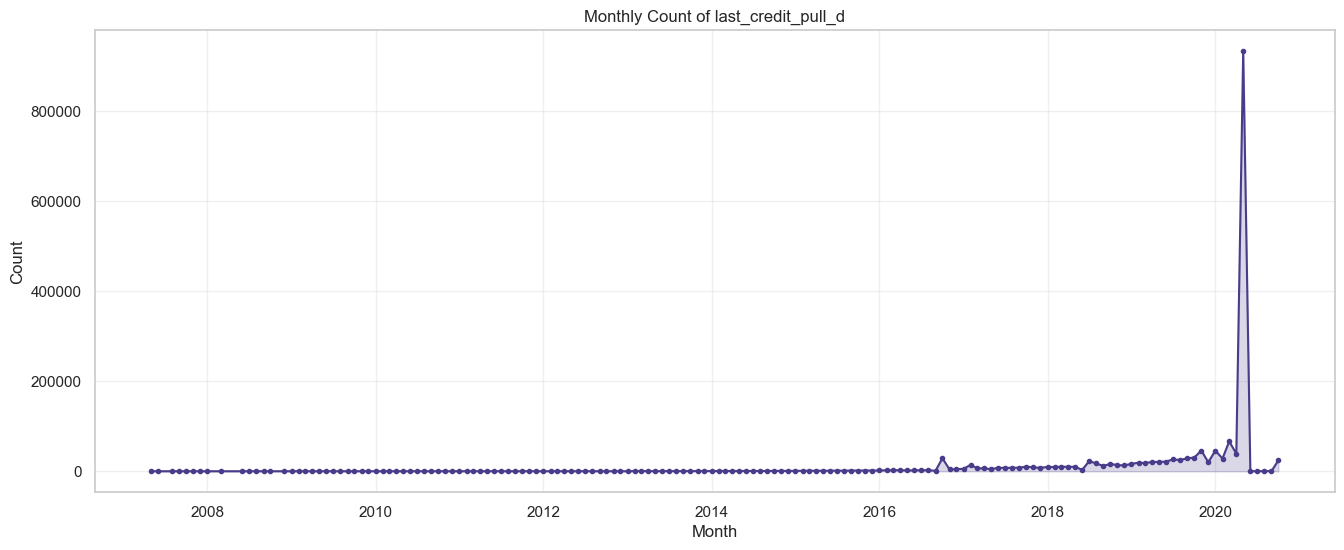

In [71]:
if 'last_credit_pull_d' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['last_credit_pull_d'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of last_credit_pull_d')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'last_credit_pull_d' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### last_fico_range_high

The upper boundary range the borrower's last FICO pulled belongs to.
<br>
가장 최근 조회된 FICO 점수 구간의 상한값. 0값은 조회 불가/무효를 의미.

<br>

% 0 등 무효값을 제외하기 위해 300 이상 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

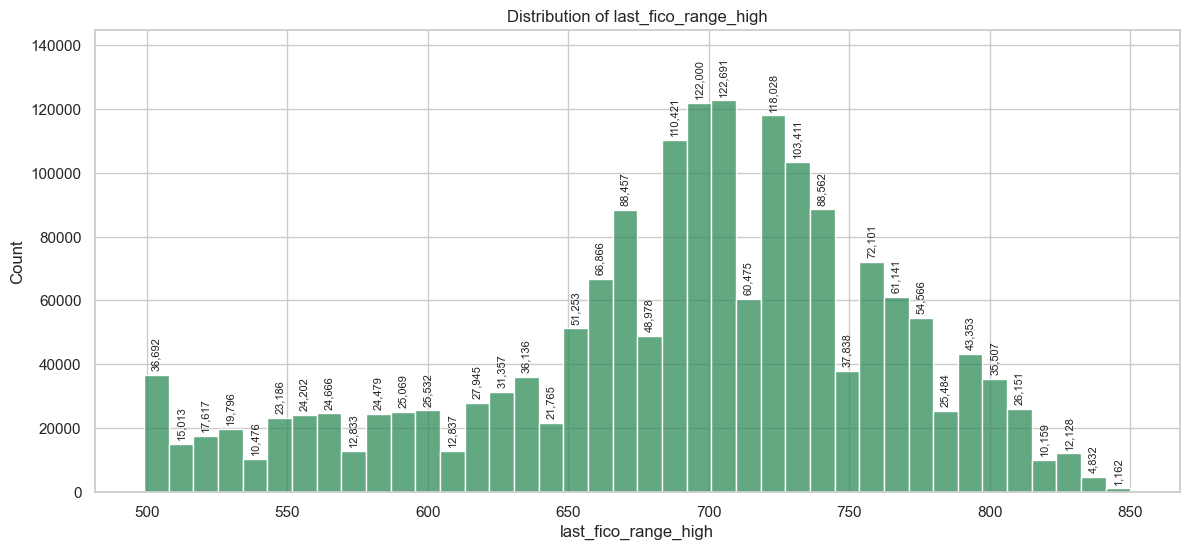

In [72]:
if 'last_fico_range_high' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['last_fico_range_high'].dropna()
    data_to_plot = data_to_plot[data_to_plot >= 300]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of last_fico_range_high')
    plt.xlabel('last_fico_range_high')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'last_fico_range_high' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### last_fico_range_low

The lower boundary range the borrower's last FICO pulled belongs to.
<br>
가장 최근 조회된 FICO 점수 구간의 하한값. 0값은 조회 불가/무효를 의미.

<br>

% 0 등 무효값을 제외하기 위해 300 이상 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

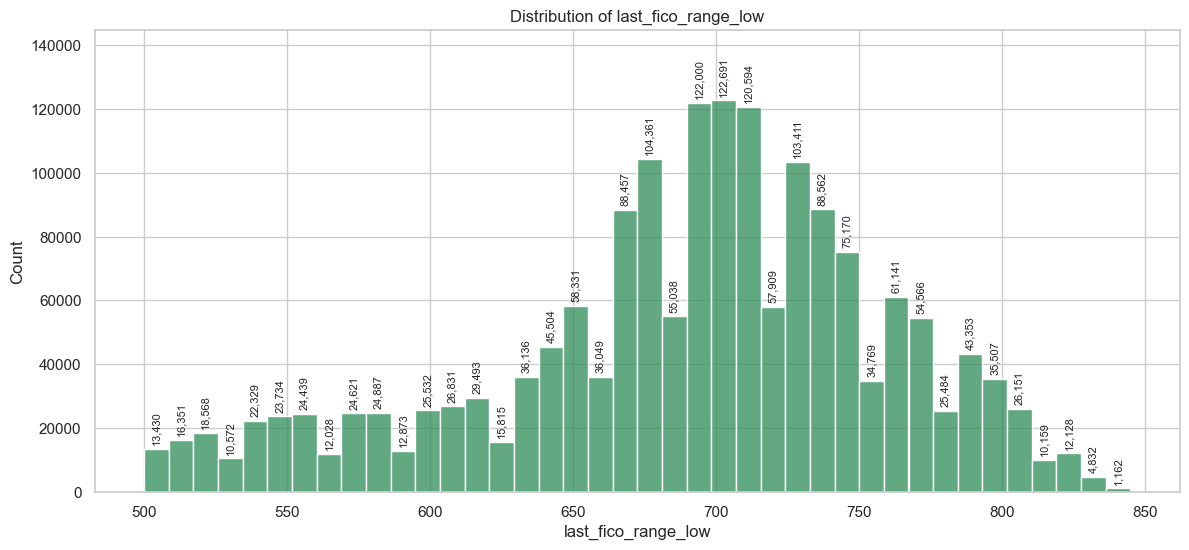

In [73]:
if 'last_fico_range_low' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['last_fico_range_low'].dropna()
    data_to_plot = data_to_plot[data_to_plot >= 300]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of last_fico_range_low')
    plt.xlabel('last_fico_range_low')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'last_fico_range_low' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### last_pymnt_amnt

Last total payment amount received.
<br>
마지막으로 수령한 납입 총액. 조기 완납 시 큰 값이 찍힘.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 20,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

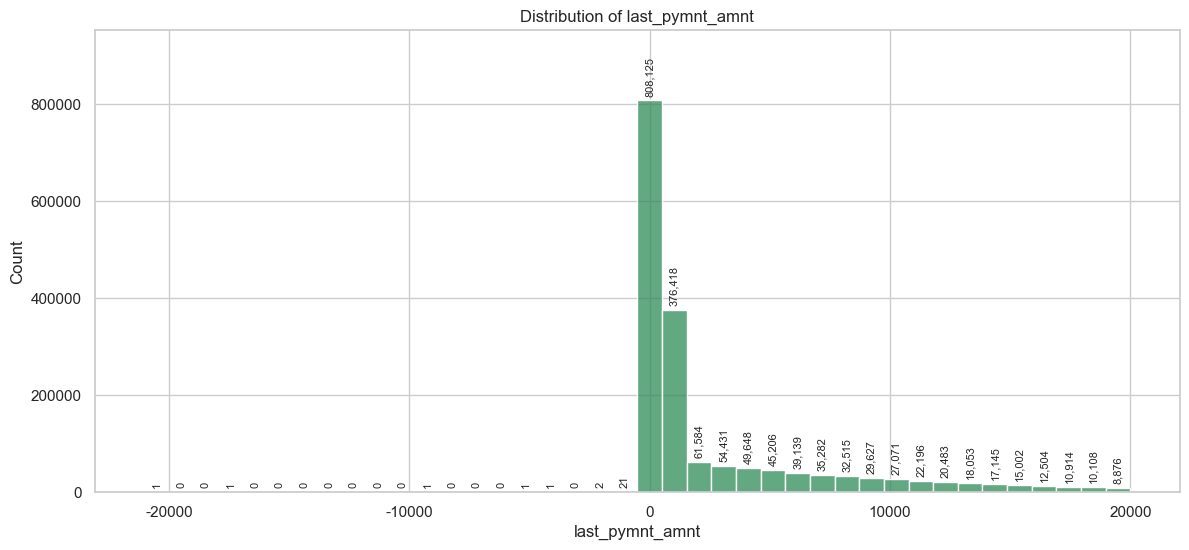

In [74]:
if 'last_pymnt_amnt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['last_pymnt_amnt'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of last_pymnt_amnt')
    plt.xlabel('last_pymnt_amnt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'last_pymnt_amnt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### last_pymnt_d

Last month payment was received.
<br>
마지막 납입이 이루어진 연월.

<br>

% 결측치 **0.17%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

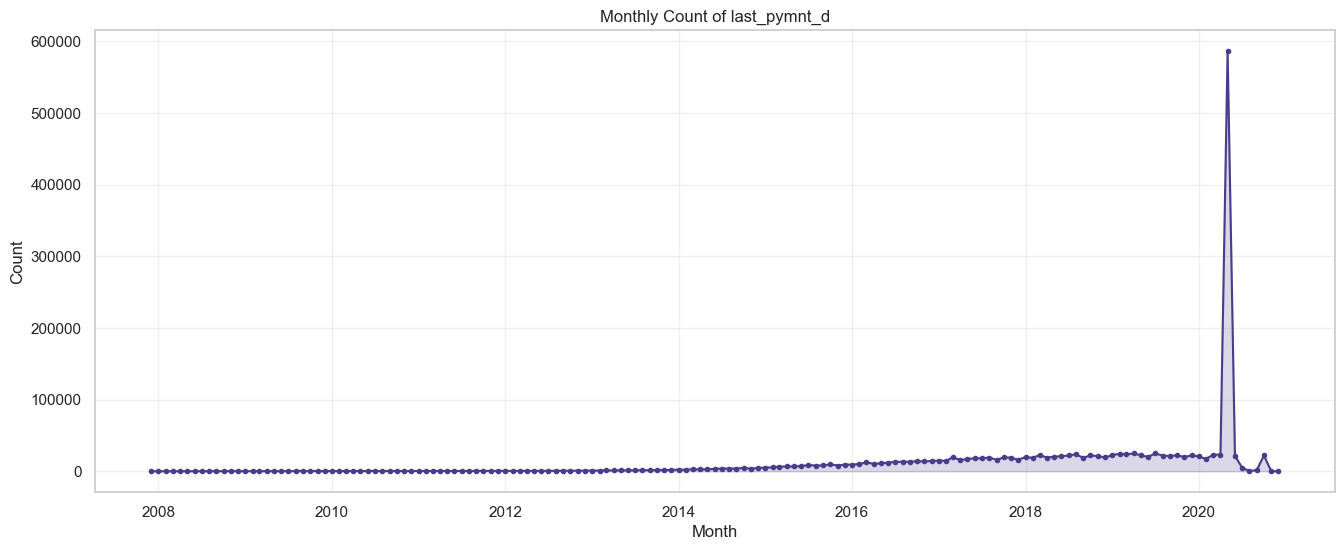

In [75]:
if 'last_pymnt_d' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['last_pymnt_d'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of last_pymnt_d')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'last_pymnt_d' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### max_bal_bc

Maximum current balance owed on all revolving accounts.
<br>
모든 리볼빙(신용카드) 계좌 중 최대 현재 잔액.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 40,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

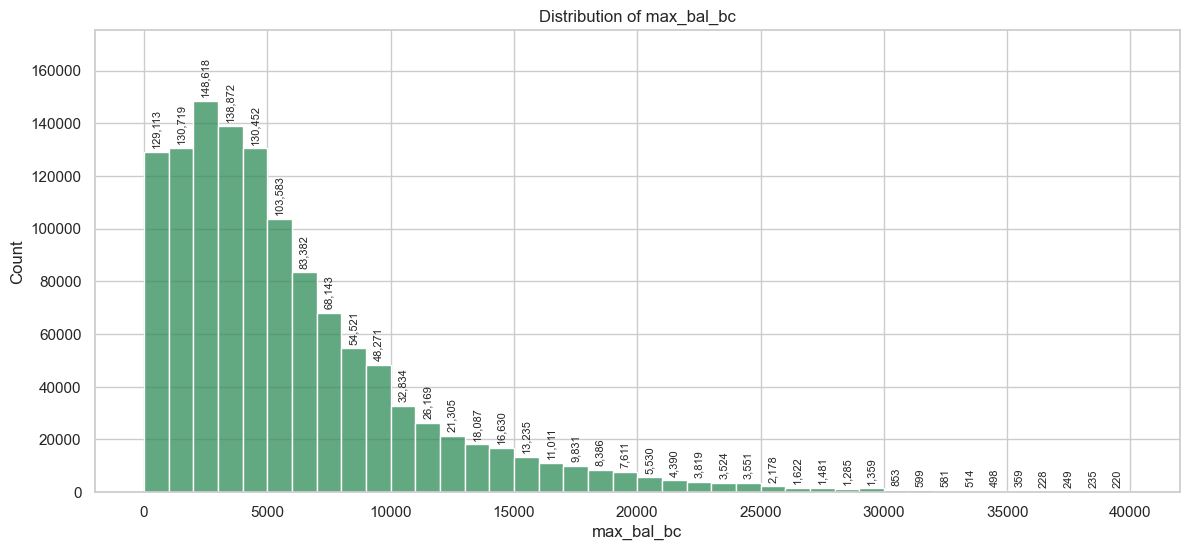

In [76]:
if 'max_bal_bc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['max_bal_bc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 40000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of max_bal_bc')
    plt.xlabel('max_bal_bc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'max_bal_bc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mo_sin_old_il_acct

Months since oldest bank installment account opened.
<br>
가장 오래된 할부(installment) 계좌 개설 후 경과 개월 수. 신용 이력 길이 지표.

<br>

% 결측치 **5.19%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 400 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

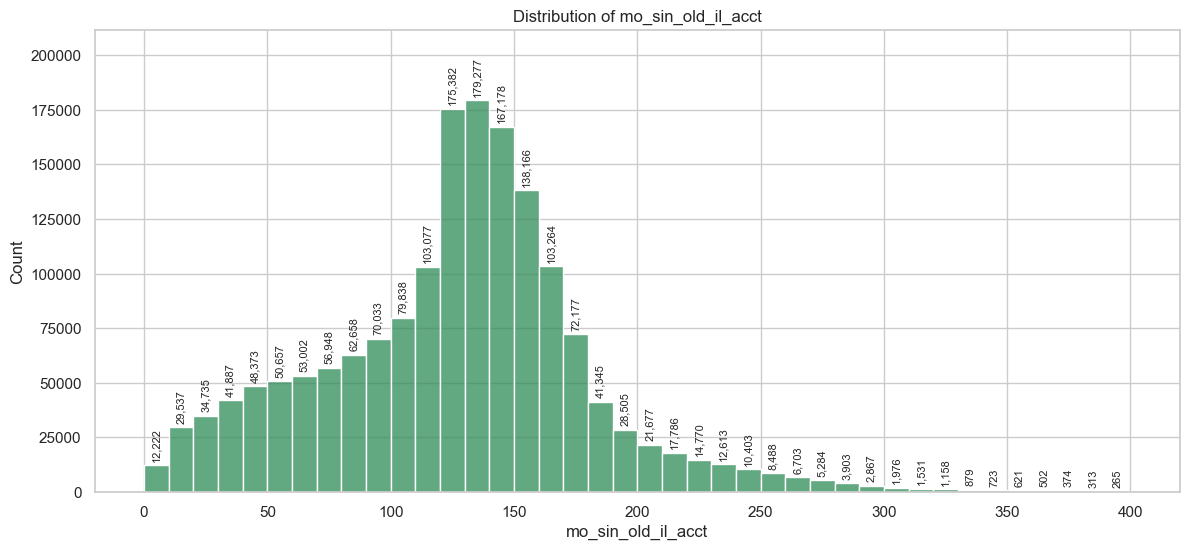

In [77]:
if 'mo_sin_old_il_acct' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mo_sin_old_il_acct'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 400]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mo_sin_old_il_acct')
    plt.xlabel('mo_sin_old_il_acct')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mo_sin_old_il_acct' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mo_sin_old_rev_tl_op

Months since oldest revolving account opened.
<br>
가장 오래된 리볼빙 계좌 개설 후 경과 개월 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 500 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

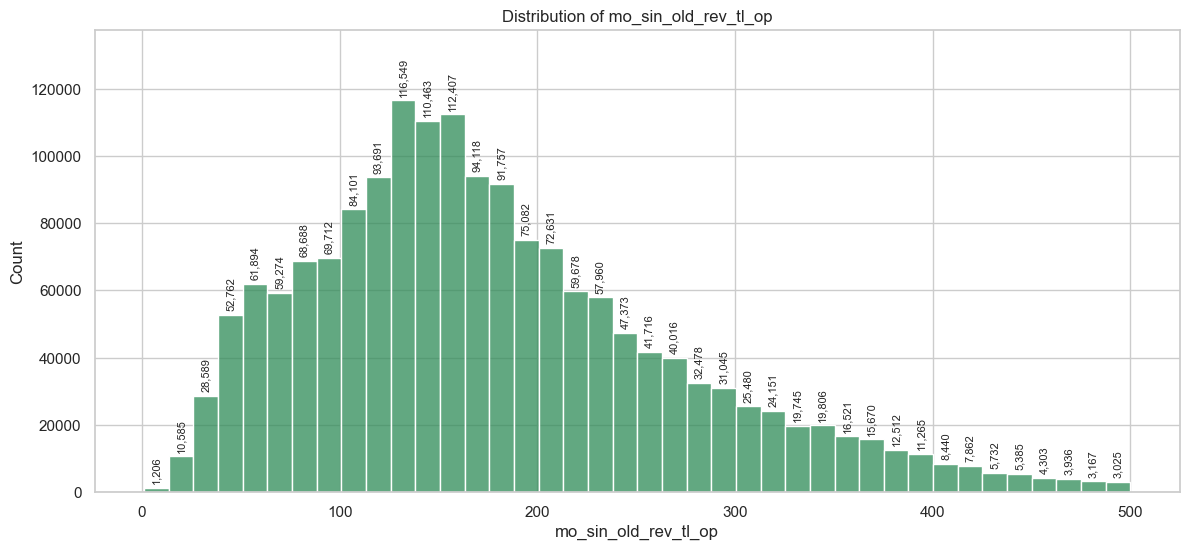

In [78]:
if 'mo_sin_old_rev_tl_op' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mo_sin_old_rev_tl_op'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 500]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mo_sin_old_rev_tl_op')
    plt.xlabel('mo_sin_old_rev_tl_op')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mo_sin_old_rev_tl_op' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mo_sin_rcnt_rev_tl_op

Months since most recent revolving account opened.
<br>
가장 최근 리볼빙 계좌 개설 후 경과 개월 수. 값이 작을수록 최근에 신용을 늘림.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 100 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

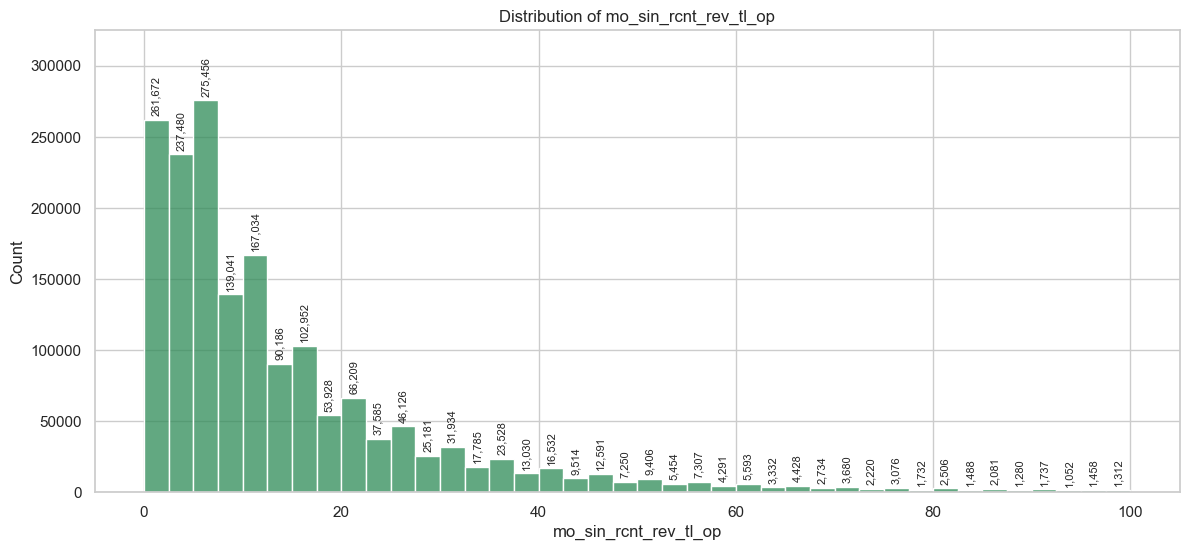

In [79]:
if 'mo_sin_rcnt_rev_tl_op' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mo_sin_rcnt_rev_tl_op'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 100]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mo_sin_rcnt_rev_tl_op')
    plt.xlabel('mo_sin_rcnt_rev_tl_op')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mo_sin_rcnt_rev_tl_op' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mo_sin_rcnt_tl

Months since most recent account opened.
<br>
가장 최근 계좌(종류 무관) 개설 후 경과 개월 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 60 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

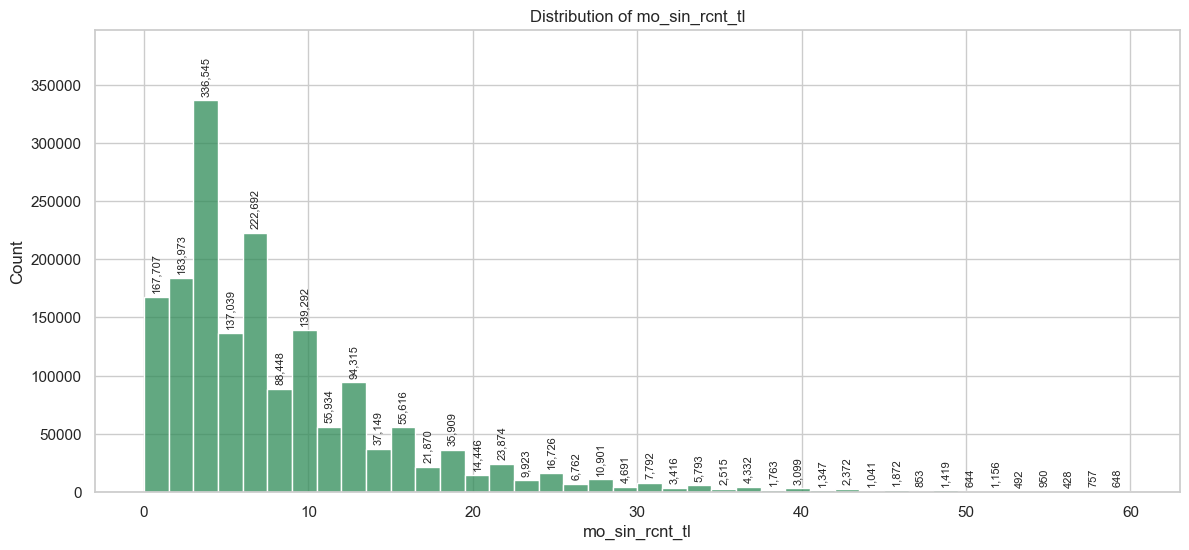

In [80]:
if 'mo_sin_rcnt_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mo_sin_rcnt_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 60]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mo_sin_rcnt_tl')
    plt.xlabel('mo_sin_rcnt_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mo_sin_rcnt_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mort_acc

Number of mortgage accounts.
<br>
보유 주택담보대출 계좌 수. 자산 보유의 대리 변수(proxy).

<br>

% 결측치 **1.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

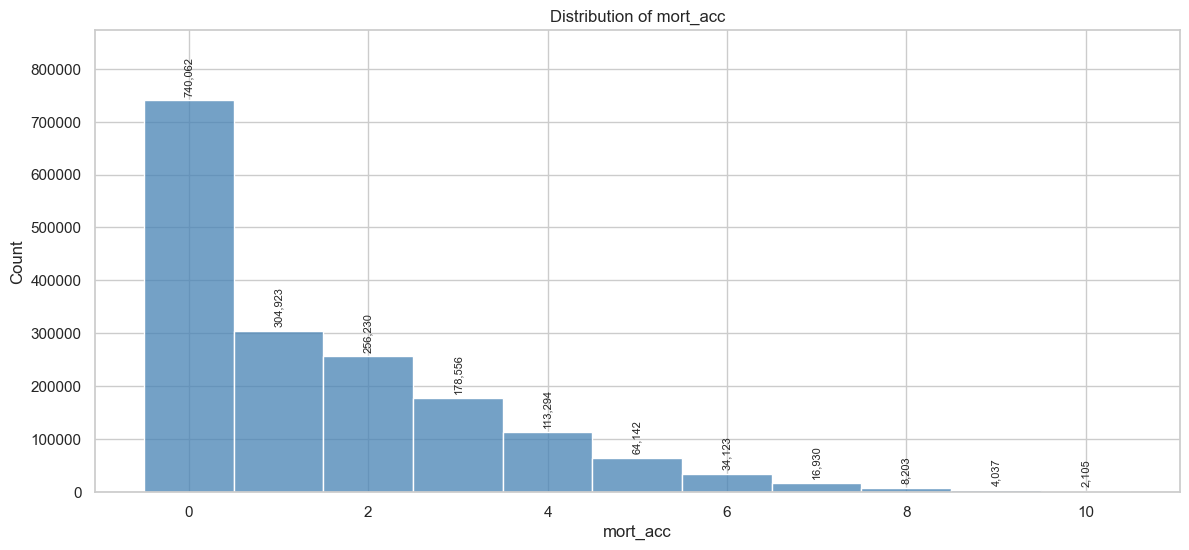

In [81]:
if 'mort_acc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mort_acc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mort_acc')
    plt.xlabel('mort_acc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mort_acc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_last_delinq

The number of months since the borrower's last delinquency.
<br>
마지막 연체 이후 경과 개월 수. **결측 = 연체 이력 없음**이므로 단순 평균 대치는 금물(더미 변수 필수).

<br>

% 결측치 **52.52%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 120 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

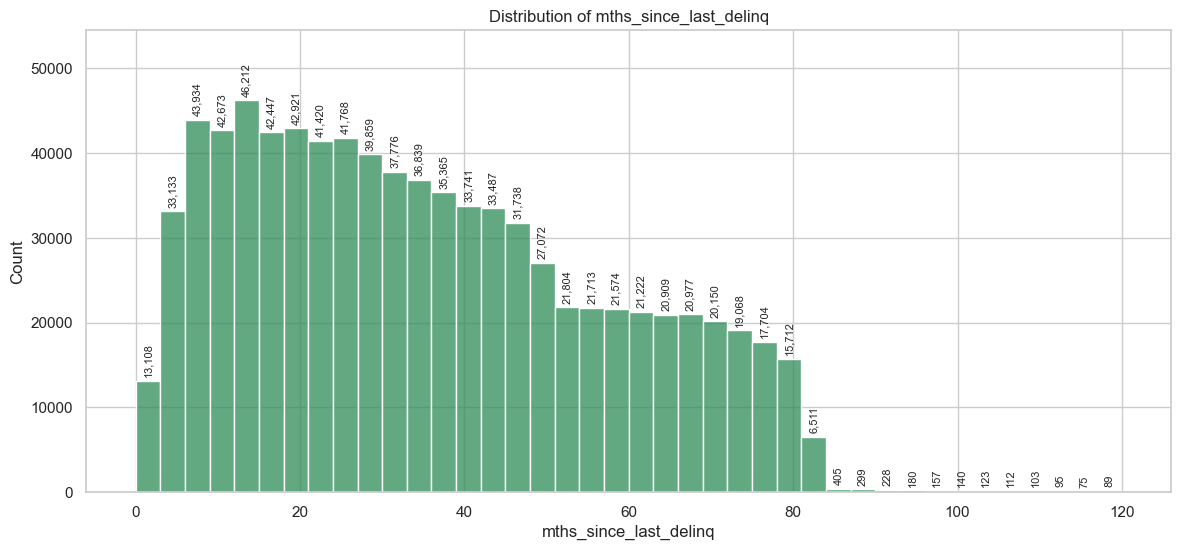

In [82]:
if 'mths_since_last_delinq' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_last_delinq'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 120]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_last_delinq')
    plt.xlabel('mths_since_last_delinq')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_last_delinq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_last_major_derog

Months since most recent 90-day or worse rating.
<br>
최근 90일 이상 심각 연체 이후 경과 개월 수. 결측은 해당 이력 없음.

<br>

% 결측치 **75.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 120 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

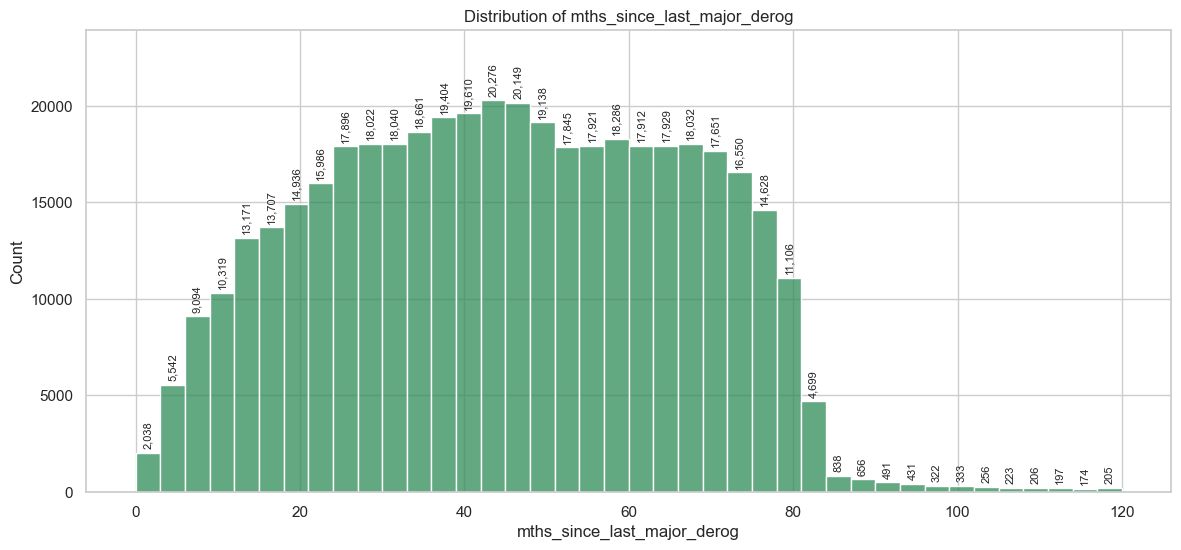

In [83]:
if 'mths_since_last_major_derog' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_last_major_derog'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 120]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_last_major_derog')
    plt.xlabel('mths_since_last_major_derog')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_last_major_derog' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_last_record

The number of months since the last public record.
<br>
마지막 공공기록(파산·세금유치권 등) 이후 경과 개월 수. 결측은 공공기록 없음.

<br>

% 결측치 **85.16%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 130 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

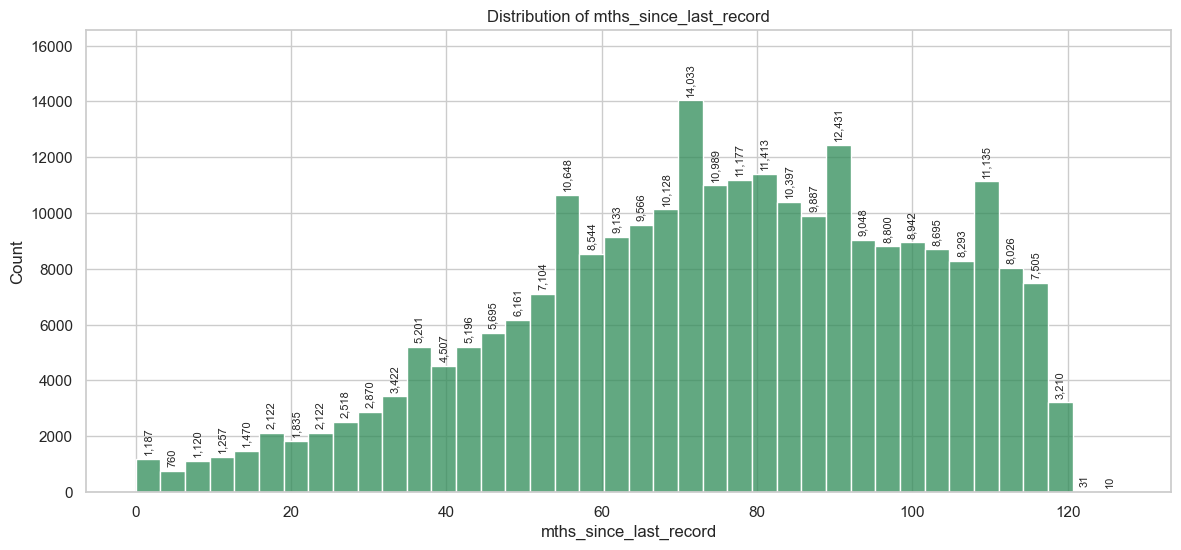

In [84]:
if 'mths_since_last_record' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_last_record'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 130]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_last_record')
    plt.xlabel('mths_since_last_record')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_last_record' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_rcnt_il

Months since most recent installment accounts opened.
<br>
가장 최근 할부 계좌 개설 후 경과 개월 수.

<br>

% 결측치 **31.66%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

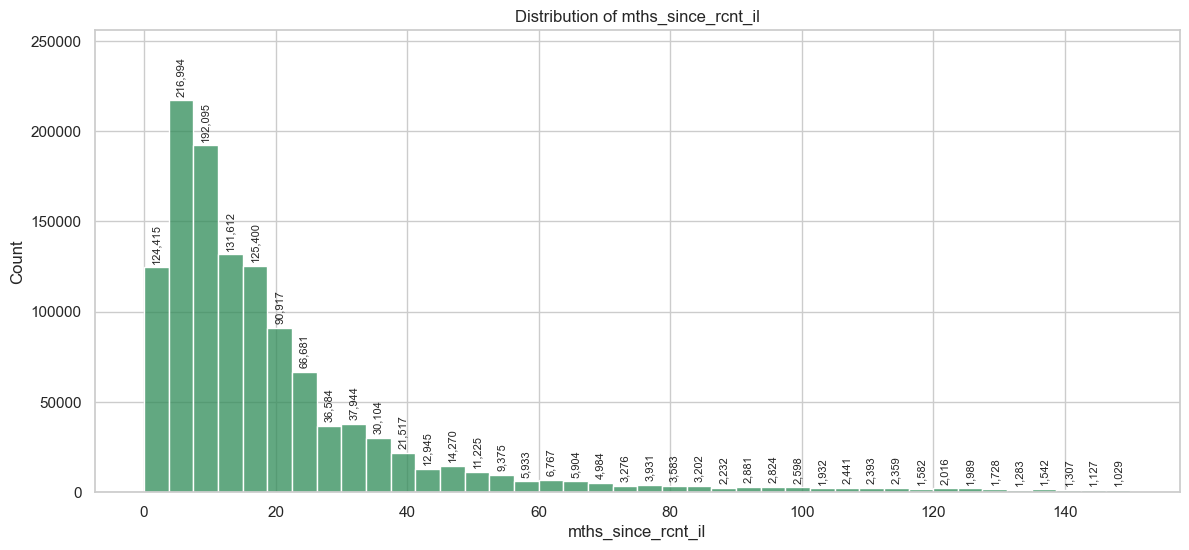

In [85]:
if 'mths_since_rcnt_il' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_rcnt_il'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_rcnt_il')
    plt.xlabel('mths_since_rcnt_il')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_rcnt_il' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_recent_bc

Months since most recent bankcard account opened.
<br>
가장 최근 은행 신용카드 계좌 개설 후 경과 개월 수.

<br>

% 결측치 **2.75%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 200 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

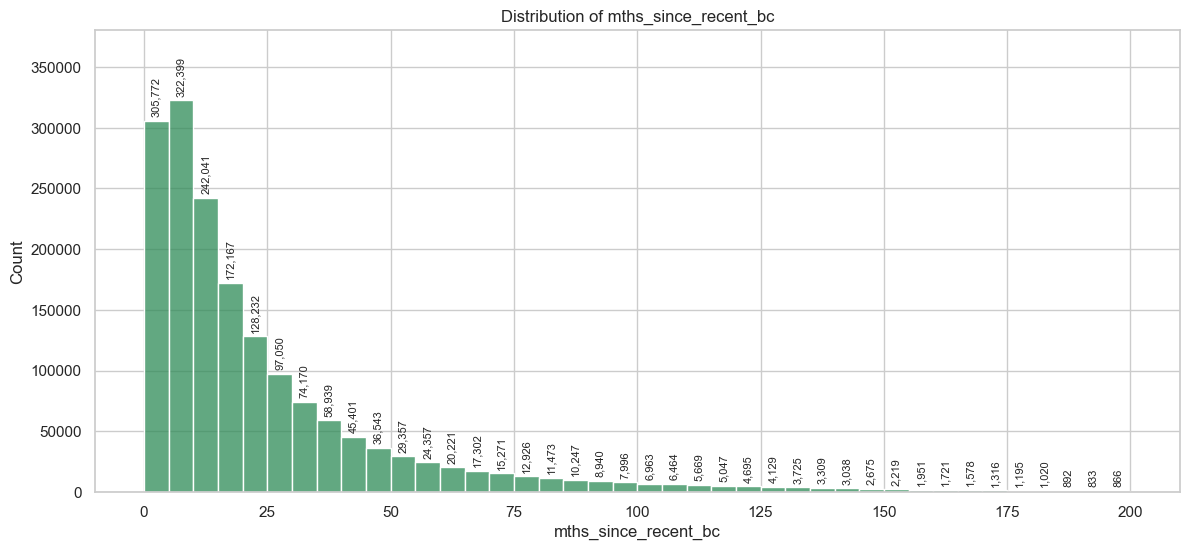

In [86]:
if 'mths_since_recent_bc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_recent_bc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 200]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_recent_bc')
    plt.xlabel('mths_since_recent_bc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_recent_bc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_recent_bc_dlq

Months since most recent bankcard delinquency.
<br>
가장 최근 신용카드 연체 이후 경과 개월 수. 결측은 카드 연체 이력 없음.

<br>

% 결측치 **77.8%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 120 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

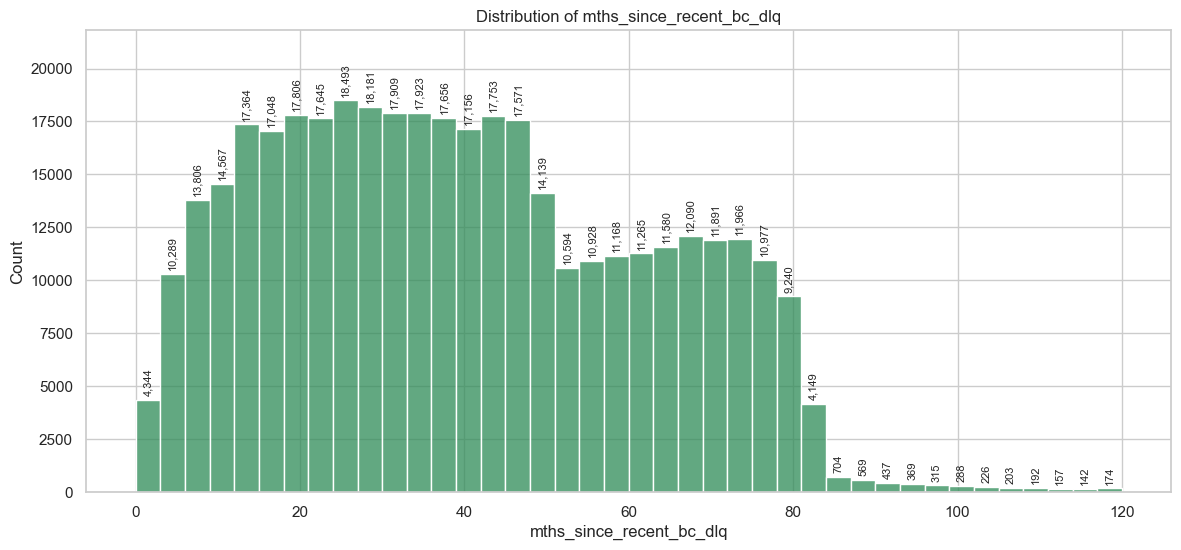

In [87]:
if 'mths_since_recent_bc_dlq' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_recent_bc_dlq'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 120]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_recent_bc_dlq')
    plt.xlabel('mths_since_recent_bc_dlq')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_recent_bc_dlq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_recent_inq

Months since most recent inquiry.
<br>
가장 최근 신용 조회 이후 경과 개월 수.

<br>

% 결측치 **12.7%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 25 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

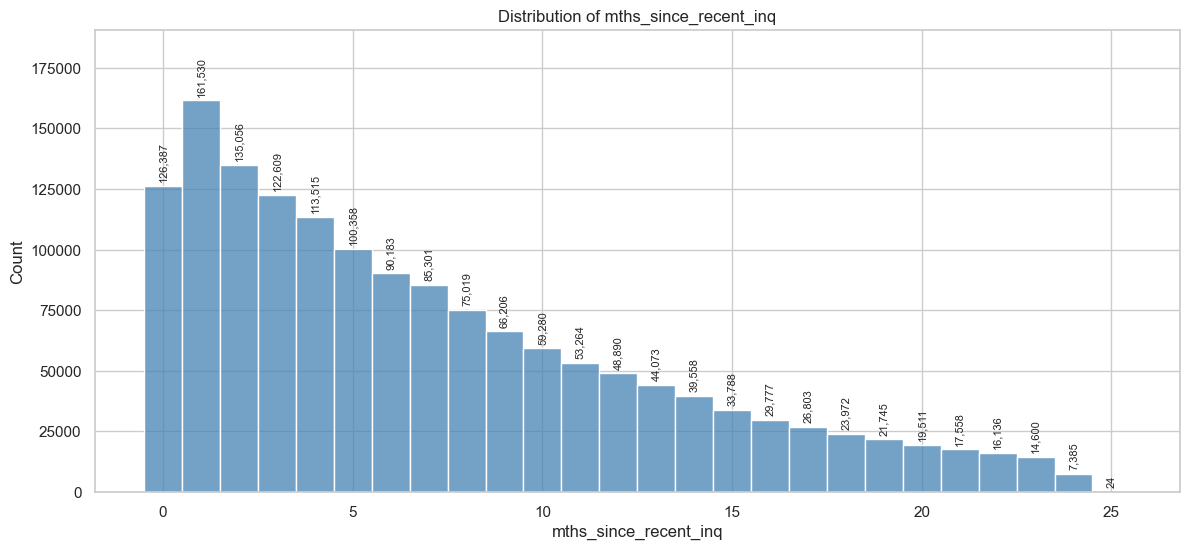

In [88]:
if 'mths_since_recent_inq' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_recent_inq'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 25]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_recent_inq')
    plt.xlabel('mths_since_recent_inq')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_recent_inq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### mths_since_recent_revol_delinq

Months since most recent revolving delinquency.
<br>
가장 최근 리볼빙 계좌 연체 이후 경과 개월 수. 결측은 이력 없음.

<br>

% 결측치 **68.19%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 120 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

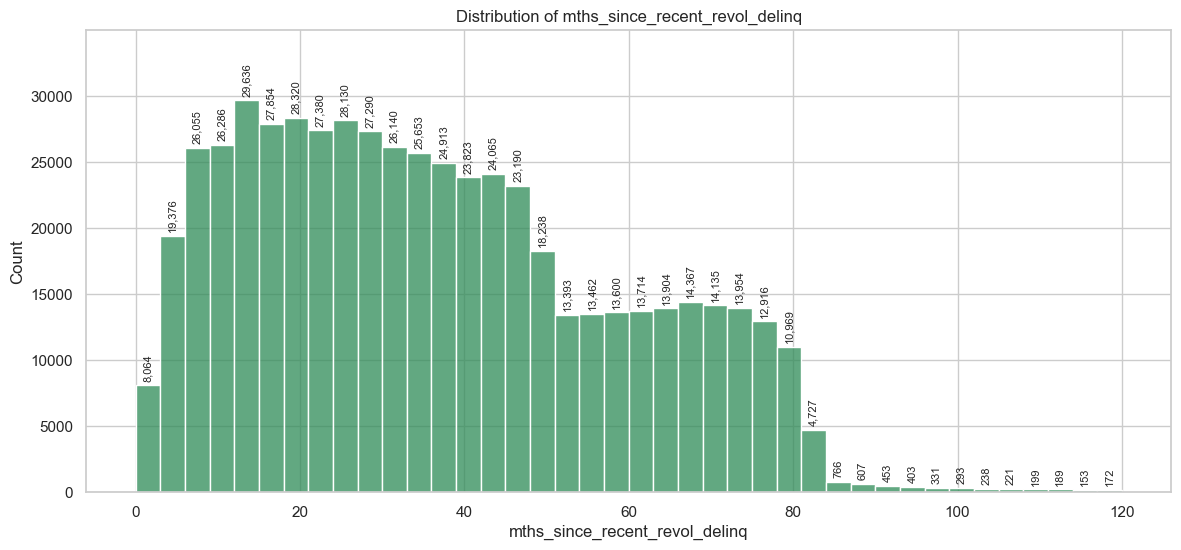

In [89]:
if 'mths_since_recent_revol_delinq' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['mths_since_recent_revol_delinq'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 120]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of mths_since_recent_revol_delinq')
    plt.xlabel('mths_since_recent_revol_delinq')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'mths_since_recent_revol_delinq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### next_pymnt_d

Next scheduled payment date.
<br>
다음 예정 납입일. 값이 존재한다는 것 자체가 '아직 진행 중인 대출'임을 의미.

<br>

% 결측치 **63.59%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

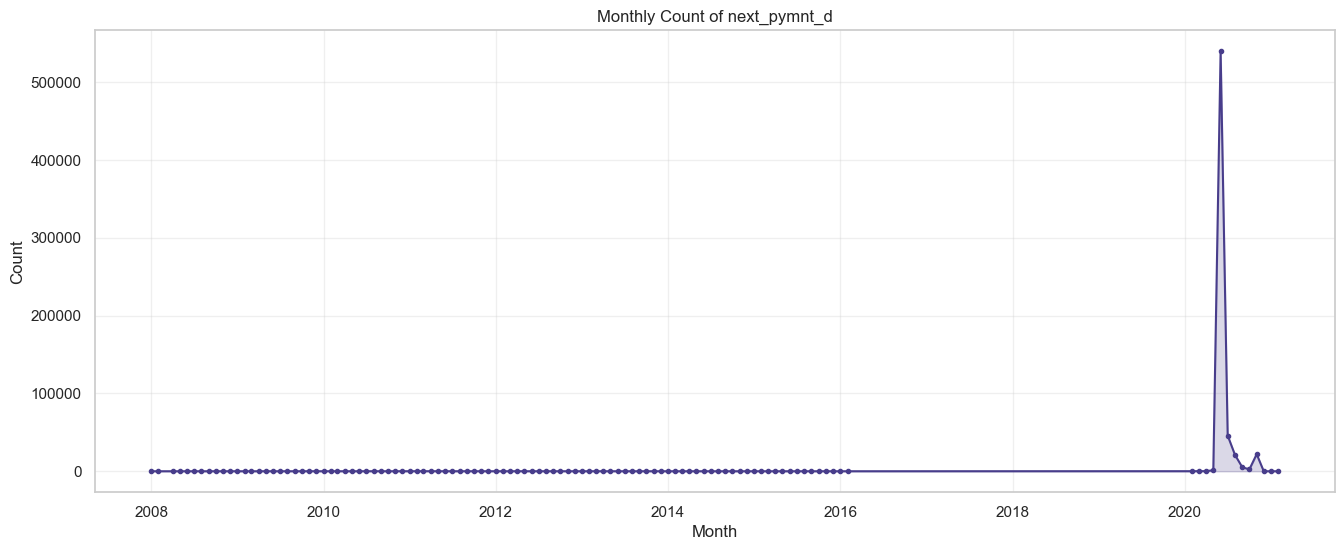

In [90]:
if 'next_pymnt_d' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['next_pymnt_d'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of next_pymnt_d')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'next_pymnt_d' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_accts_ever_120_pd

Number of accounts ever 120 or more days past due.
<br>
120일 이상 연체된 적이 있는 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

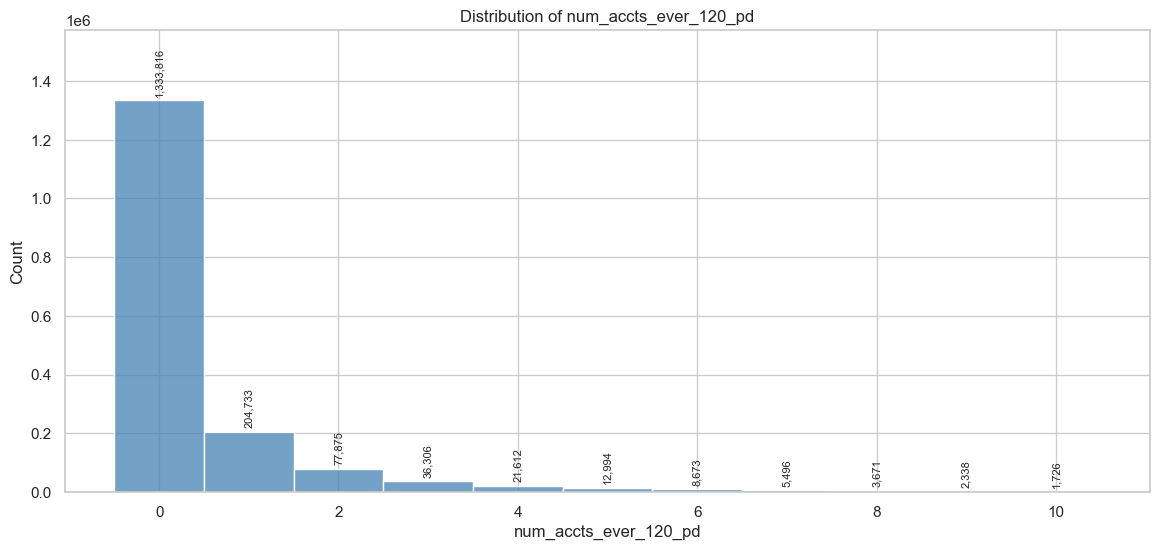

In [91]:
if 'num_accts_ever_120_pd' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_accts_ever_120_pd'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_accts_ever_120_pd')
    plt.xlabel('num_accts_ever_120_pd')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_accts_ever_120_pd' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_actv_bc_tl

Number of currently active bankcard accounts.
<br>
현재 활성 상태인 은행 신용카드 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 15 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

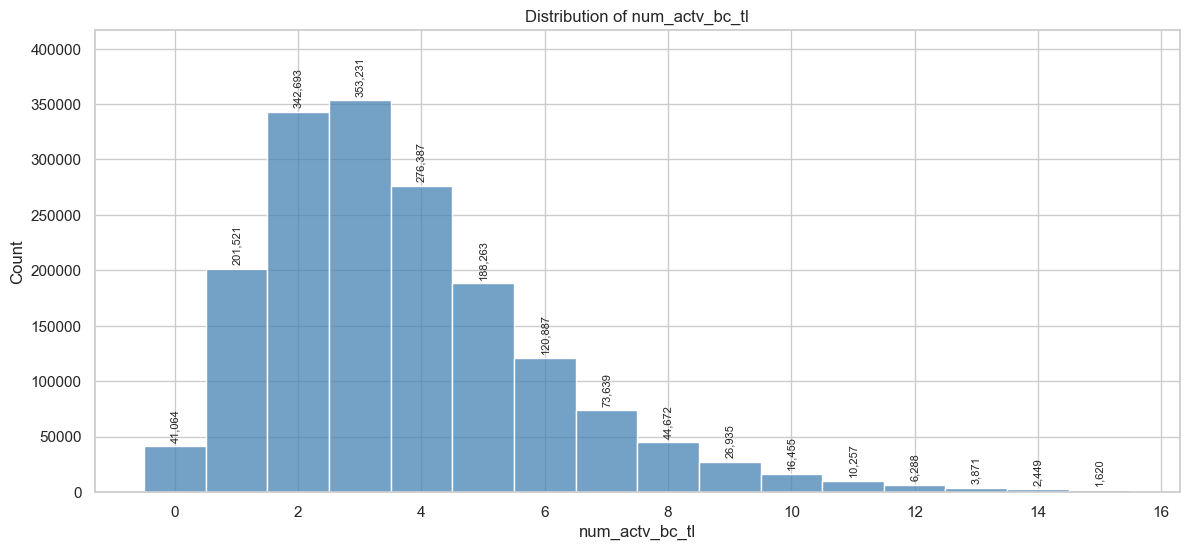

In [92]:
if 'num_actv_bc_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_actv_bc_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 15]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_actv_bc_tl')
    plt.xlabel('num_actv_bc_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_actv_bc_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_actv_rev_tl

Number of currently active revolving trades.
<br>
현재 활성 상태인 리볼빙 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

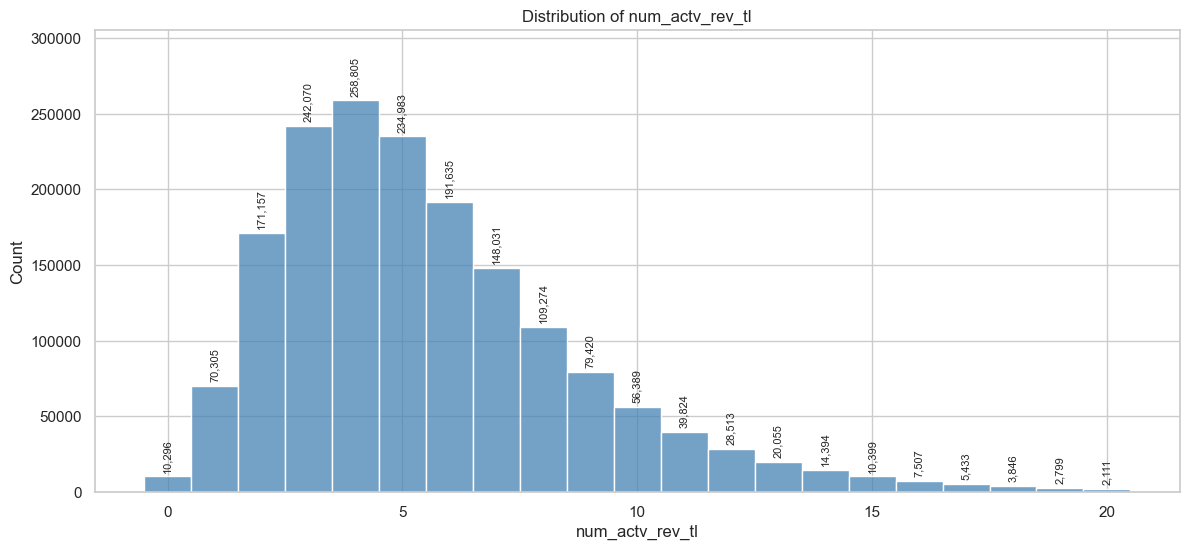

In [93]:
if 'num_actv_rev_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_actv_rev_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_actv_rev_tl')
    plt.xlabel('num_actv_rev_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_actv_rev_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_bc_sats

Number of satisfactory bankcard accounts.
<br>
연체 없이 정상 관리되고 있는 은행 신용카드 계좌 수.

<br>

% 결측치 **1.97%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

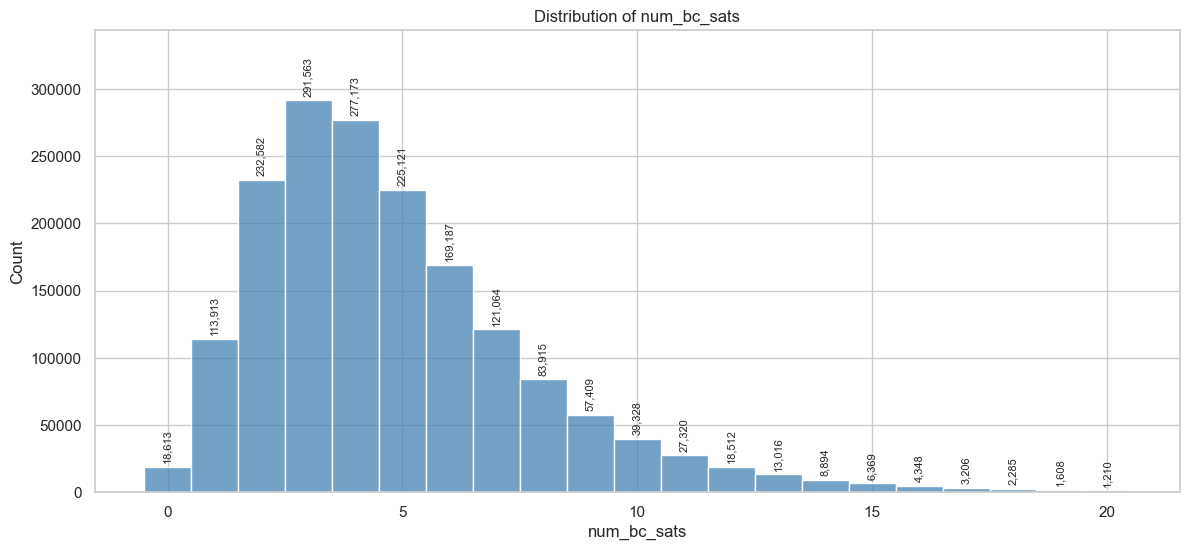

In [94]:
if 'num_bc_sats' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_bc_sats'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_bc_sats')
    plt.xlabel('num_bc_sats')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_bc_sats' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_bc_tl

Number of bankcard accounts.
<br>
보유한 전체 은행 신용카드 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 30 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

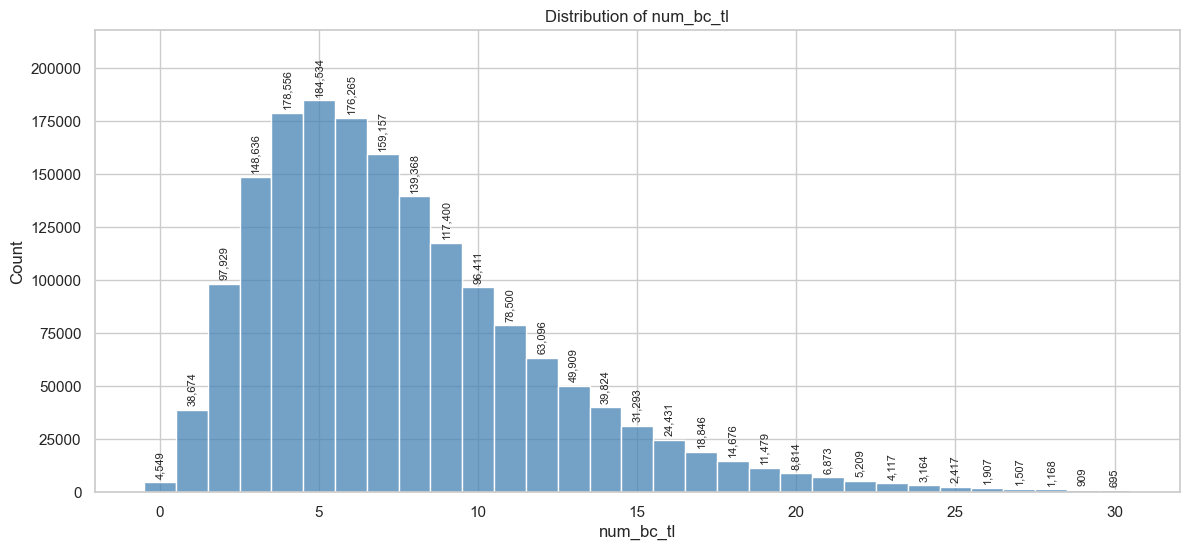

In [95]:
if 'num_bc_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_bc_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 30]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_bc_tl')
    plt.xlabel('num_bc_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_bc_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_il_tl

Number of installment accounts.
<br>
보유한 할부(installment) 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 40 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

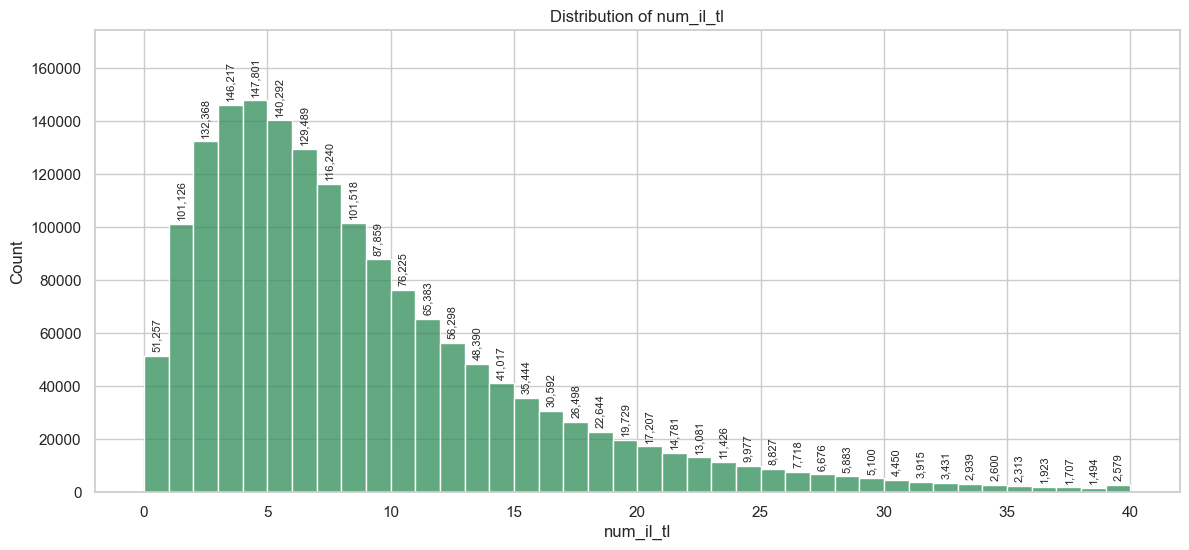

In [96]:
if 'num_il_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_il_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 40]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_il_tl')
    plt.xlabel('num_il_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_il_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_op_rev_tl

Number of open revolving accounts.
<br>
현재 개설(open) 상태인 리볼빙 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 30 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

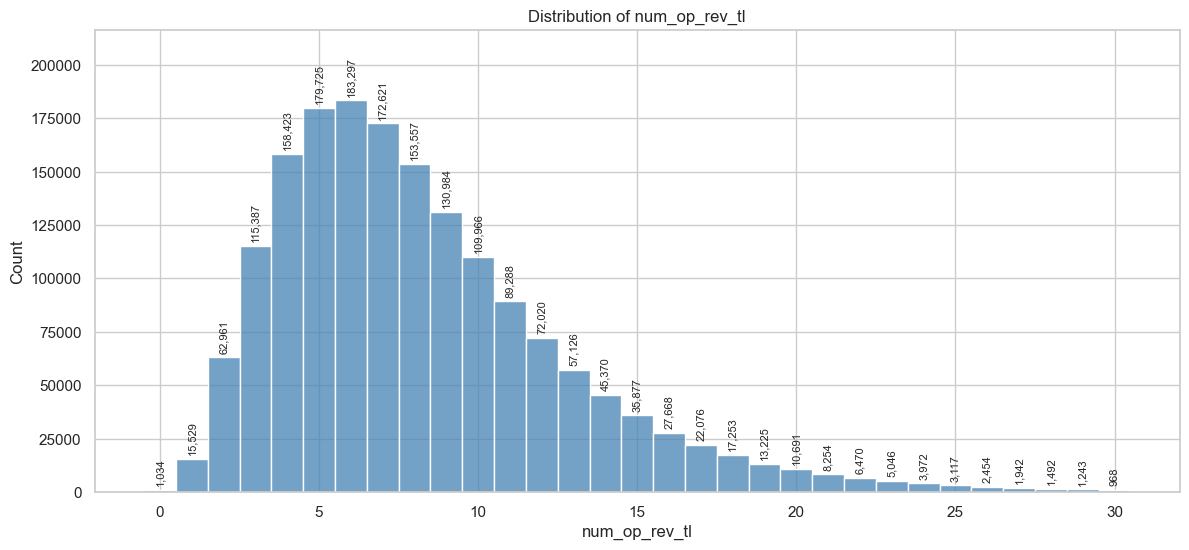

In [97]:
if 'num_op_rev_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_op_rev_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 30]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_op_rev_tl')
    plt.xlabel('num_op_rev_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_op_rev_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_rev_accts

Number of revolving accounts.
<br>
보유한 전체 리볼빙 계좌 수(폐쇄 포함).

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 50 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

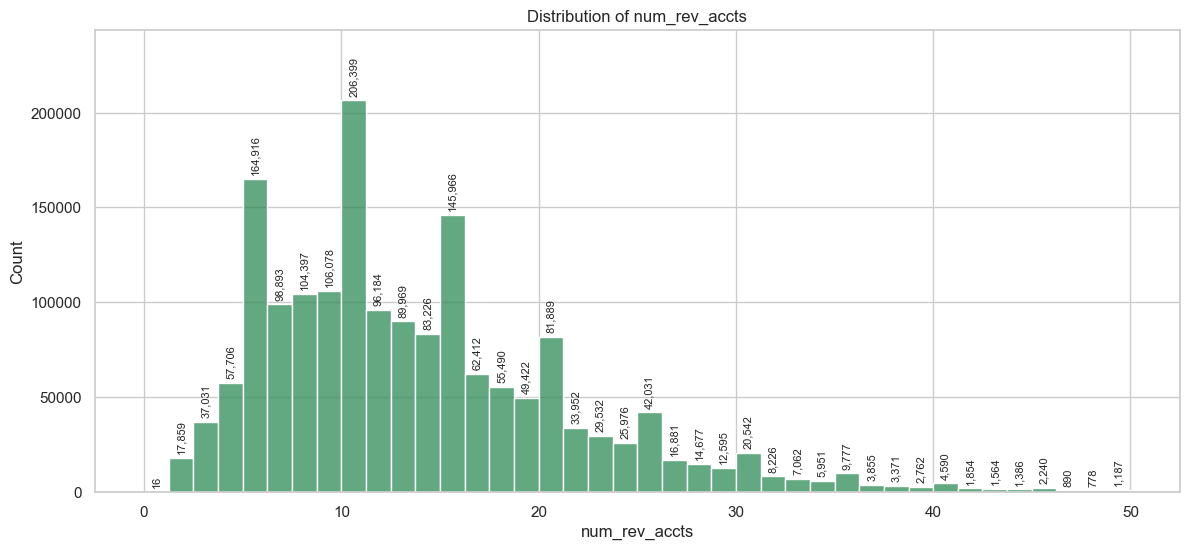

In [98]:
if 'num_rev_accts' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_rev_accts'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 50]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_rev_accts')
    plt.xlabel('num_rev_accts')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_rev_accts' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_rev_tl_bal_gt_0

Number of revolving trades with balance > 0.
<br>
잔액이 남아 있는 리볼빙 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

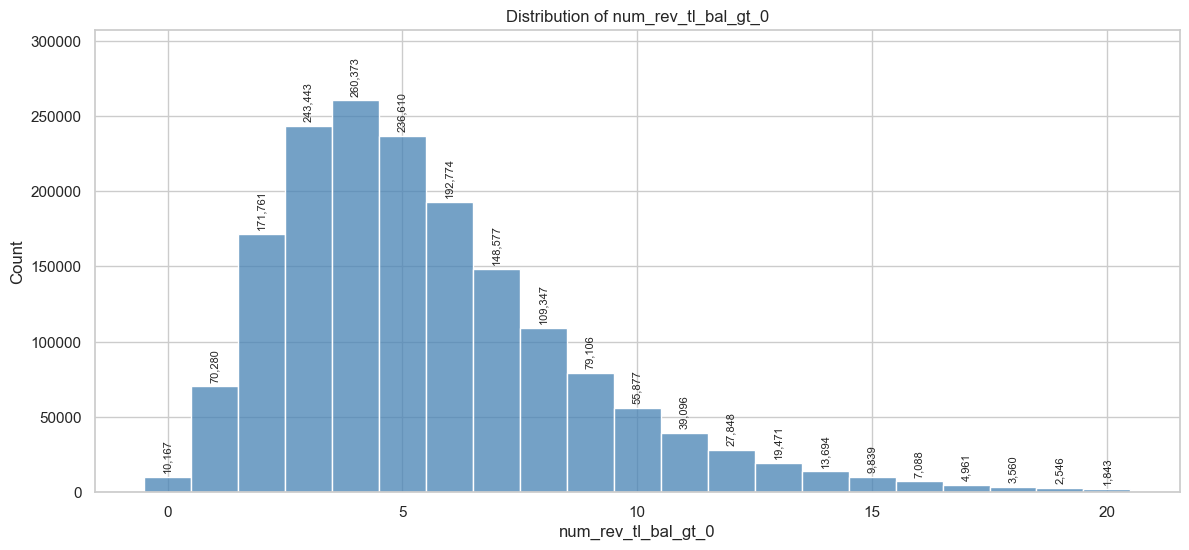

In [99]:
if 'num_rev_tl_bal_gt_0' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_rev_tl_bal_gt_0'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_rev_tl_bal_gt_0')
    plt.xlabel('num_rev_tl_bal_gt_0')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_rev_tl_bal_gt_0' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_sats

Number of satisfactory accounts.
<br>
연체 없이 정상 관리 중인 전체 계좌 수.

<br>

% 결측치 **1.97%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 30 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

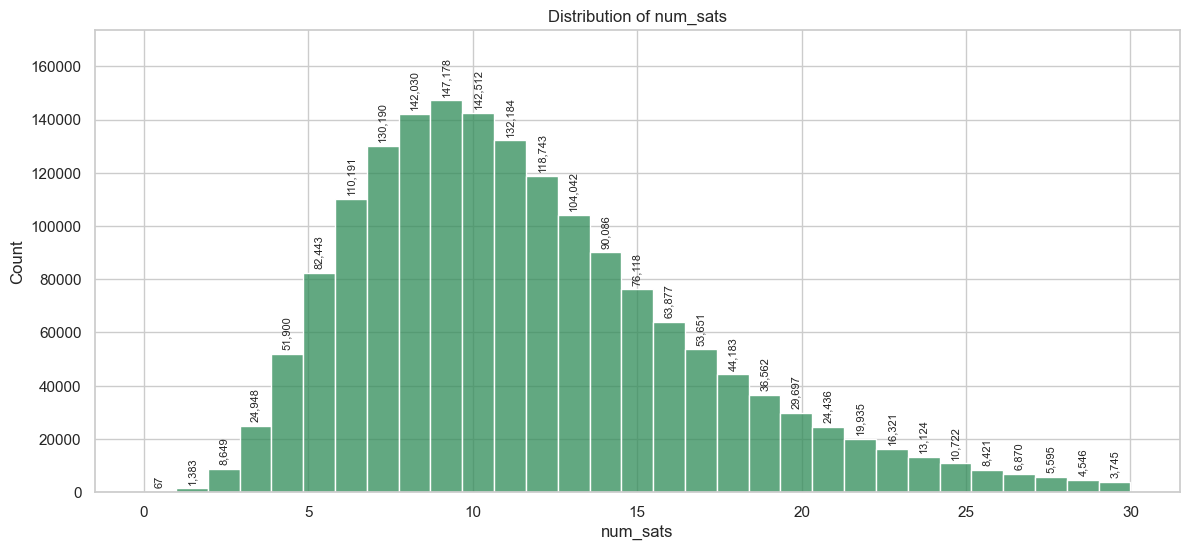

In [100]:
if 'num_sats' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_sats'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 30]
    ax = sns.histplot(x=data_to_plot, bins=31, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_sats')
    plt.xlabel('num_sats')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_sats' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_tl_120dpd_2m

Number of accounts currently 120 days past due (updated in past 2 months).
<br>
최근 2개월 기준 현재 120일 연체 중인 계좌 수. 대부분 0인 극단적 불균형 변수.

<br>

% 결측치 **5.5%** — 그래프는 결측치 제거 후 작성
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

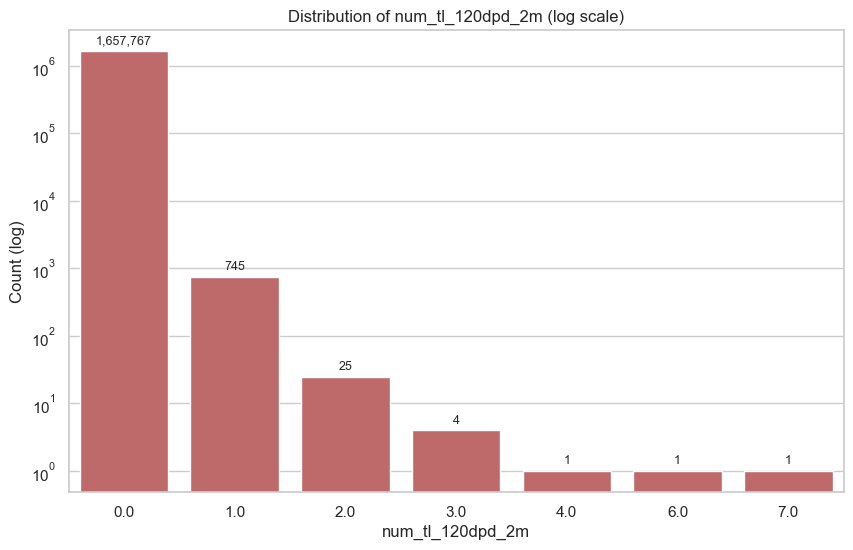

In [101]:
if 'num_tl_120dpd_2m' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['num_tl_120dpd_2m'].dropna()
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of num_tl_120dpd_2m (log scale)')
    plt.xlabel('num_tl_120dpd_2m')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'num_tl_120dpd_2m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_tl_30dpd

Number of accounts currently 30 days past due (updated in past 2 months).
<br>
최근 2개월 기준 현재 30일 연체 중인 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

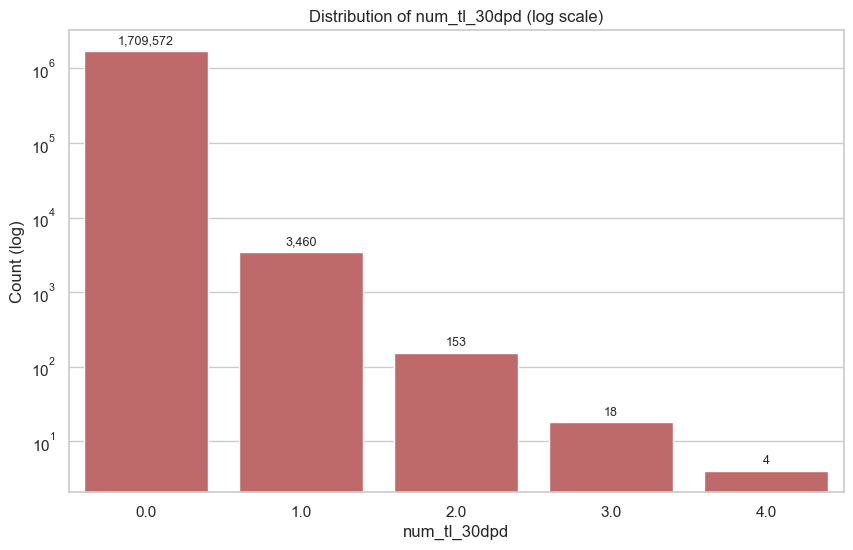

In [102]:
if 'num_tl_30dpd' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['num_tl_30dpd'].dropna()
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of num_tl_30dpd (log scale)')
    plt.xlabel('num_tl_30dpd')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'num_tl_30dpd' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_tl_90g_dpd_24m

Number of accounts 90 or more days past due in last 24 months.
<br>
최근 24개월간 90일 이상 연체된 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 5 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

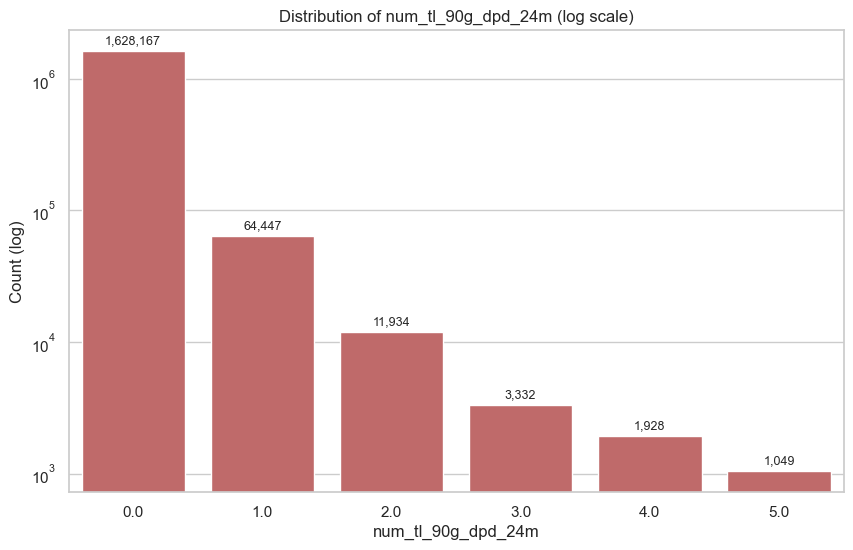

In [103]:
if 'num_tl_90g_dpd_24m' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['num_tl_90g_dpd_24m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of num_tl_90g_dpd_24m (log scale)')
    plt.xlabel('num_tl_90g_dpd_24m')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'num_tl_90g_dpd_24m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### num_tl_op_past_12m

Number of accounts opened in past 12 months.
<br>
최근 12개월간 신규 개설한 계좌 수.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

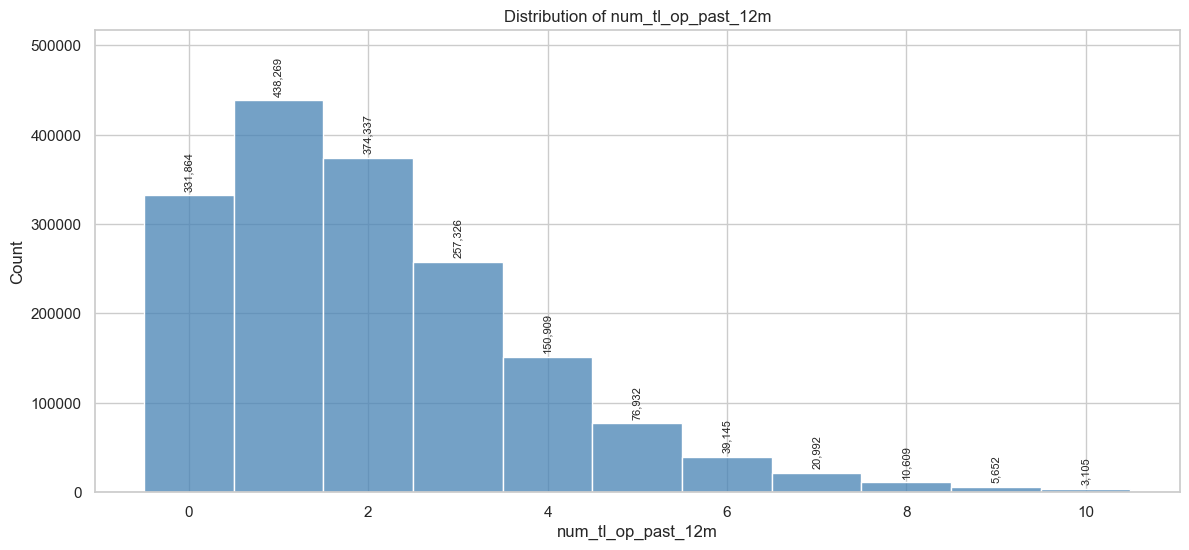

In [104]:
if 'num_tl_op_past_12m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['num_tl_op_past_12m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of num_tl_op_past_12m')
    plt.xlabel('num_tl_op_past_12m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'num_tl_op_past_12m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_acc

The number of open credit lines in the borrower's credit file.
<br>
신용 파일상 현재 개설되어 있는 신용 계좌 수.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 40 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

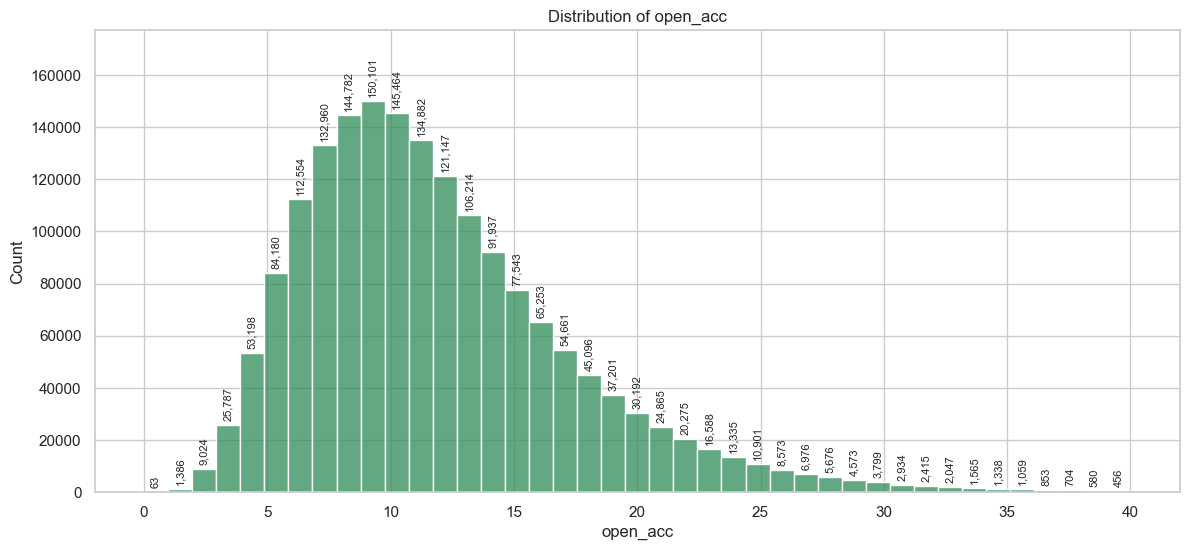

In [105]:
if 'open_acc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_acc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 40]
    ax = sns.histplot(x=data_to_plot, bins=41, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_acc')
    plt.xlabel('open_acc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_acc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_acc_6m

Number of open trades in last 6 months.
<br>
최근 6개월간 개설된 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 12 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

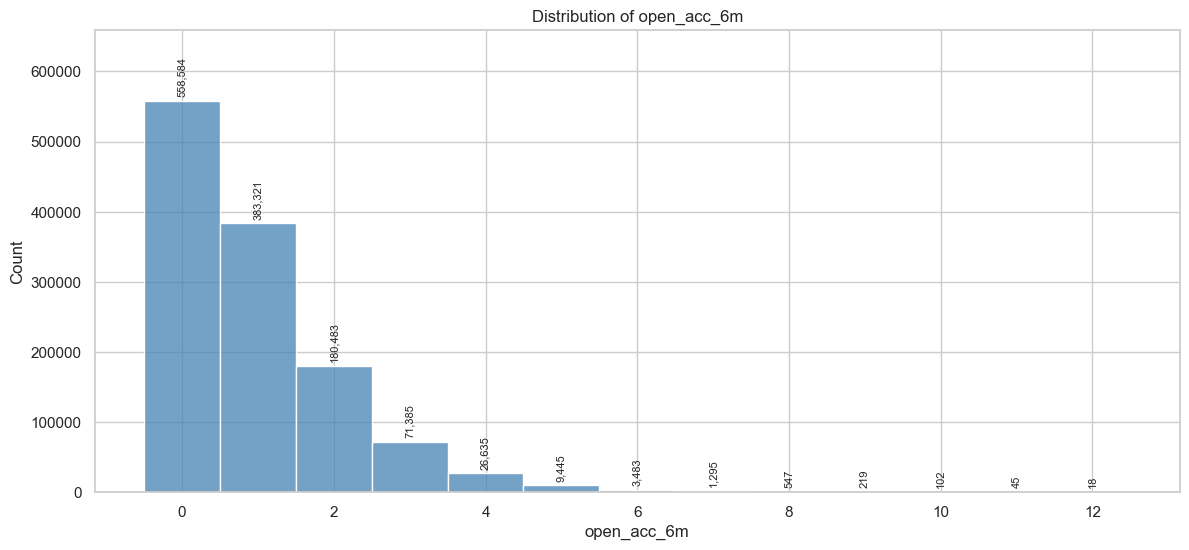

In [106]:
if 'open_acc_6m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_acc_6m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 12]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_acc_6m')
    plt.xlabel('open_acc_6m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_acc_6m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_act_il

Number of currently active installment trades.
<br>
현재 활성 상태인 할부 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

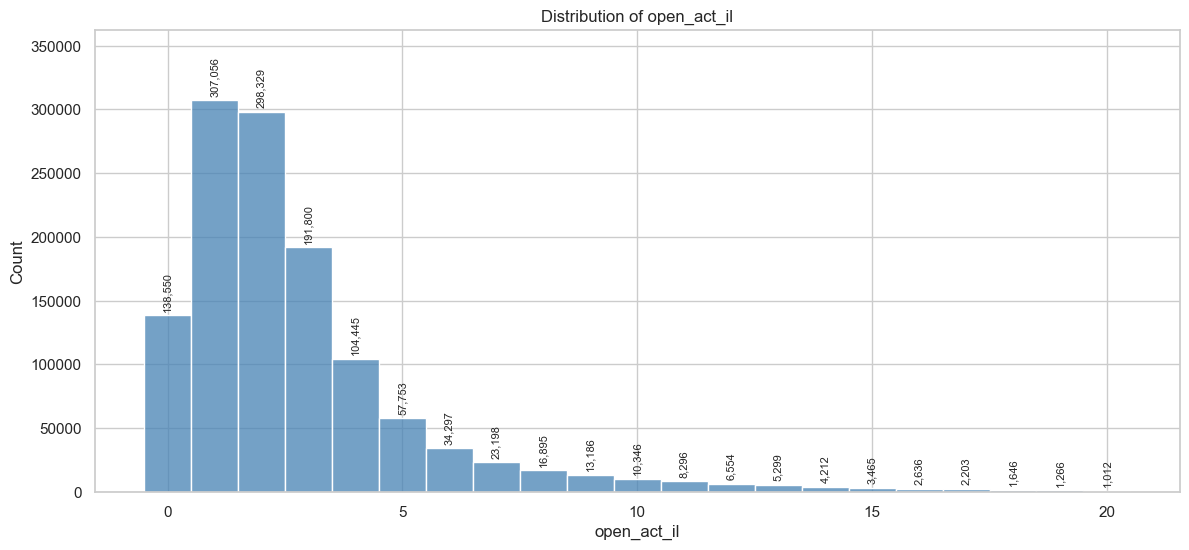

In [107]:
if 'open_act_il' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_act_il'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_act_il')
    plt.xlabel('open_act_il')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_act_il' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_il_12m

Number of installment accounts opened in past 12 months.
<br>
최근 12개월간 개설된 할부 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 9 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

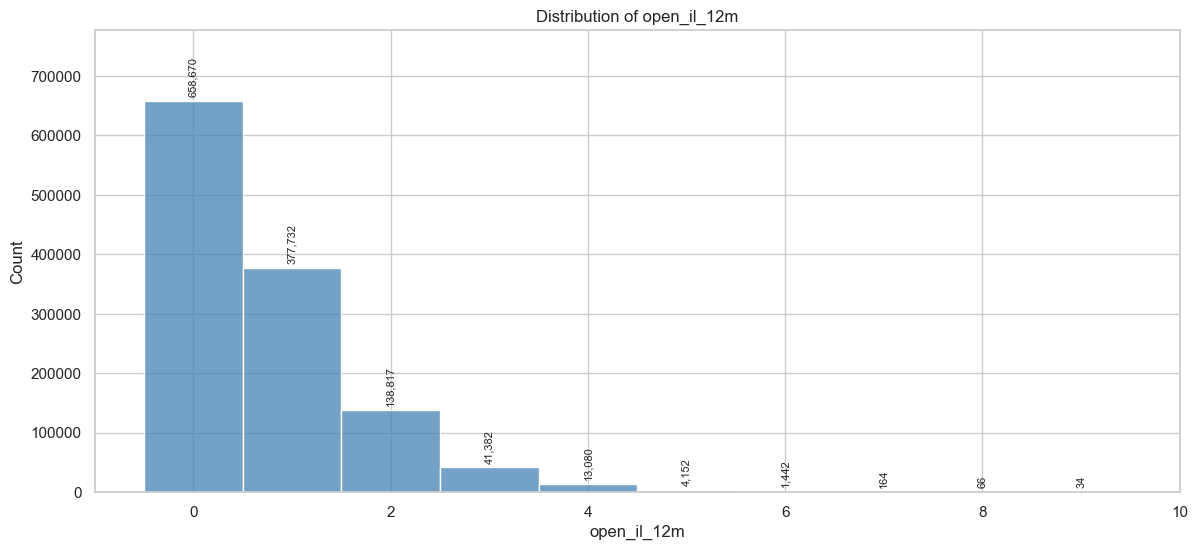

In [108]:
if 'open_il_12m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_il_12m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 9]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_il_12m')
    plt.xlabel('open_il_12m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_il_12m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_il_24m

Number of installment accounts opened in past 24 months.
<br>
최근 24개월간 개설된 할부 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 12 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

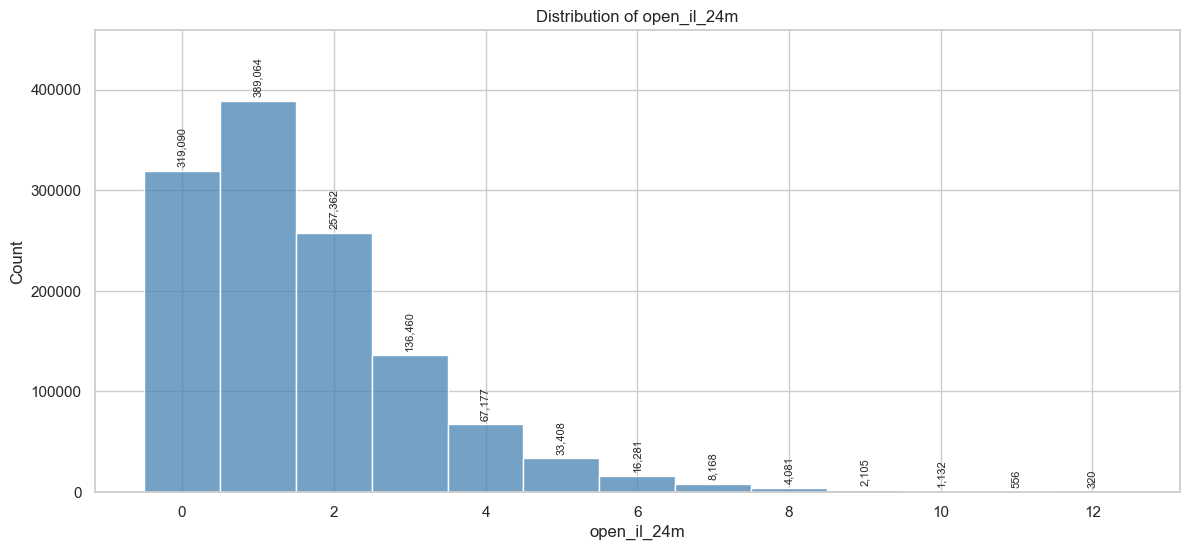

In [109]:
if 'open_il_24m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_il_24m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 12]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_il_24m')
    plt.xlabel('open_il_24m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_il_24m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_rv_12m

Number of revolving trades opened in past 12 months.
<br>
최근 12개월간 개설된 리볼빙 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 12 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

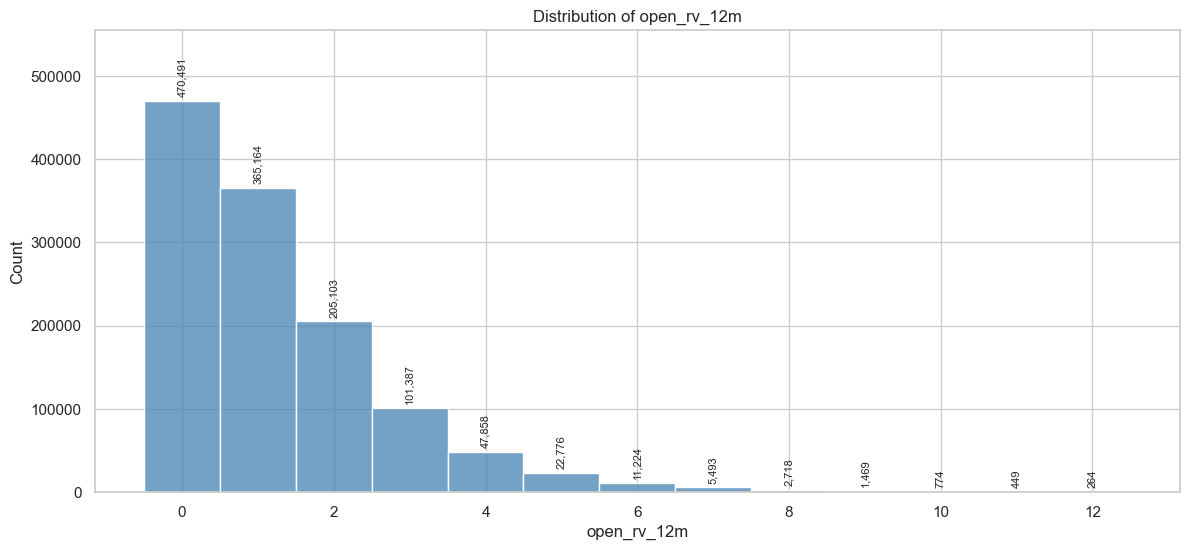

In [110]:
if 'open_rv_12m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_rv_12m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 12]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_rv_12m')
    plt.xlabel('open_rv_12m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_rv_12m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### open_rv_24m

Number of revolving trades opened in past 24 months.
<br>
최근 24개월간 개설된 리볼빙 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

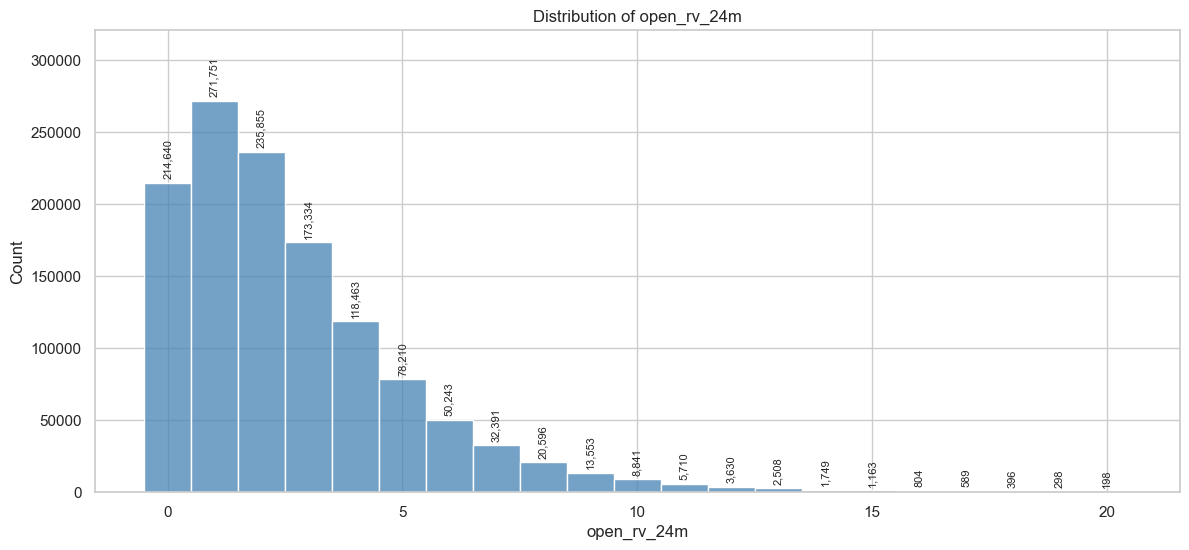

In [111]:
if 'open_rv_24m' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['open_rv_24m'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of open_rv_24m')
    plt.xlabel('open_rv_24m')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'open_rv_24m' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### orig_projected_additional_accrued_interest

The original projected additional interest amount that will accrue for the given hardship payment plan as of the hardship plan start date.
<br>
하드십 플랜으로 인해 추가로 발생할 것으로 최초 예상된 이자 금액.

<br>

% 결측치 **93.84%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 3,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

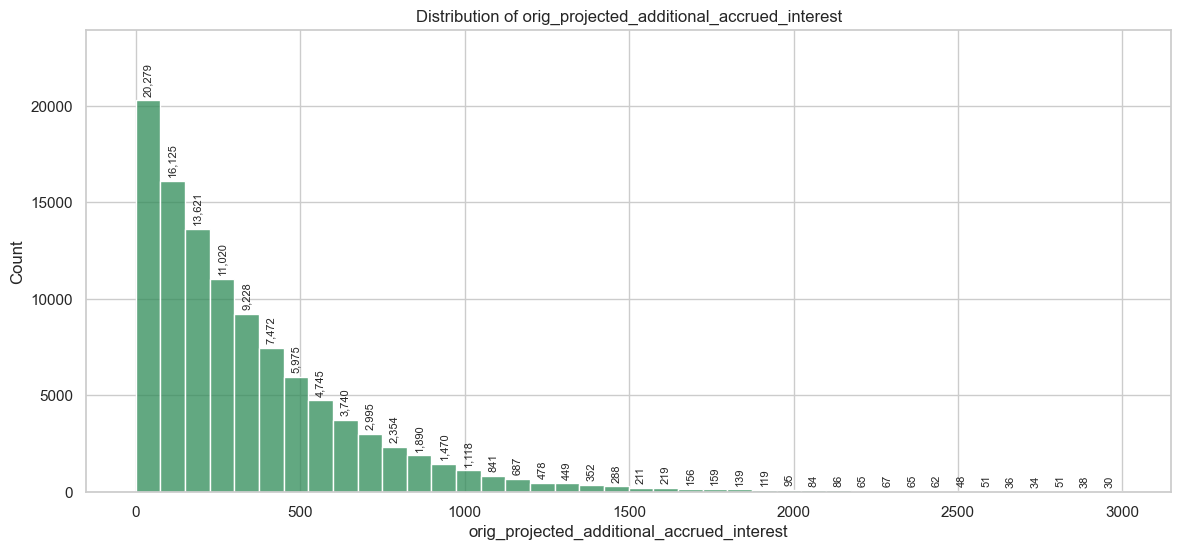

In [112]:
if 'orig_projected_additional_accrued_interest' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['orig_projected_additional_accrued_interest'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 3000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of orig_projected_additional_accrued_interest')
    plt.xlabel('orig_projected_additional_accrued_interest')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'orig_projected_additional_accrued_interest' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### out_prncp

Remaining outstanding principal for total amount funded.
<br>
아직 상환되지 않은 잔여 원금. 0이면 종결된 대출.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

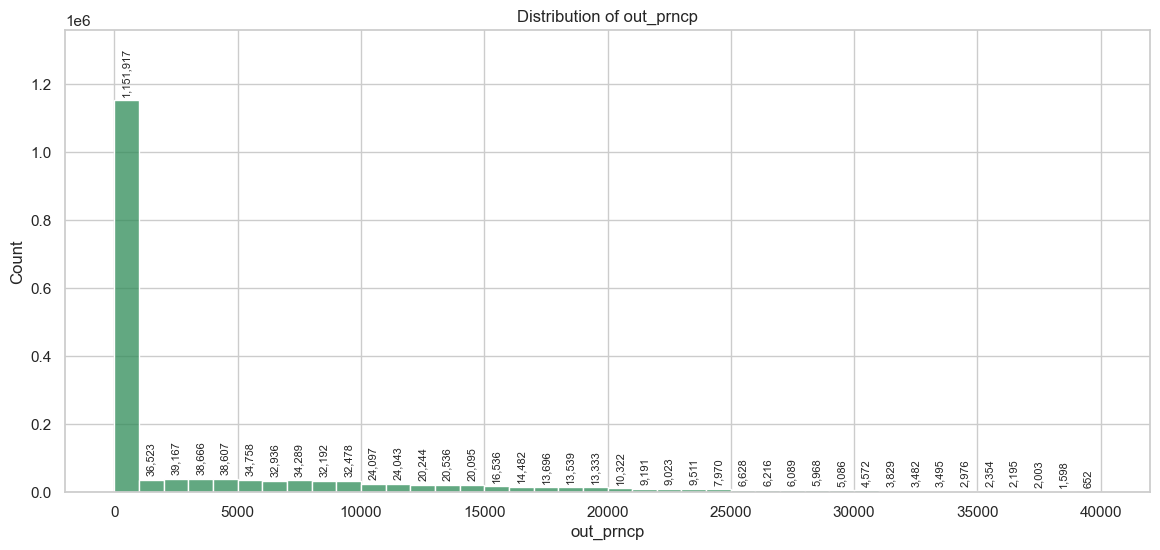

In [113]:
if 'out_prncp' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['out_prncp'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of out_prncp')
    plt.xlabel('out_prncp')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'out_prncp' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### out_prncp_inv

Remaining outstanding principal for portion of total amount funded by investors.
<br>
투자자 지분에 해당하는 잔여 원금. out_prncp와 거의 동일(다중공선성).

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

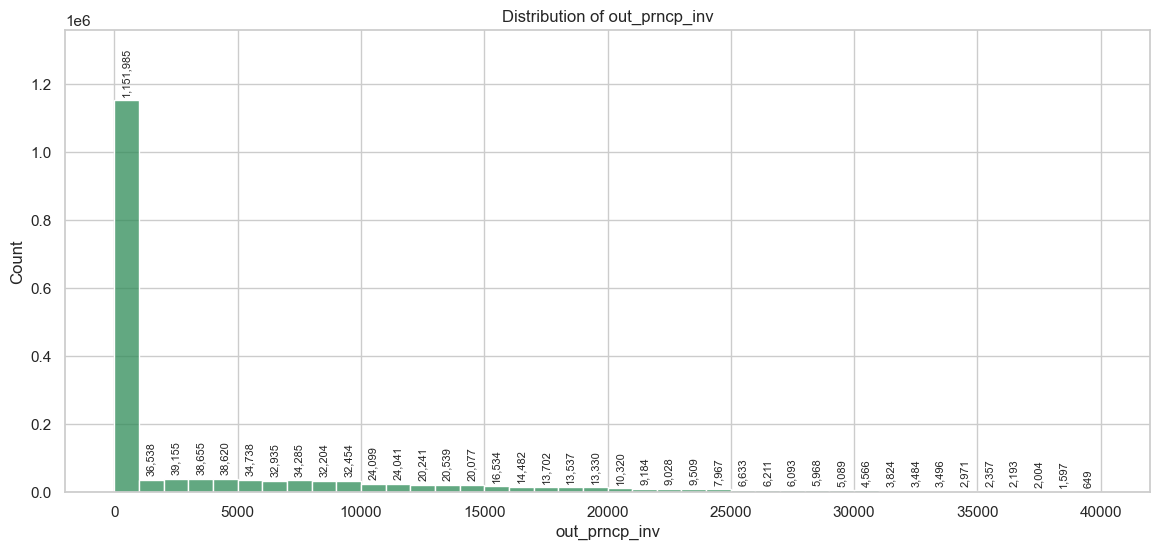

In [114]:
if 'out_prncp_inv' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['out_prncp_inv'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of out_prncp_inv')
    plt.xlabel('out_prncp_inv')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'out_prncp_inv' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### payment_plan_start_date

The day the first hardship plan payment is due.
<br>
하드십 플랜의 첫 납입 예정일.

<br>

% 결측치 **95.08%** — 그래프는 결측치 제거 후 작성
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

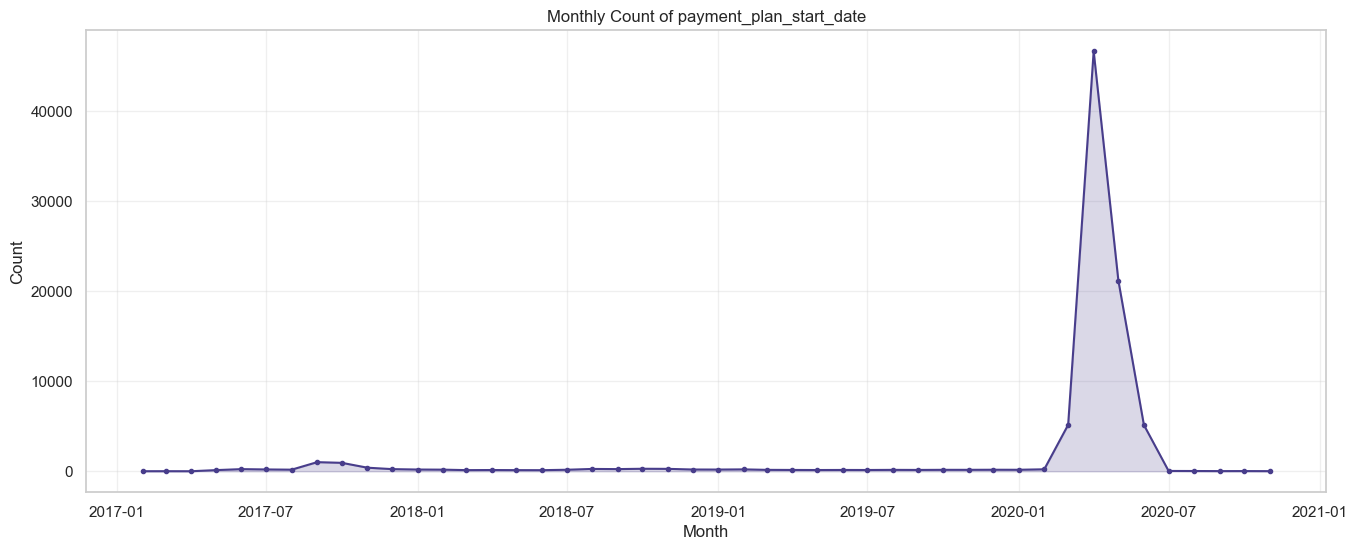

In [115]:
if 'payment_plan_start_date' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 'Mar-2016' 형식의 문자열을 날짜로 변환한 뒤 월별 건수를 집계
    s = pd.to_datetime(lending_club['payment_plan_start_date'], format='%b-%Y', errors='coerce').dropna()
    monthly = s.dt.to_period('M').value_counts().sort_index()

    plt.plot(monthly.index.to_timestamp(), monthly.values, marker='o', markersize=3, color='darkslateblue')
    plt.fill_between(monthly.index.to_timestamp(), monthly.values, alpha=0.2, color='darkslateblue')

    plt.title('Monthly Count of payment_plan_start_date')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("'payment_plan_start_date' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### pct_tl_nvr_dlq

Percent of trades never delinquent.
<br>
전체 계좌 중 한 번도 연체된 적 없는 계좌의 비율(%). 100%에 크게 몰린 좌측 꼬리 분포.

<br>

% 결측치 **2.34%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

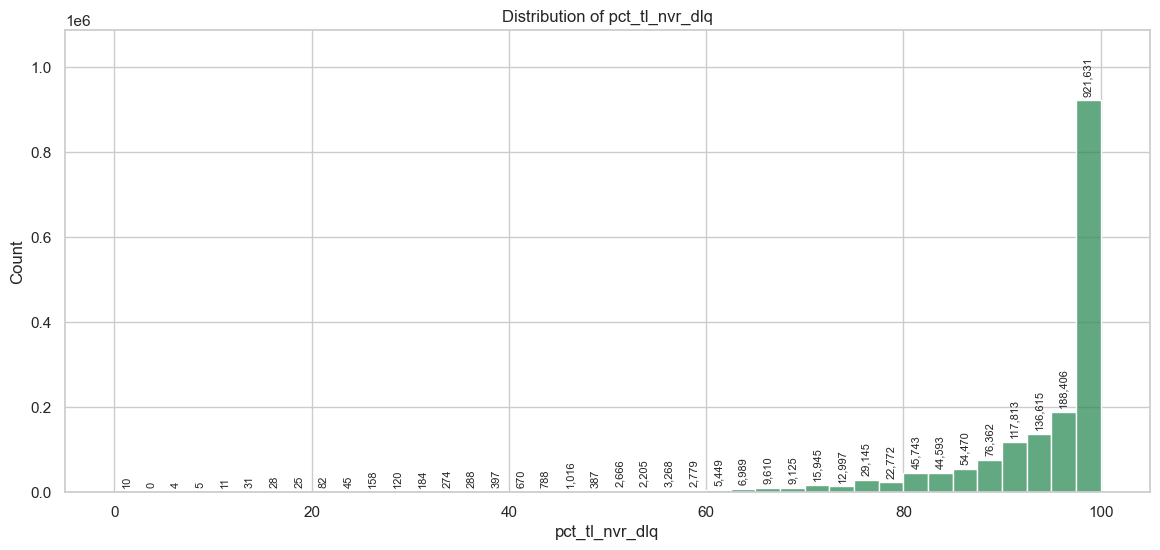

In [116]:
if 'pct_tl_nvr_dlq' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['pct_tl_nvr_dlq'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of pct_tl_nvr_dlq')
    plt.xlabel('pct_tl_nvr_dlq')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'pct_tl_nvr_dlq' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### percent_bc_gt_75

Percentage of all bankcard accounts > 75% of limit.
<br>
한도의 75%를 초과해 사용 중인 신용카드 계좌의 비율(%).

<br>

% 결측치 **2.82%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

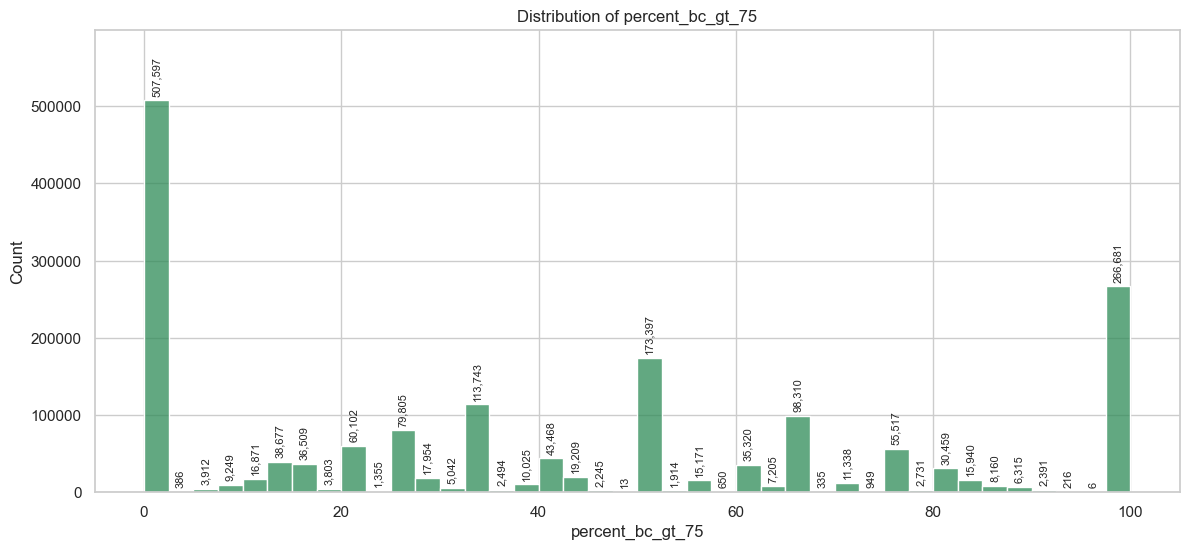

In [117]:
if 'percent_bc_gt_75' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['percent_bc_gt_75'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of percent_bc_gt_75')
    plt.xlabel('percent_bc_gt_75')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'percent_bc_gt_75' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### policy_code

publicly available policy_code=1, new products not publicly available policy_code=2.
<br>
공개 상품 여부 코드. 본 데이터에서는 전부 1인 **상수 변수**이므로 제거 대상.

<br>

🚫 **사용 금지 (상수)** — 분산이 0이므로 정보량 없음. 제거.

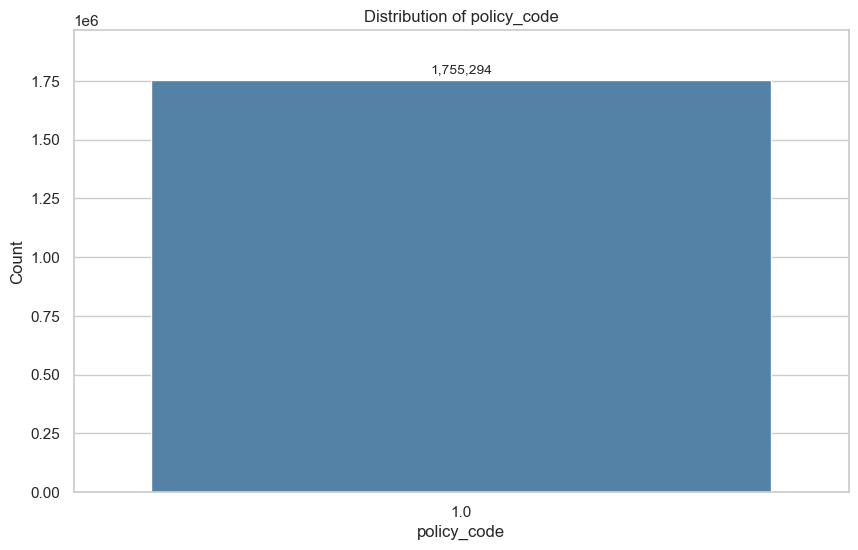

In [118]:
if 'policy_code' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['policy_code']
    ax = sns.countplot(x=data_to_plot, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=10, padding=3)

    plt.title('Distribution of policy_code')
    plt.xlabel('policy_code')
    plt.ylabel('Count')
    plt.margins(y=0.12)
    plt.show()
else:
    print("'policy_code' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### pub_rec

Number of derogatory public records.
<br>
불리한 공공기록(파산, 세금유치권, 판결 등) 건수.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 5 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

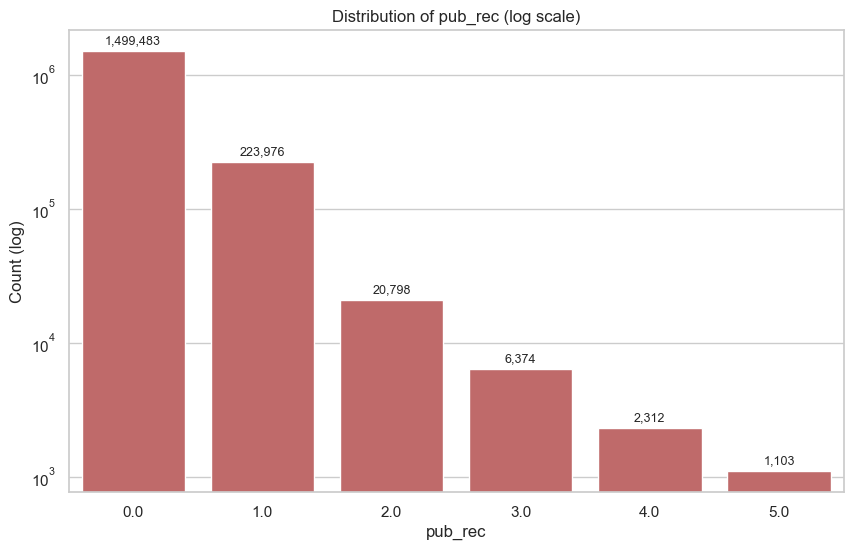

In [119]:
if 'pub_rec' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['pub_rec'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of pub_rec (log scale)')
    plt.xlabel('pub_rec')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'pub_rec' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### pub_rec_bankruptcies

Number of public record bankruptcies.
<br>
공공기록상 파산 건수.

<br>

% 결측치 **0.05%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 5 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

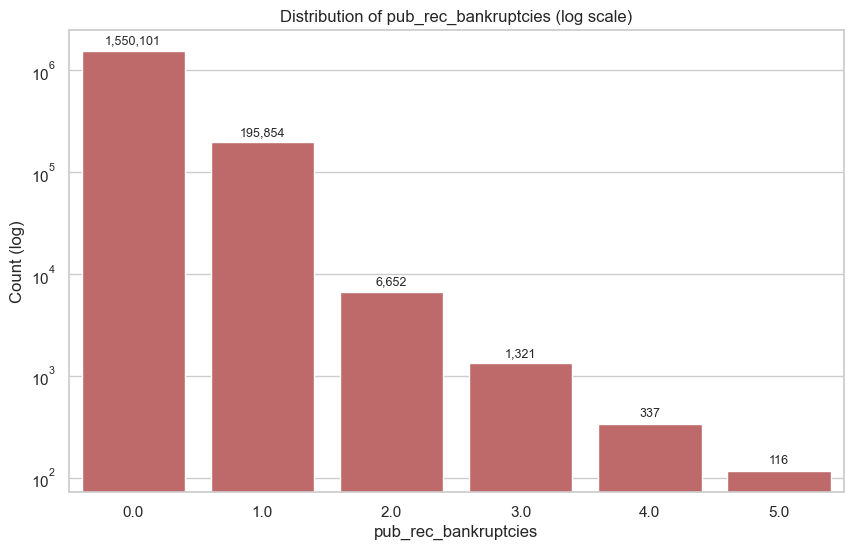

In [120]:
if 'pub_rec_bankruptcies' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['pub_rec_bankruptcies'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of pub_rec_bankruptcies (log scale)')
    plt.xlabel('pub_rec_bankruptcies')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'pub_rec_bankruptcies' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### recoveries

Post charge off gross recovery.
<br>
상각(charge-off) 이후 회수된 총액. **IRR 현금흐름 계산에는 필요하지만 예측 변수로는 사용 불가.**

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 5,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

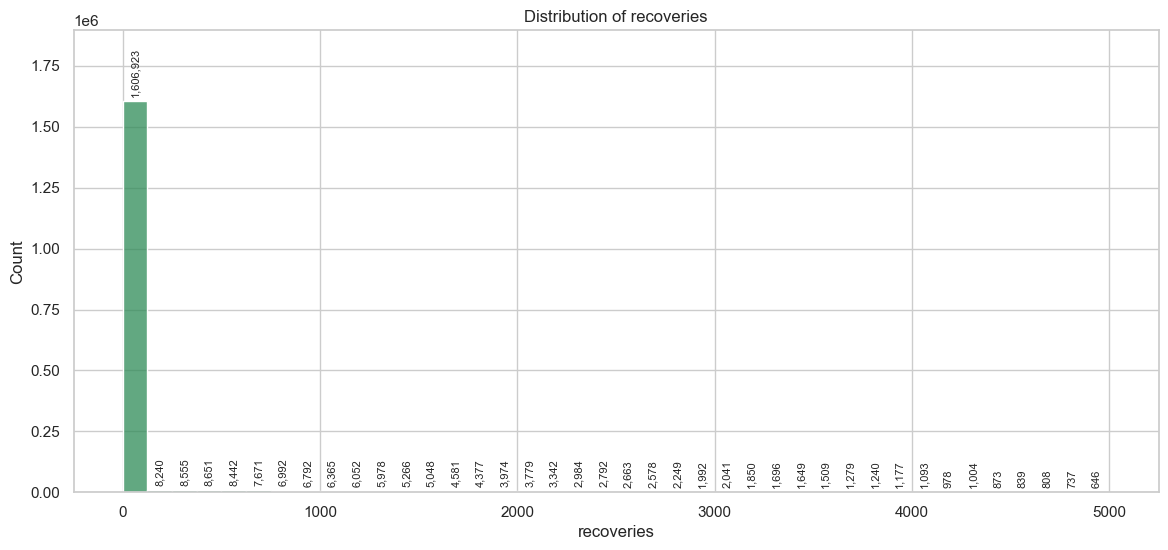

In [121]:
if 'recoveries' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['recoveries'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of recoveries')
    plt.xlabel('recoveries')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'recoveries' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### revol_bal

Total credit revolving balance.
<br>
리볼빙(신용카드) 총 사용 잔액.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 100,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

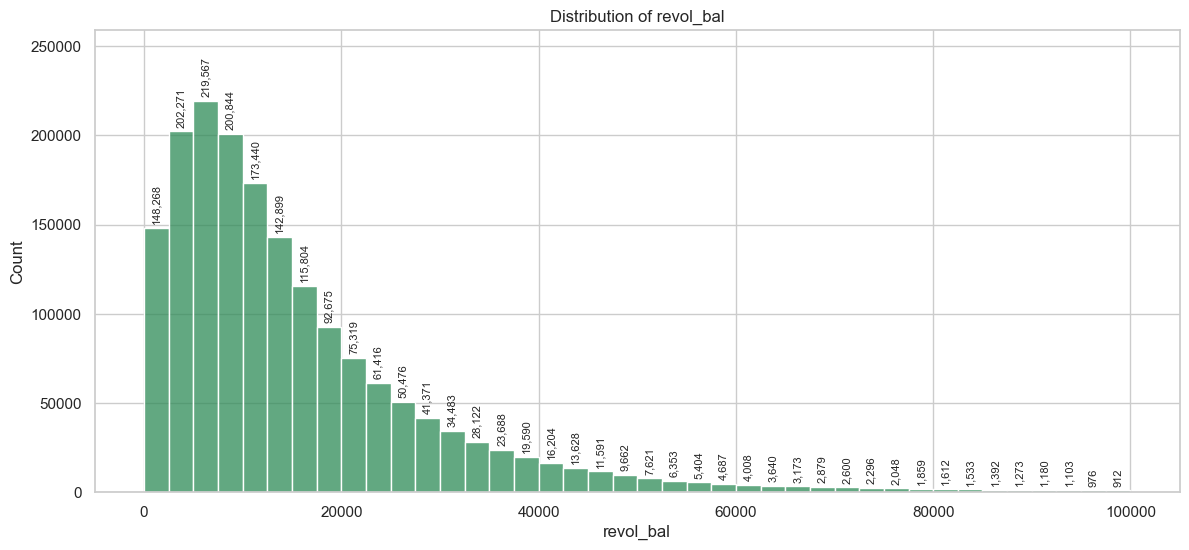

In [122]:
if 'revol_bal' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['revol_bal'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 100000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of revol_bal')
    plt.xlabel('revol_bal')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'revol_bal' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### revol_bal_joint

Sum of revolving credit balance of the co-borrowers, net of duplicate balances.
<br>
공동 차입자 합산 리볼빙 잔액. 개인 대출 건은 구조적 결측(93%).

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

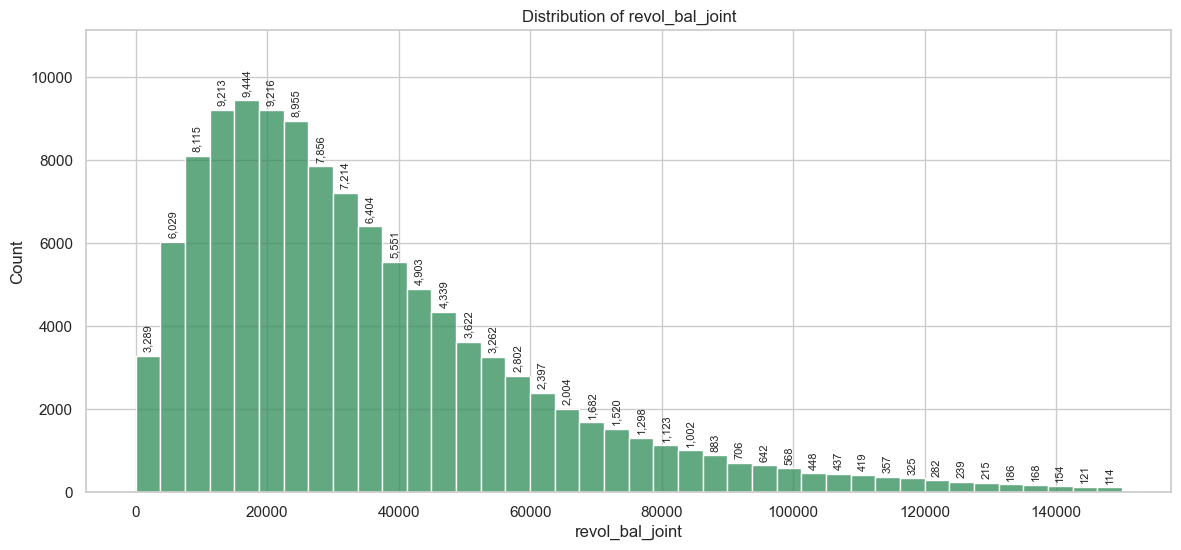

In [123]:
if 'revol_bal_joint' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['revol_bal_joint'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of revol_bal_joint')
    plt.xlabel('revol_bal_joint')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'revol_bal_joint' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### revol_util

Revolving line utilization rate, the amount of credit the borrower is using relative to all available revolving credit.
<br>
리볼빙 한도 대비 사용률(%). 문자열('55%')로 저장되어 숫자 변환 필요. 부도 예측력이 매우 높은 변수.

<br>

% 결측치 **0.06%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

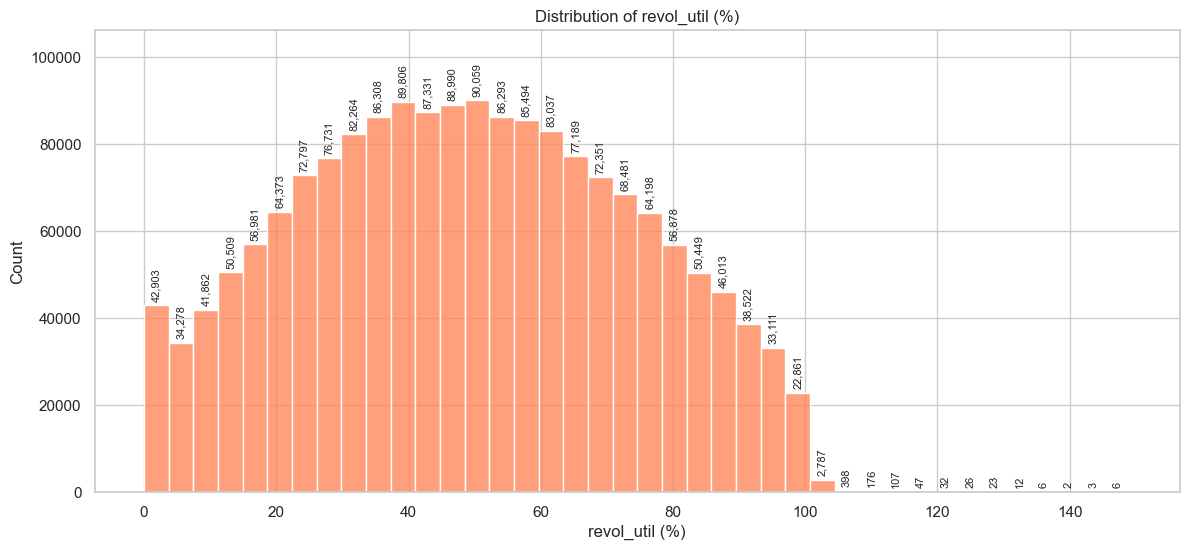

In [124]:
if 'revol_util' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    # '  8.19%' 같은 문자열이므로 % 기호와 공백을 제거하고 숫자로 변환
    s = lending_club['revol_util'].astype(str).str.replace('%', '', regex=False).str.strip()
    data_to_plot = pd.to_numeric(s, errors='coerce').dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150]
    ax = sns.histplot(x=data_to_plot, bins=40, color='coral')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of revol_util (%)')
    plt.xlabel('revol_util (%)')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'revol_util' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_chargeoff_within_12_mths

Number of charge-offs within last 12 months at time of application for the secondary applicant.
<br>
공동 신청 시 제2신청자의 최근 12개월 상각 건수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 4 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

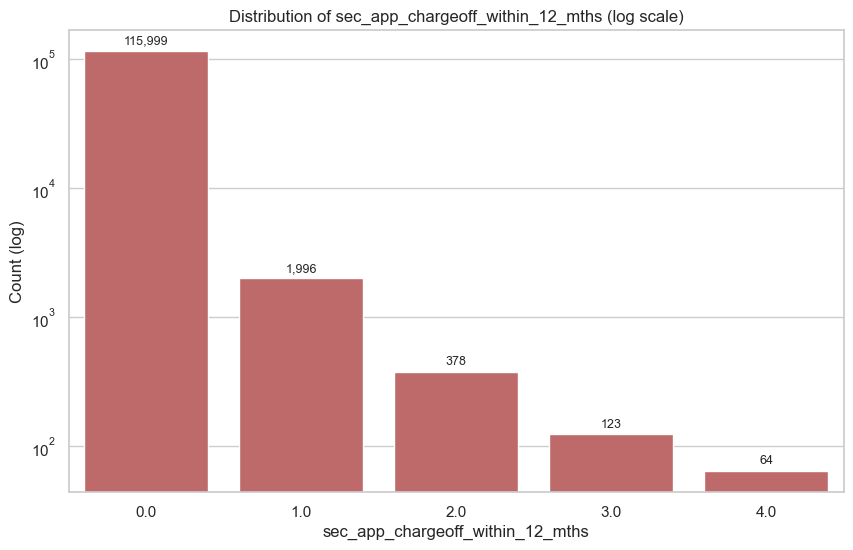

In [125]:
if 'sec_app_chargeoff_within_12_mths' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['sec_app_chargeoff_within_12_mths'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 4]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of sec_app_chargeoff_within_12_mths (log scale)')
    plt.xlabel('sec_app_chargeoff_within_12_mths')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'sec_app_chargeoff_within_12_mths' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_collections_12_mths_ex_med

Number of collections within last 12 months excluding medical collections at time of application for the secondary applicant.
<br>
제2신청자의 최근 12개월 추심 건수(의료비 제외).

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 4 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

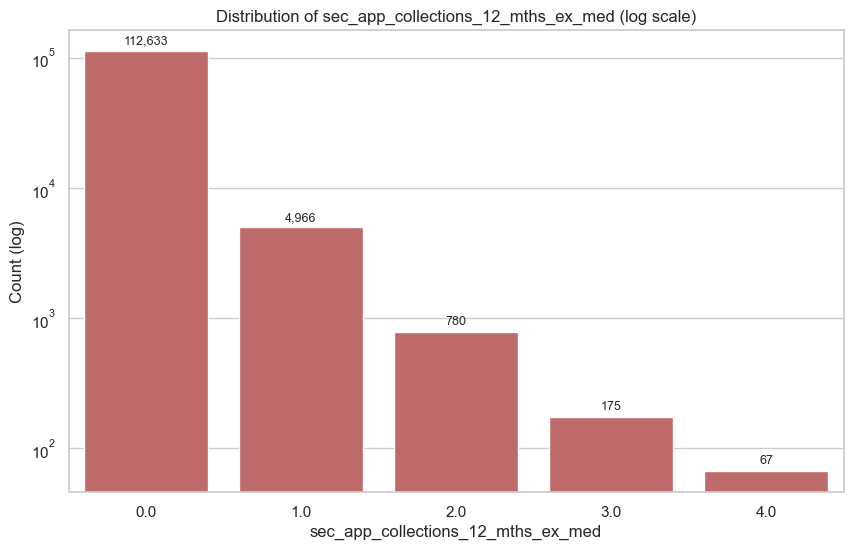

In [126]:
if 'sec_app_collections_12_mths_ex_med' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['sec_app_collections_12_mths_ex_med'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 4]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of sec_app_collections_12_mths_ex_med (log scale)')
    plt.xlabel('sec_app_collections_12_mths_ex_med')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'sec_app_collections_12_mths_ex_med' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_earliest_cr_line

Earliest credit line at time of application for the secondary applicant.
<br>
제2신청자의 최초 신용거래 개설 시점. 연도 단위로 변환해 신용이력 길이로 사용.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

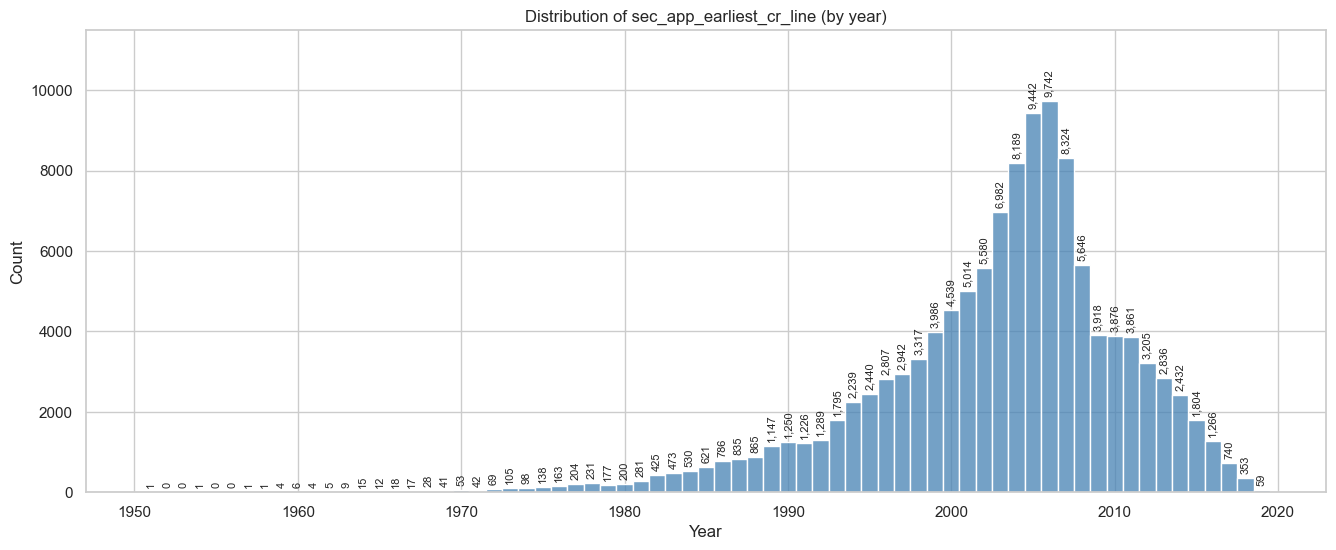

In [127]:
if 'sec_app_earliest_cr_line' in lending_club.columns:
    plt.figure(figsize=(16, 6))

    # 연도 단위로 변환하여 분포 확인
    s = pd.to_datetime(lending_club['sec_app_earliest_cr_line'], format='%b-%Y', errors='coerce').dropna()
    ax = sns.histplot(x=s.dt.year, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_earliest_cr_line (by year)')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_earliest_cr_line' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_fico_range_high

FICO range (high) for the secondary applicant.
<br>
제2신청자 FICO 점수 구간의 상한.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

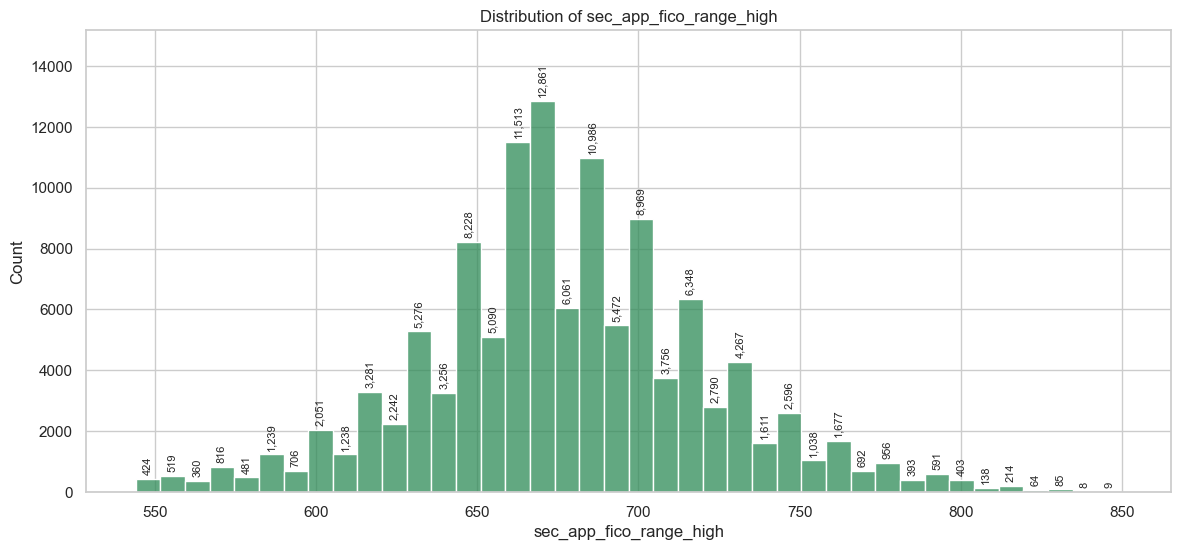

In [128]:
if 'sec_app_fico_range_high' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_fico_range_high'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_fico_range_high')
    plt.xlabel('sec_app_fico_range_high')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_fico_range_high' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_fico_range_low

FICO range (low) for the secondary applicant.
<br>
제2신청자 FICO 점수 구간의 하한. high와 거의 완전 상관(다중공선성).

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

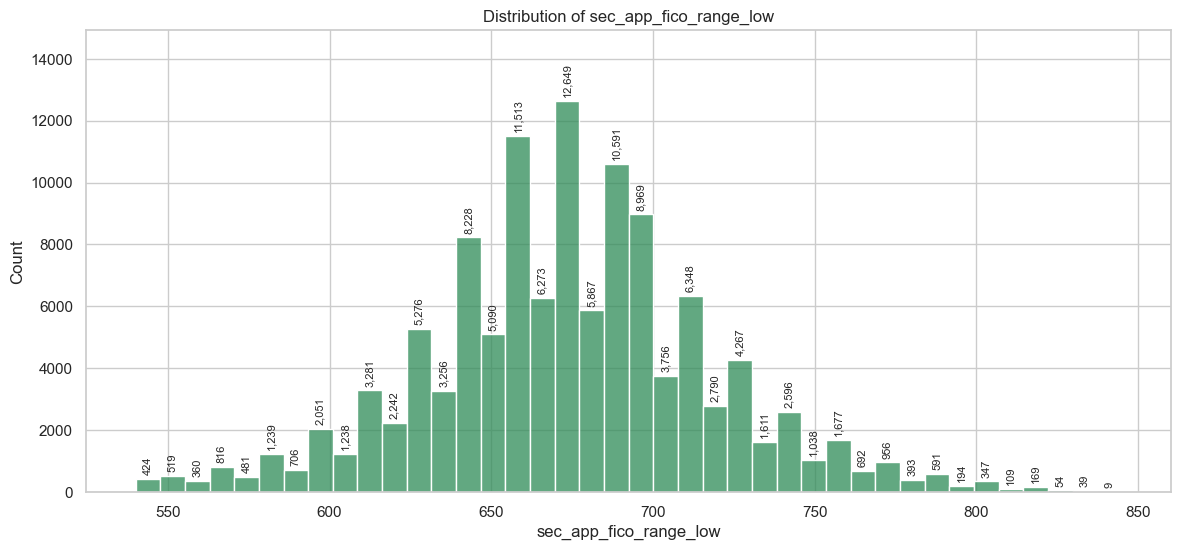

In [129]:
if 'sec_app_fico_range_low' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_fico_range_low'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_fico_range_low')
    plt.xlabel('sec_app_fico_range_low')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_fico_range_low' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_inq_last_6mths

Credit inquiries in the last 6 months at time of application for the secondary applicant.
<br>
제2신청자의 최근 6개월 신용 조회 건수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 6 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

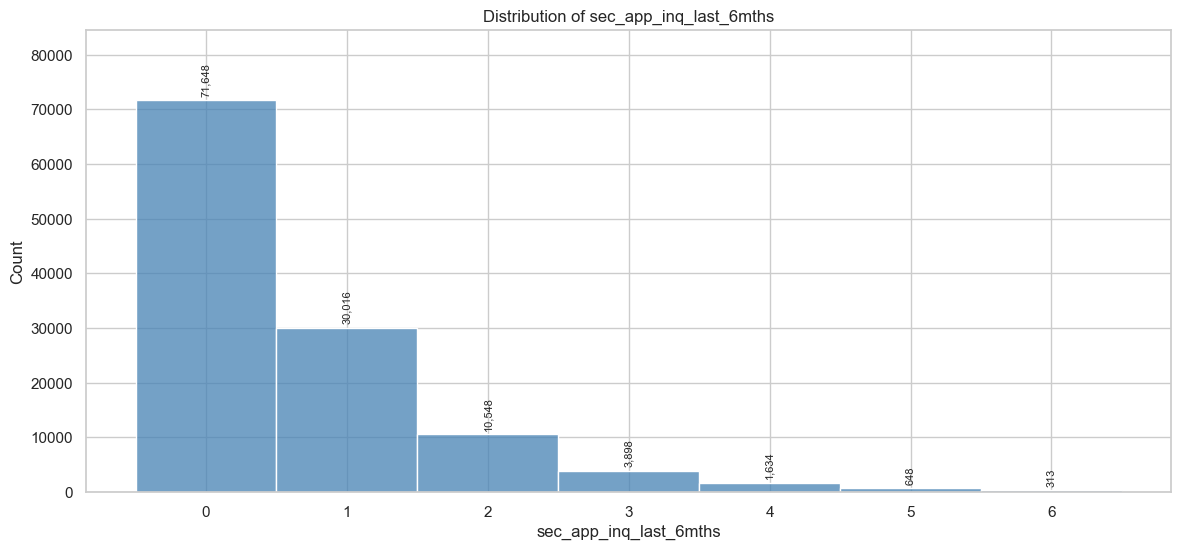

In [130]:
if 'sec_app_inq_last_6mths' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_inq_last_6mths'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 6]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_inq_last_6mths')
    plt.xlabel('sec_app_inq_last_6mths')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_inq_last_6mths' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_mort_acc

Number of mortgage accounts at time of application for the secondary applicant.
<br>
제2신청자의 주택담보대출 계좌 수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 10 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

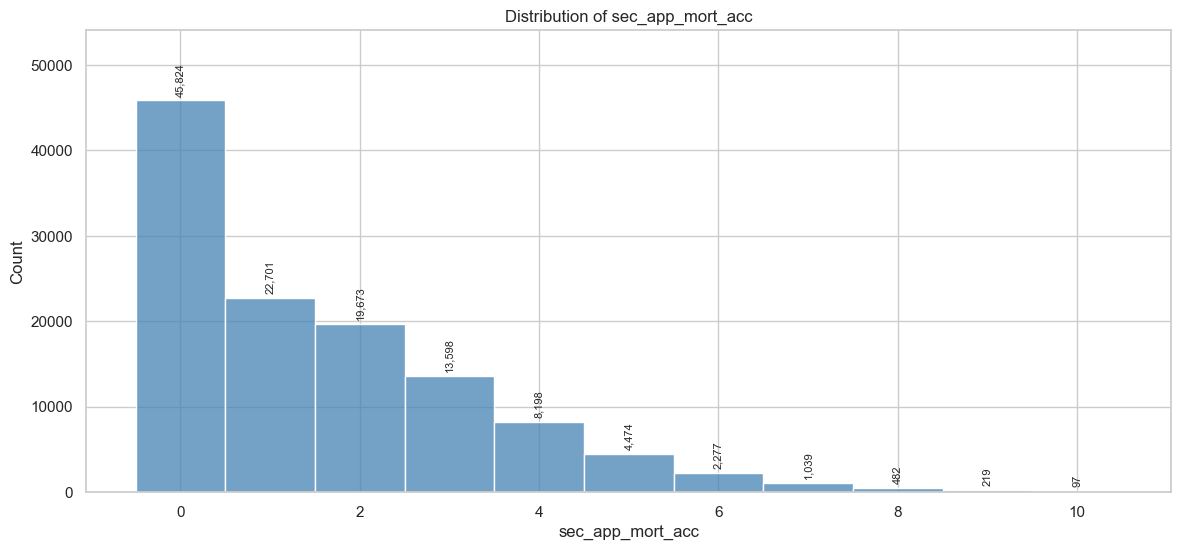

In [131]:
if 'sec_app_mort_acc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_mort_acc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 10]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_mort_acc')
    plt.xlabel('sec_app_mort_acc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_mort_acc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_num_rev_accts

Number of revolving accounts at time of application for the secondary applicant.
<br>
제2신청자의 리볼빙 계좌 수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 50 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

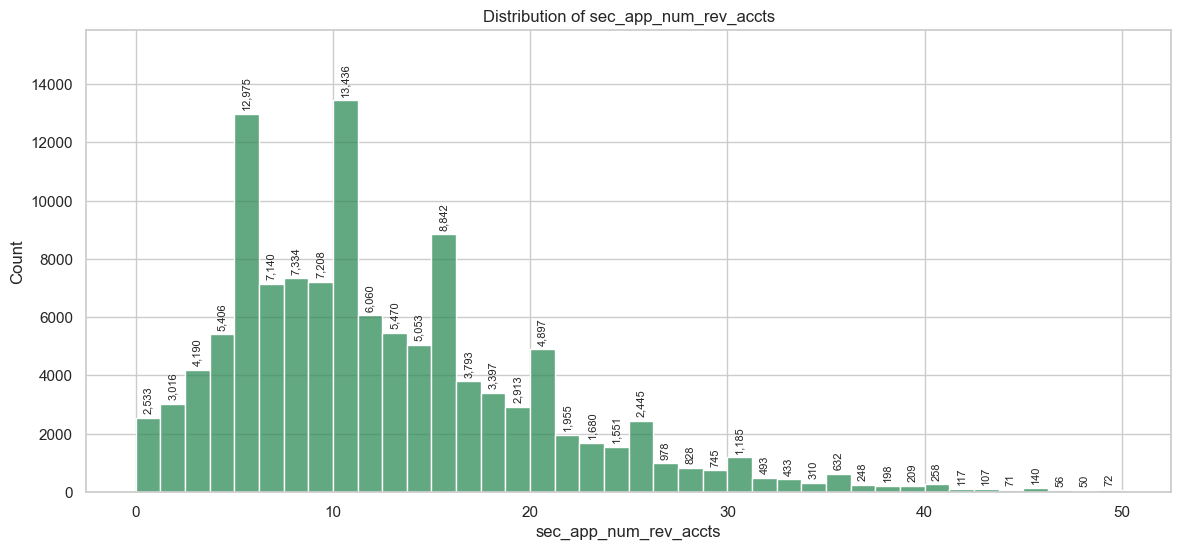

In [132]:
if 'sec_app_num_rev_accts' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_num_rev_accts'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 50]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_num_rev_accts')
    plt.xlabel('sec_app_num_rev_accts')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_num_rev_accts' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_open_acc

Number of open trades at time of application for the secondary applicant.
<br>
제2신청자의 개설 계좌 수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 40 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

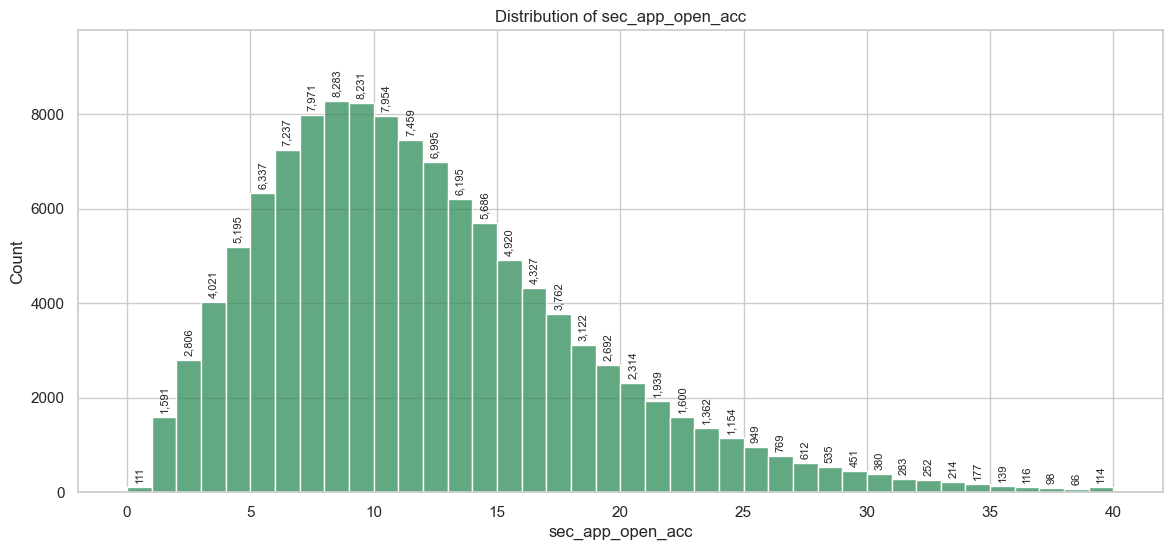

In [133]:
if 'sec_app_open_acc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_open_acc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 40]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_open_acc')
    plt.xlabel('sec_app_open_acc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_open_acc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_open_act_il

Number of currently active installment trades at time of application for the secondary applicant.
<br>
제2신청자의 활성 할부 계좌 수.

<br>

% 결측치 **93.12%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

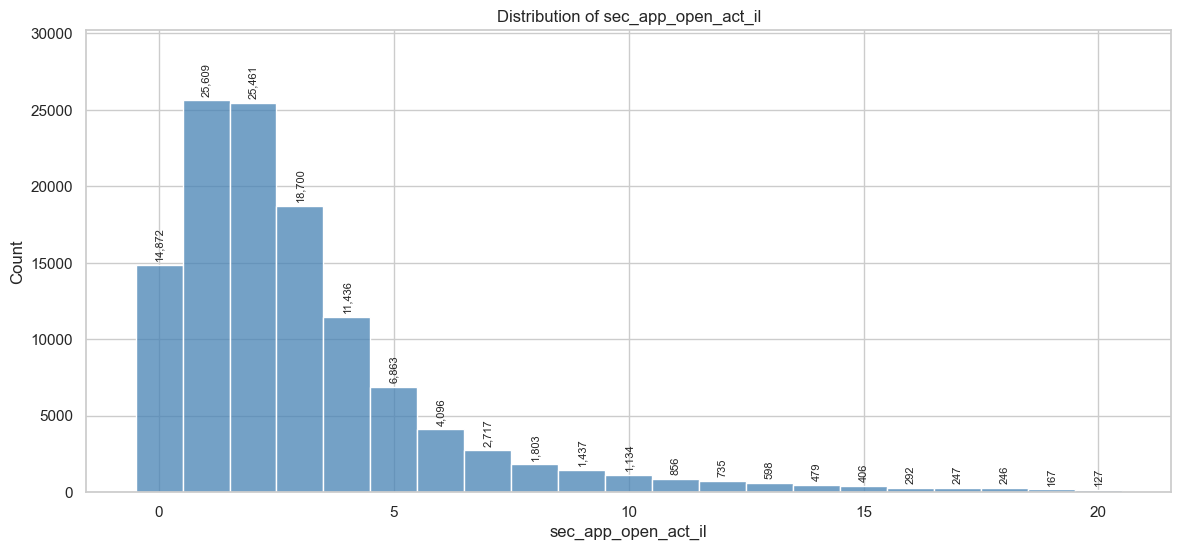

In [134]:
if 'sec_app_open_act_il' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_open_act_il'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_open_act_il')
    plt.xlabel('sec_app_open_act_il')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_open_act_il' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### sec_app_revol_util

Ratio of total current balance to high credit/credit limit for all revolving accounts.
<br>
제2신청자의 리볼빙 한도 대비 사용률(%).

<br>

% 결측치 **93.24%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

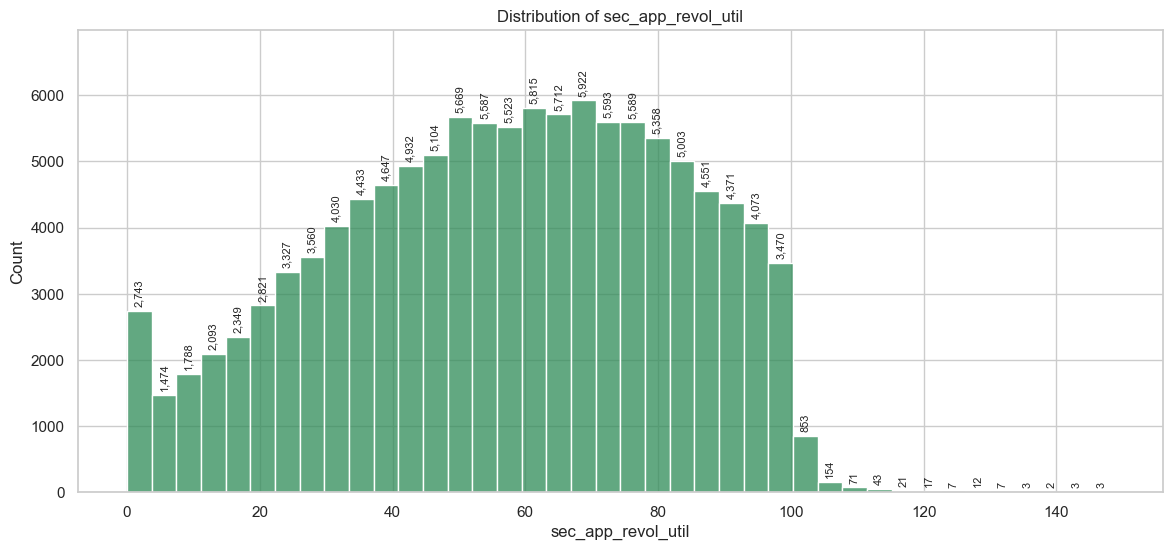

In [135]:
if 'sec_app_revol_util' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['sec_app_revol_util'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of sec_app_revol_util')
    plt.xlabel('sec_app_revol_util')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'sec_app_revol_util' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### tax_liens

Number of tax liens.
<br>
세금 유치권(체납으로 인한 재산권 압류) 건수.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 5 이하 구간만 시각화
<br>
% 0에 극단적으로 쏠려 있어 y축 로그 스케일 적용
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

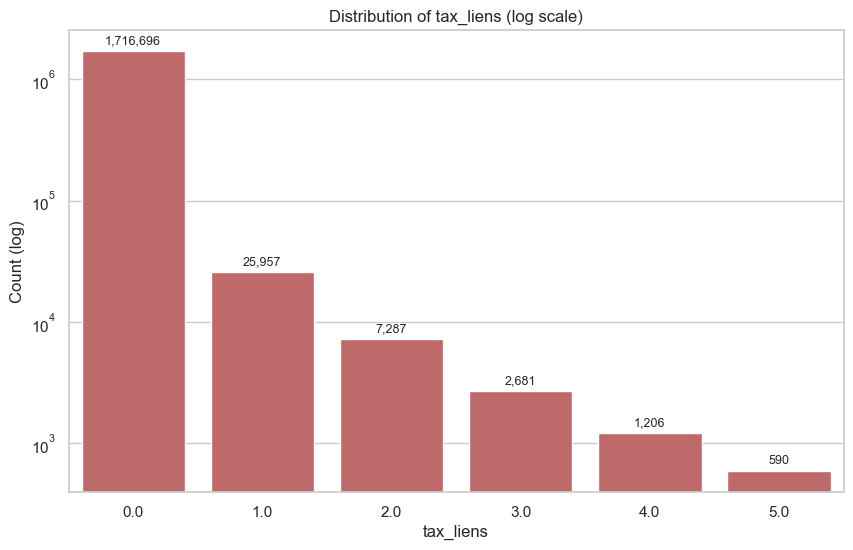

In [136]:
if 'tax_liens' in lending_club.columns:
    plt.figure(figsize=(10, 6))

    data_to_plot = lending_club['tax_liens'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5]
    ax = sns.countplot(x=data_to_plot, color='indianred')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=9, padding=3)

    # 0에 압도적으로 몰려 있어 로그 스케일로 확인
    plt.yscale('log')
    plt.title('Distribution of tax_liens (log scale)')
    plt.xlabel('tax_liens')
    plt.ylabel('Count (log)')
    plt.show()
else:
    print("'tax_liens' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### tot_coll_amt

Total collection amounts ever owed.
<br>
과거 추심(collection) 대상이 되었던 총 금액.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 5,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

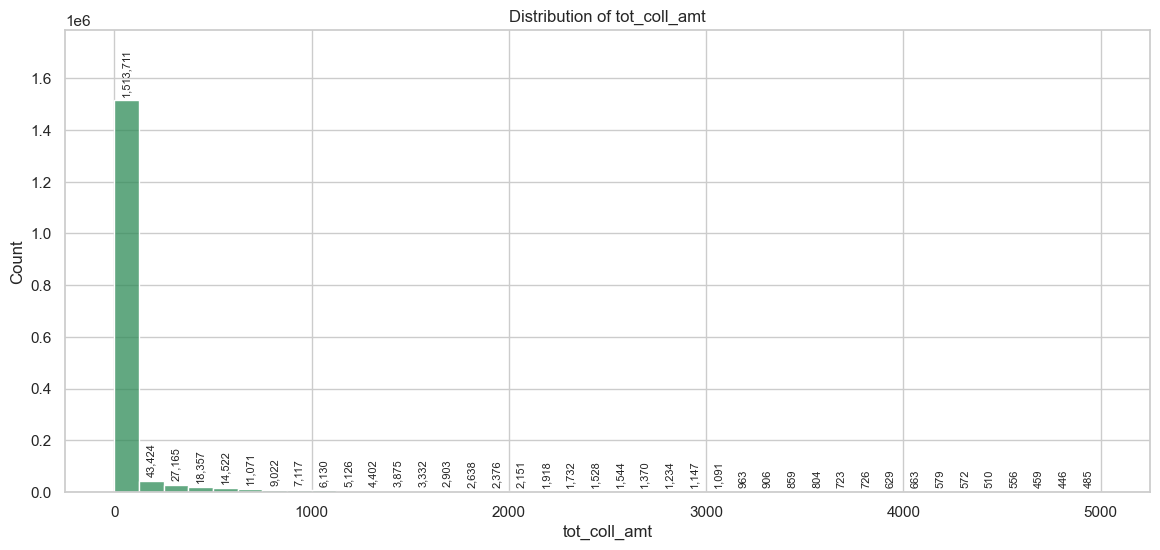

In [137]:
if 'tot_coll_amt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['tot_coll_amt'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 5000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of tot_coll_amt')
    plt.xlabel('tot_coll_amt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'tot_coll_amt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### tot_cur_bal

Total current balance of all accounts.
<br>
보유 전체 계좌의 현재 잔액 합계(총 부채 규모).

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 800,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

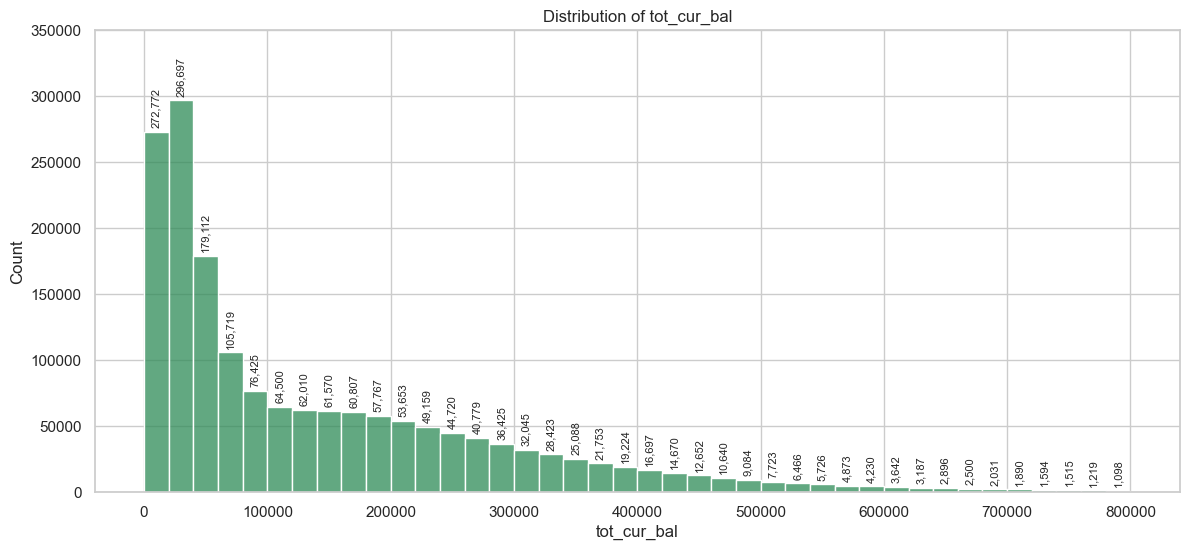

In [138]:
if 'tot_cur_bal' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['tot_cur_bal'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 800000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of tot_cur_bal')
    plt.xlabel('tot_cur_bal')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'tot_cur_bal' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### tot_hi_cred_lim

Total high credit/credit limit.
<br>
전체 계좌의 총 신용한도.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 1,000,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

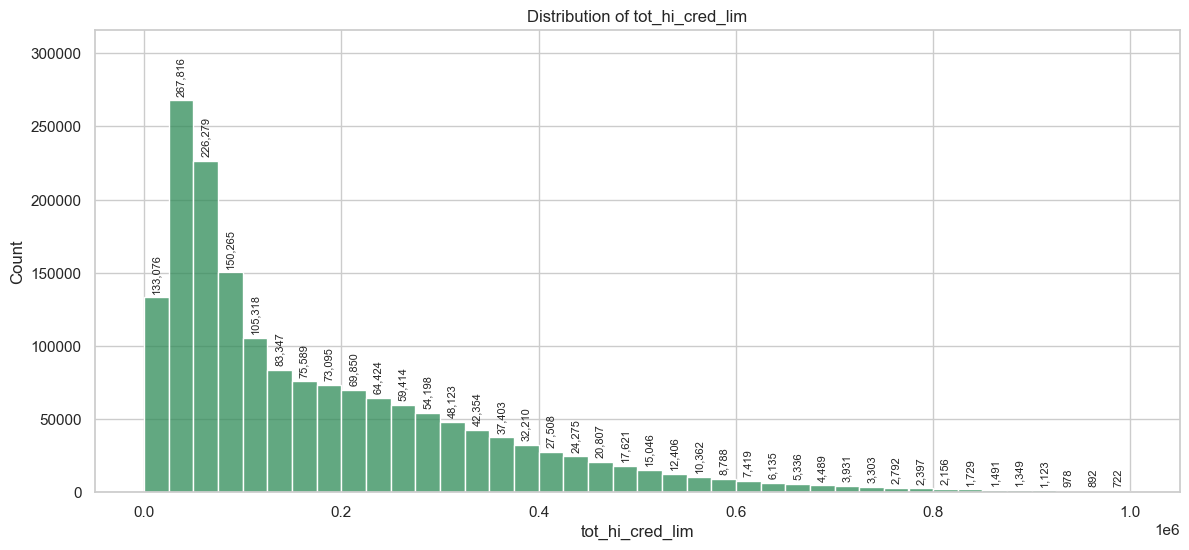

In [139]:
if 'tot_hi_cred_lim' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['tot_hi_cred_lim'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 1000000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of tot_hi_cred_lim')
    plt.xlabel('tot_hi_cred_lim')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'tot_hi_cred_lim' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_acc

The total number of credit lines currently in the borrower's credit file.
<br>
신용 파일에 기록된 전체 신용 계좌 수(폐쇄분 포함).

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 80 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

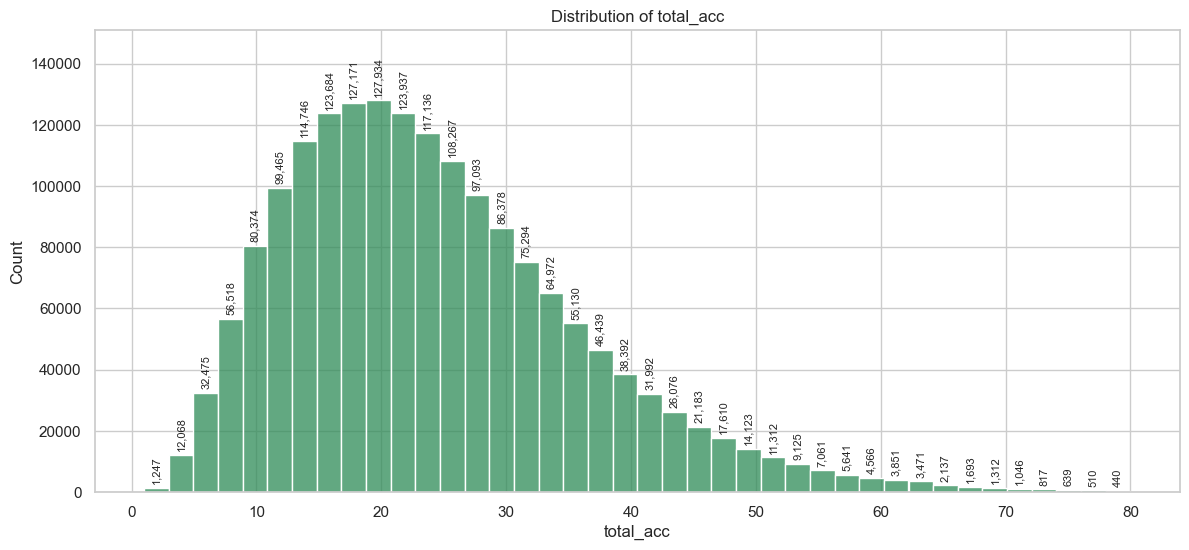

In [140]:
if 'total_acc' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_acc'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 80]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_acc')
    plt.xlabel('total_acc')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_acc' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_bal_ex_mort

Total credit balance excluding mortgage.
<br>
주택담보대출을 제외한 총 신용 잔액.

<br>

% 결측치 **1.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 300,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

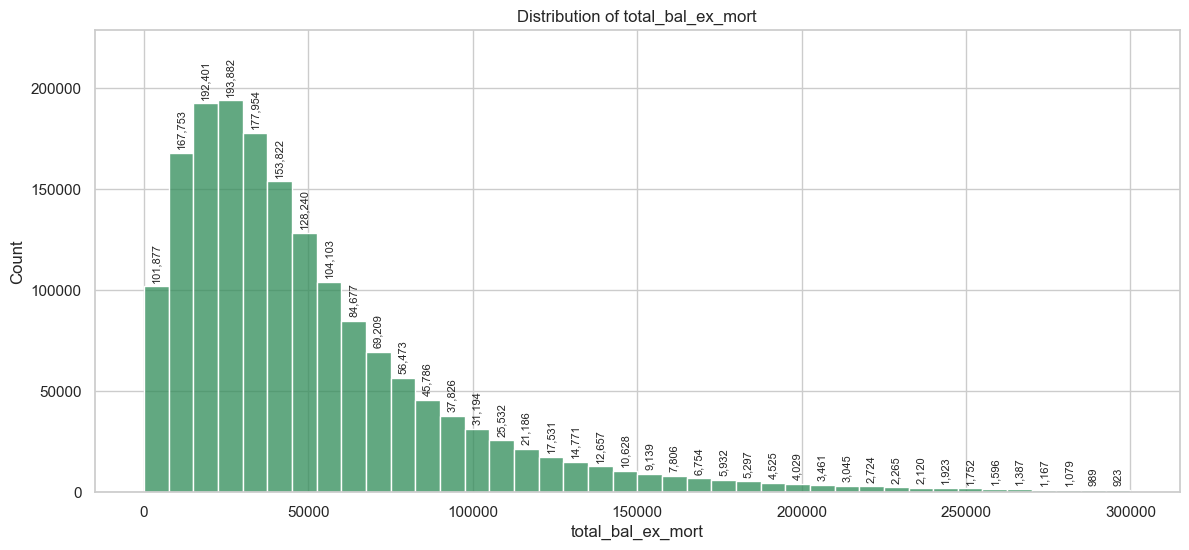

In [141]:
if 'total_bal_ex_mort' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_bal_ex_mort'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 300000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_bal_ex_mort')
    plt.xlabel('total_bal_ex_mort')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_bal_ex_mort' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_bal_il

Total current balance of all installment accounts.
<br>
전체 할부 계좌의 현재 잔액 합계.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 200,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

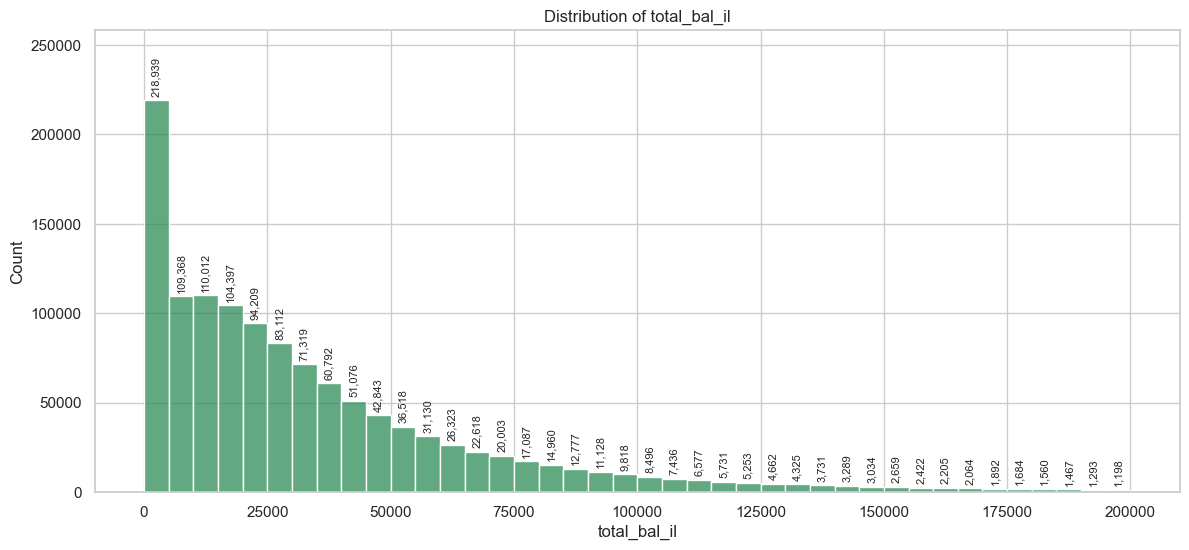

In [142]:
if 'total_bal_il' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_bal_il'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 200000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_bal_il')
    plt.xlabel('total_bal_il')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_bal_il' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_bc_limit

Total bankcard high credit/credit limit.
<br>
전체 은행 신용카드의 총 한도.

<br>

% 결측치 **1.68%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 150,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

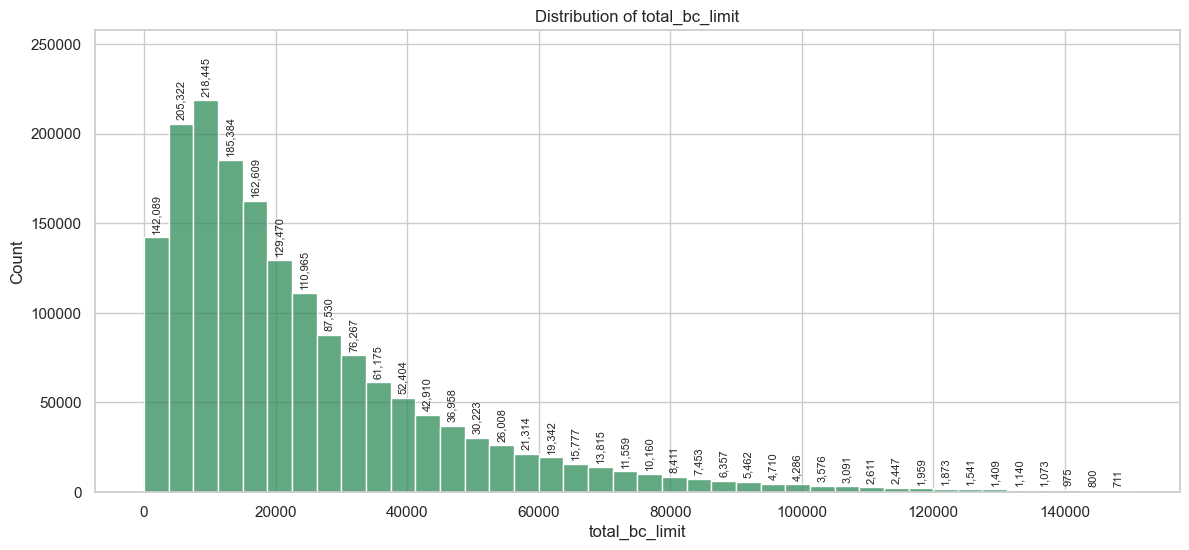

In [143]:
if 'total_bc_limit' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_bc_limit'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 150000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_bc_limit')
    plt.xlabel('total_bc_limit')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_bc_limit' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_cu_tl

Number of finance trades.
<br>
신용조합(credit union) 계좌 수.

<br>

% 결측치 **29.61%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 20 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

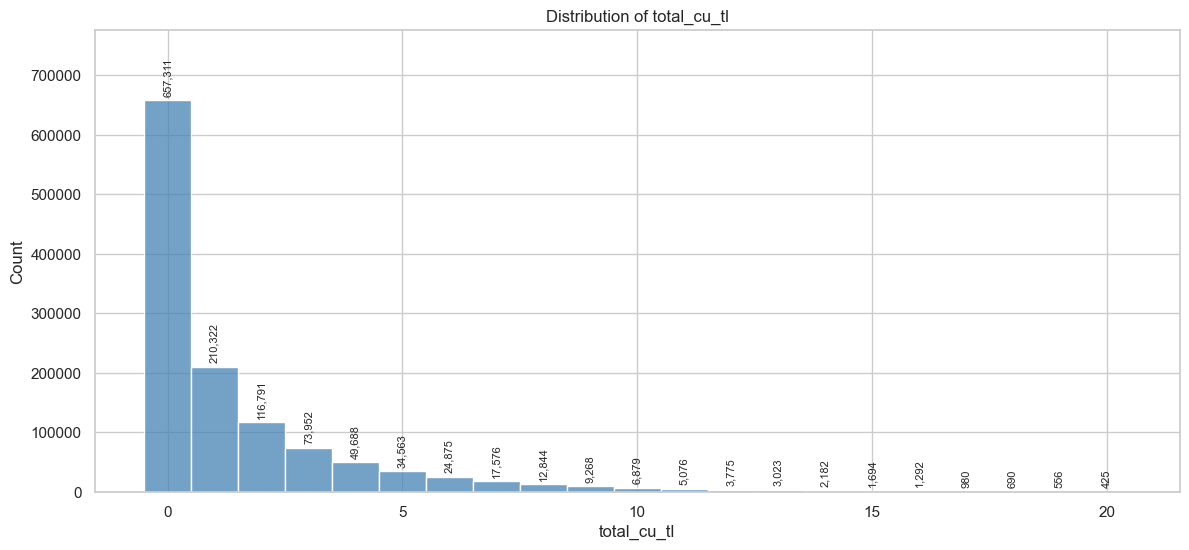

In [144]:
if 'total_cu_tl' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_cu_tl'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 20]
    # 정수형 변수이므로 discrete=True 로 1 단위 히스토그램 작성
    ax = sns.histplot(x=data_to_plot, discrete=True, color='steelblue')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_cu_tl')
    plt.xlabel('total_cu_tl')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_cu_tl' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_il_high_credit_limit

Total installment high credit/credit limit.
<br>
전체 할부 계좌의 총 한도.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 250,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

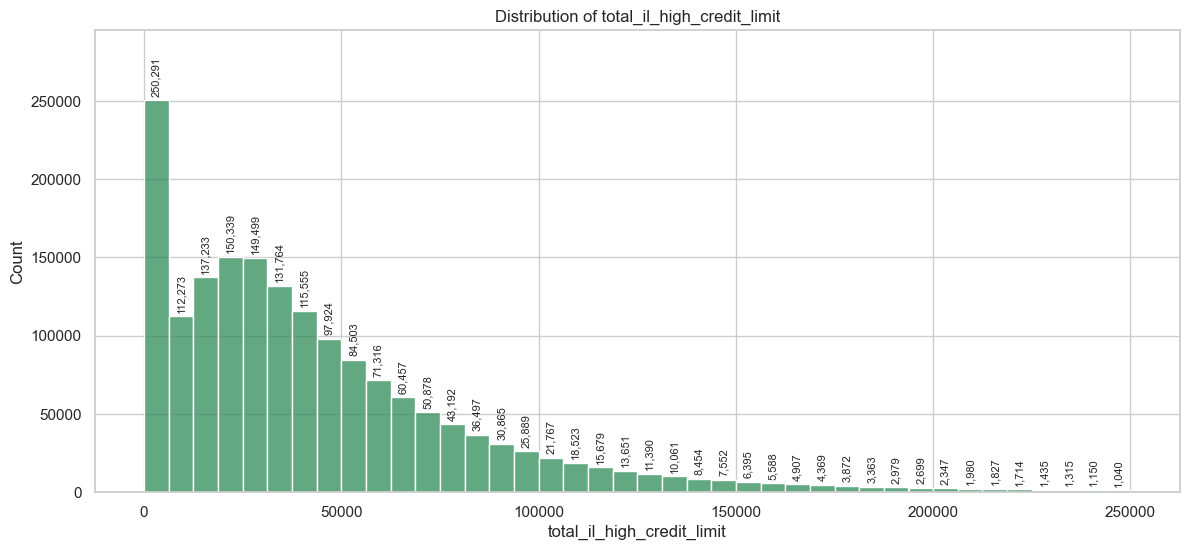

In [145]:
if 'total_il_high_credit_limit' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_il_high_credit_limit'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 250000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_il_high_credit_limit')
    plt.xlabel('total_il_high_credit_limit')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_il_high_credit_limit' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_pymnt

Payments received to date for total amount funded.
<br>
현재까지 수령한 총 납입액. IRR 계산의 현금 유입이지만 **예측 변수로는 사용 불가.**

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

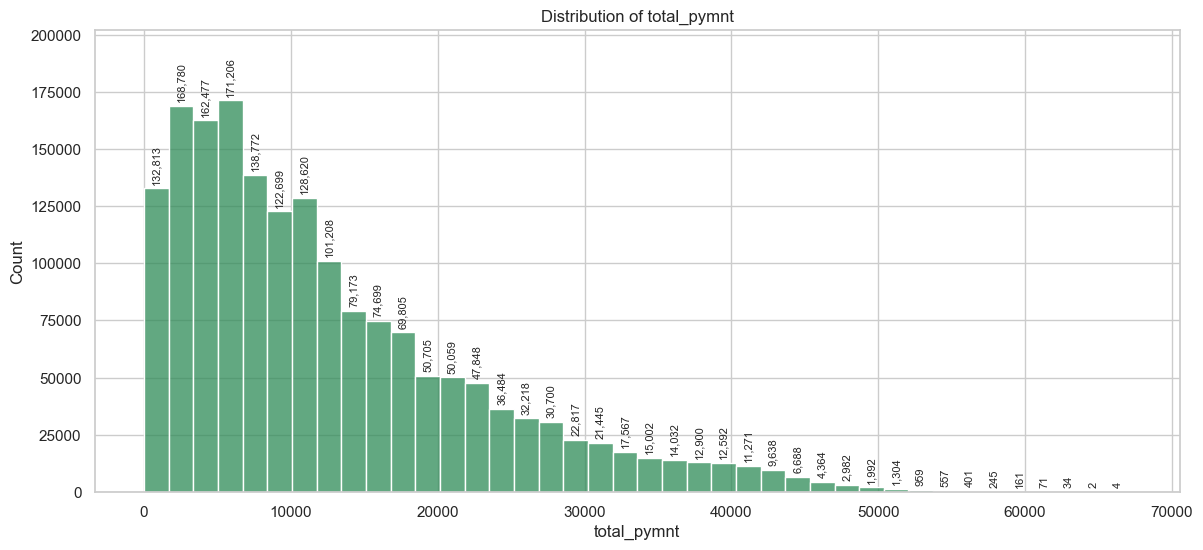

In [146]:
if 'total_pymnt' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_pymnt'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_pymnt')
    plt.xlabel('total_pymnt')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_pymnt' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_pymnt_inv

Payments received to date for portion of total amount funded by investors.
<br>
투자자 지분 기준 총 수령액. 실제 투자자 관점 IRR 계산에 사용.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

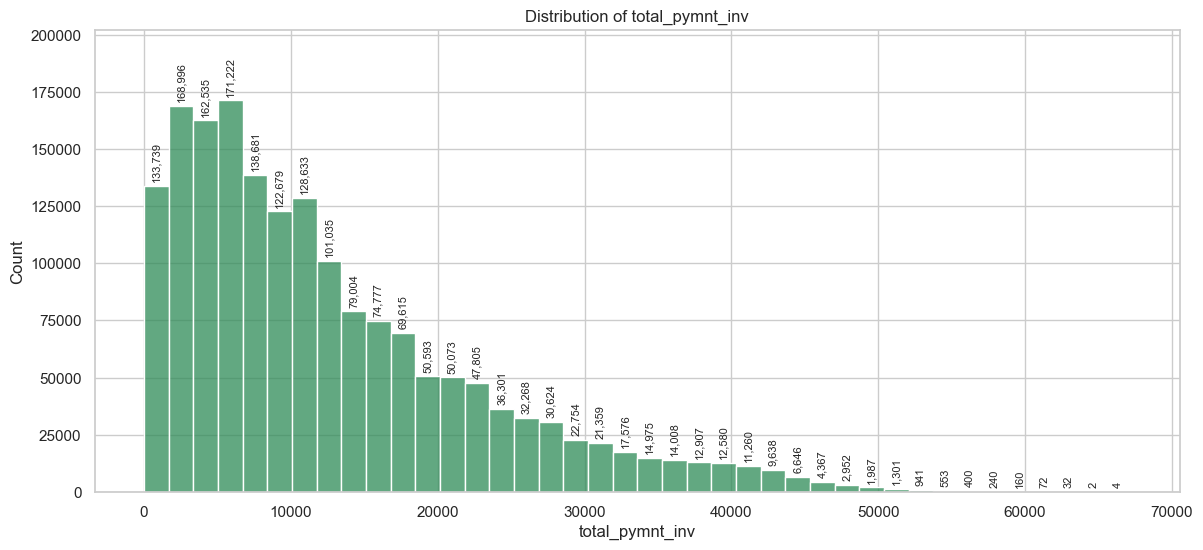

In [147]:
if 'total_pymnt_inv' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_pymnt_inv'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_pymnt_inv')
    plt.xlabel('total_pymnt_inv')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_pymnt_inv' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_rec_int

Interest received to date.
<br>
현재까지 수령한 이자 총액.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 15,000 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

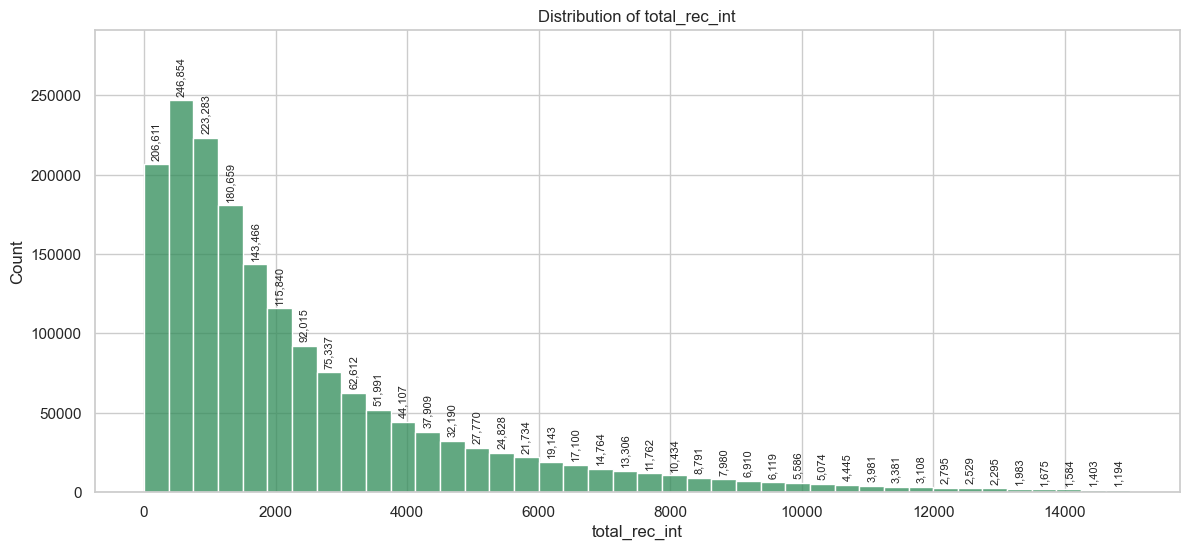

In [148]:
if 'total_rec_int' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_rec_int'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 15000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_rec_int')
    plt.xlabel('total_rec_int')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_rec_int' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_rec_late_fee

Late fees received to date.
<br>
현재까지 수령한 연체 수수료. 대부분 0.

<br>

% 이상치로 그래프가 찌그러지는 것을 막기 위해 200 이하 구간만 시각화
<br>
🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

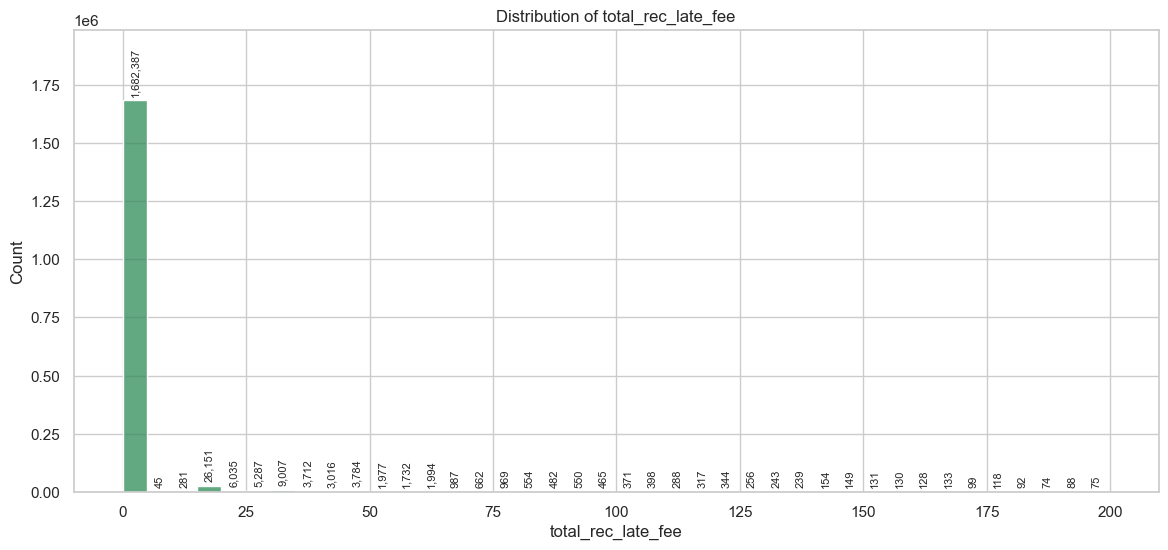

In [149]:
if 'total_rec_late_fee' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_rec_late_fee'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 200]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_rec_late_fee')
    plt.xlabel('total_rec_late_fee')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_rec_late_fee' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_rec_prncp

Principal received to date.
<br>
현재까지 수령한 원금. '지금까지 얼마나 갚았는가'에 해당하는 핵심 사후 변수.

<br>

🚫 **사용 금지 (사후정보 / look-ahead)** — 대출 실행 이후에 결정되는 값이라 예측에 쓰면 정보 누출(leakage). 단, IRR·수익률 계산에는 활용.

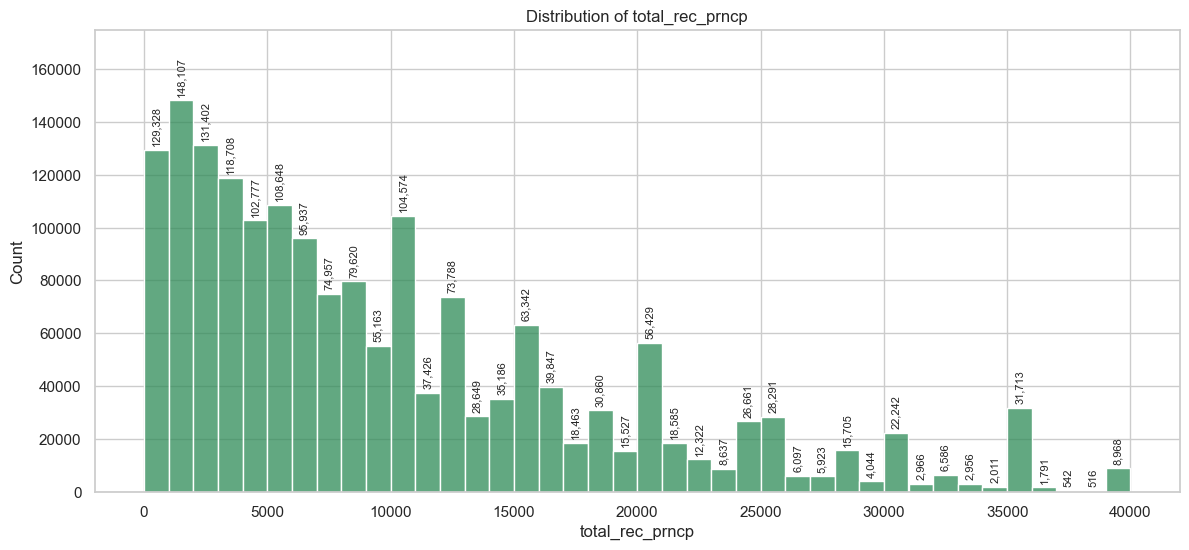

In [150]:
if 'total_rec_prncp' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_rec_prncp'].dropna()
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_rec_prncp')
    plt.xlabel('total_rec_prncp')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_rec_prncp' 컬럼이 데이터에 없습니다. 건너뜁니다.")

### total_rev_hi_lim

Total revolving high credit/credit limit.
<br>
전체 리볼빙 계좌의 총 한도.

<br>

% 결측치 **2.33%** — 그래프는 결측치 제거 후 작성
<br>
% 이상치로 그래프가 찌그러지는 것을 막기 위해 200,000 이하 구간만 시각화
<br>
✅ **모델 투입 가능** — 대출 승인 시점에 관측되는 신청자 정보.

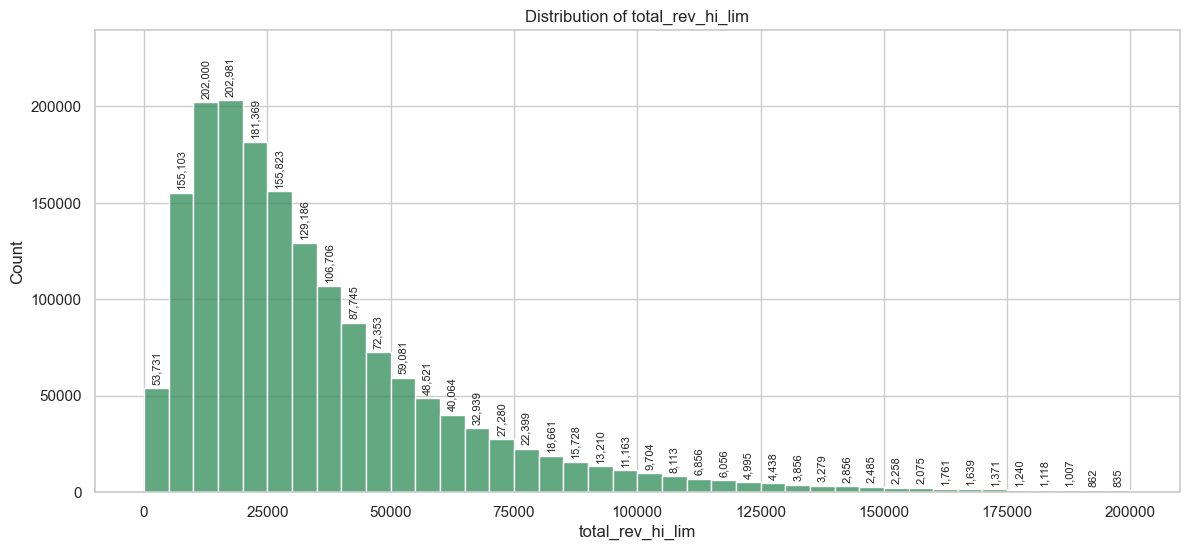

In [151]:
if 'total_rev_hi_lim' in lending_club.columns:
    plt.figure(figsize=(14, 6))

    data_to_plot = lending_club['total_rev_hi_lim'].dropna()
    data_to_plot = data_to_plot[data_to_plot <= 200000]
    ax = sns.histplot(x=data_to_plot, bins=40, color='seagreen')
    ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8, padding=3, rotation=90)

    plt.title('Distribution of total_rev_hi_lim')
    plt.xlabel('total_rev_hi_lim')
    plt.ylabel('Count')
    plt.margins(y=0.18)
    plt.show()
else:
    print("'total_rev_hi_lim' 컬럼이 데이터에 없습니다. 건너뜁니다.")

## 5. 변수 분류 요약

앞에서 변수별로 표기한 판정을 파이썬 리스트로 정리했습니다.

- `DROP_POST_TREATMENT` : 대출 실행 후에 결정되는 값. 예측에 쓰면 정보 누출이지만, **IRR 현금흐름 계산에는 반드시 필요**합니다.
- `DROP_ENDOGENOUS` : LC의 심사·가격 결정 결과물. 이자율·등급 계열이 여기 속합니다.
- `DROP_ID`, `DROP_CONSTANT` : 식별자와 상수.
- `USABLE` : 승인 시점에 관측 가능한 설명변수 후보.

In [152]:
# 대출 실행 이후 결정되는 사후정보 (leakage) — 수익률 계산에만 사용
DROP_POST_TREATMENT = [
    'loan_status',
    'collection_recovery_fee',
    'debt_settlement_flag',
    'deferral_term',
    'hardship_amount',
    'hardship_dpd',
    'hardship_end_date',
    'hardship_flag',
    'hardship_last_payment_amount',
    'hardship_length',
    'hardship_loan_status',
    'hardship_payoff_balance_amount',
    'hardship_reason',
    'hardship_start_date',
    'hardship_status',
    'hardship_type',
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',
    'last_pymnt_amnt',
    'last_pymnt_d',
    'next_pymnt_d',
    'orig_projected_additional_accrued_interest',
    'out_prncp',
    'out_prncp_inv',
    'payment_plan_start_date',
    'recoveries',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_int',
    'total_rec_late_fee',
    'total_rec_prncp',
]

# LC의 심사·가격 결정 결과물 (내생변수)
DROP_ENDOGENOUS = [
    'funded_amnt',
    'funded_amnt_inv',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'initial_list_status',
]

# 식별자
DROP_ID = [
    'id',
    'url',
]

# 상수 변수
DROP_CONSTANT = [
    'pymnt_plan',
    'policy_code',
]

# 승인 시점에 관측 가능한 설명변수 후보
USABLE = [
    'loan_amnt',
    'term',
    'emp_title',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'annual_inc_joint',
    'verification_status',
    'verification_status_joint',
    'issue_d',
    'desc',
    'purpose',
    'title',
    'zip_code',
    'addr_state',
    'dti',
    'dti_joint',
    'delinq_2yrs',
    'delinq_amnt',
    'acc_now_delinq',
    'acc_open_past_24mths',
    'earliest_cr_line',
    'fico_range_low',
    'fico_range_high',
    'inq_last_6mths',
    'inq_fi',
    'inq_last_12m',
    'all_util',
    'il_util',
    'bc_util',
    'bc_open_to_buy',
    'avg_cur_bal',
    'application_type',
    'chargeoff_within_12_mths',
    'collections_12_mths_ex_med',
    'max_bal_bc',
    'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'mort_acc',
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_last_record',
    'mths_since_rcnt_il',
    'mths_since_recent_bc',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_inq',
    'mths_since_recent_revol_delinq',
    'num_accts_ever_120_pd',
    'num_actv_bc_tl',
    'num_actv_rev_tl',
    'num_bc_sats',
    'num_bc_tl',
    'num_il_tl',
    'num_op_rev_tl',
    'num_rev_accts',
    'num_rev_tl_bal_gt_0',
    'num_sats',
    'num_tl_120dpd_2m',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m',
    'open_acc',
    'open_acc_6m',
    'open_act_il',
    'open_il_12m',
    'open_il_24m',
    'open_rv_12m',
    'open_rv_24m',
    'pct_tl_nvr_dlq',
    'percent_bc_gt_75',
    'pub_rec',
    'pub_rec_bankruptcies',
    'revol_bal',
    'revol_bal_joint',
    'revol_util',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_earliest_cr_line',
    'sec_app_fico_range_high',
    'sec_app_fico_range_low',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_num_rev_accts',
    'sec_app_open_acc',
    'sec_app_open_act_il',
    'sec_app_revol_util',
    'tax_liens',
    'tot_coll_amt',
    'tot_cur_bal',
    'tot_hi_cred_lim',
    'total_acc',
    'total_bal_ex_mort',
    'total_bal_il',
    'total_bc_limit',
    'total_cu_tl',
    'total_il_high_credit_limit',
    'total_rev_hi_lim',
]

In [153]:
DROP_ALL = DROP_POST_TREATMENT + DROP_ENDOGENOUS + DROP_ID + DROP_CONSTANT

print('전체 변수      :', lending_club.shape[1])
print('제외 대상      :', len(DROP_ALL))
print('설명변수 후보  :', len(USABLE))

# 실제 데이터에 존재하는 컬럼만 남겨서 확인
drop_in_df = [c for c in DROP_ALL if c in lending_club.columns]
use_in_df  = [c for c in USABLE   if c in lending_club.columns]
print()
print('데이터에 존재하는 제외 대상 :', len(drop_in_df))
print('데이터에 존재하는 사용 후보 :', len(use_in_df))

# 분류표에 없는 컬럼이 있는지 점검
unclassified = [c for c in lending_club.columns if c not in DROP_ALL + USABLE]
print('미분류 컬럼 :', unclassified)

전체 변수      : 141
제외 대상      : 43
설명변수 후보  : 99

데이터에 존재하는 제외 대상 : 43
데이터에 존재하는 사용 후보 : 98
미분류 컬럼 : []


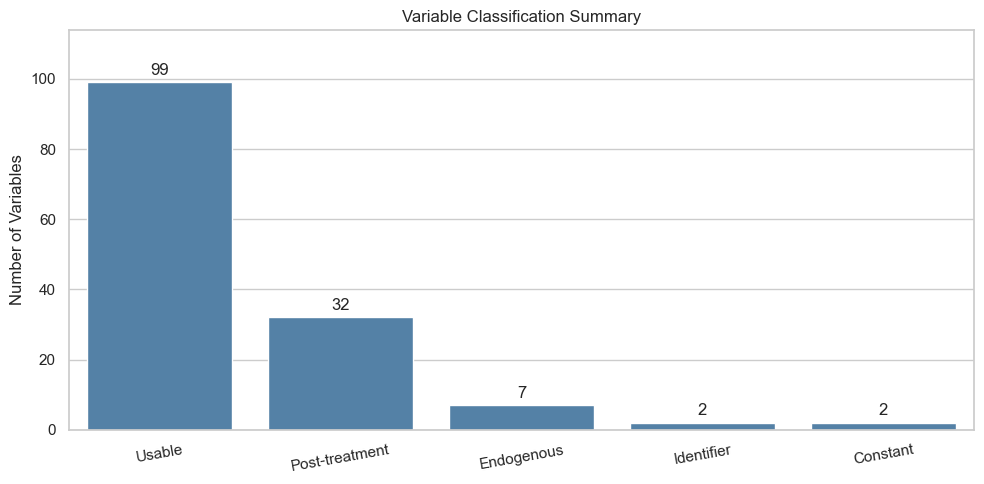

In [154]:
# 분류 결과 요약 시각화
# 그래프 라벨은 한글 폰트 설정 없이도 깨지지 않도록 영문으로 표기
summary = pd.Series({
    'Usable': len(USABLE),
    'Post-treatment': len(DROP_POST_TREATMENT),
    'Endogenous': len(DROP_ENDOGENOUS),
    'Identifier': len(DROP_ID),
    'Constant': len(DROP_CONSTANT),
})

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=summary.index, y=summary.values, color='steelblue')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)

plt.title('Variable Classification Summary')
plt.ylabel('Number of Variables')
plt.xlabel('')
plt.xticks(rotation=10)
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

## 다음 단계

1. **라벨 확정** — `loan_status`가 `Fully Paid` / `Charged Off` 인 종결 건만 남깁니다. `Current`, `In Grace Period`, `Late` 는 아직 결과가 확정되지 않았으므로 제외합니다.
2. **만기 고려** — 36개월 만기 대출은 실행 후 3년, 60개월은 5년이 지나야 결과가 확정됩니다. `issue_d` 기준으로 관측 기간이 충분한 건만 사용합니다.
3. **IRR 계산** — `loan_amnt`(유출)와 `total_pymnt`, `recoveries`(유입)로 건별 실현 수익률을 구합니다.
4. **분할** — train : valid : test = 6 : 2 : 2 로 나누고, 이 과정을 100회 반복합니다.
5. **임계값 탐색** — validation에서 부도 확률 임계값을 조정하며 포트폴리오 샤프 비율을 최대화합니다.
6. **평가** — test(out-of-sample) 샤프 비율 100개를 히스토그램으로 정리합니다.